<a href="https://colab.research.google.com/github/Mohamed7AbdELhalim/structured_ocr-ar/blob/main/mistral/ocr/structured_ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OCR Exploration and Simple Structured Outputs (Deprecated)

---

In this cookbook, we will explore the basics of OCR and leverage it together with existing models to achieve structured outputs fueled by our OCR model (we recommend using the new Annotations feature instead for better results).

You may want to do this in case current vision models are not powerful enough, hence enhancing their vision OCR capabilities with the OCR model to achieve better structured data extraction.

---

### Model Used
- Mistral OCR
- Pixtral 12B & Ministral 8B

---

**For a more up to date guide on structured outputs visit our [Annotations cookbook](https://github.com/mistralai/cookbook/blob/main/mistral/ocr/data_extraction.ipynb) on Data Extraction.**


## Setup

First, let's install `mistralai` and download the required files.

In [74]:
%%capture
!pip install mistralai

### Download PDF and image files

In [75]:
%%capture
!wget https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/mistral7b.pdf
!wget https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/receipt.png

## Mistral OCR with PDF

We will need to set up our client. You can create an API key on our [Plateforme](https://console.mistral.ai/api-keys/).

In [76]:
# Initialize Mistral client with API key
from mistralai import Mistral

api_key = "97ZQlsV45YrDusgZRwjArWGbh3nerFPb" # Replace with your API key
client = Mistral(api_key=api_key)

There are two types of files you can apply OCR to:
- 1. PDF files
- 2. Image files

Let's start with a PDF file:

{
    "pages": [
        {
            "index": 0,
            "markdown": "# \u0627\u0644\u0645\u0628\u062d\u062b \u0627\u0644\u0623\u0648\u0644 \n\n## \u0641\u064a \u0627\u0644\u0637\u0631\u064a\u0642 \u0625\u0644\u0649 \u0627\u0644\u062d\u0631\u0628 \u0627\u0644\u0639\u0627\u0644\u0645\u064a\u0629 \u0627\u0644\u0623\u0648\u0644\u0649:\n\n## \u0646\u062d\u0648 \u0646\u0638\u0627\u0645 \u062f\u0648\u0644\u064a \u0623\u0648\u0631\u0648\u0628\u064a \u062d\u062f\u064a\u062b \u0628\u0644\u0627 \u0645\u0646\u0627\u0632\u0639\n\n## (1) \u0628\u062f\u0627\u064a\u0627\u062a \u0627\u0644\u0642\u0631\u0646 \u0627\u0644\u0639\u0634\u0631\u064a\u0646: \u0645\u0644\u0627\u0645\u062d \u0645\u0646 \u0627\u0644\u0627\u0633\u062a\u0645\u0631\u0627\u0631\u064a\u0629\n\n\u0648\u0631\u062b \u0627\u0644\u0642\u0631\u0646 \u0627\u0644\u0639\u0634\u0631\u0648\u0646 \u0627\u0644\u0643\u062b\u064a\u0631 \u0645\u0646 \u0645\u0644\u0627\u0645\u062d \u0627\u0644\u0627\u0633\u062a\u0645\u0631\u0627\u0631\u064a\u0
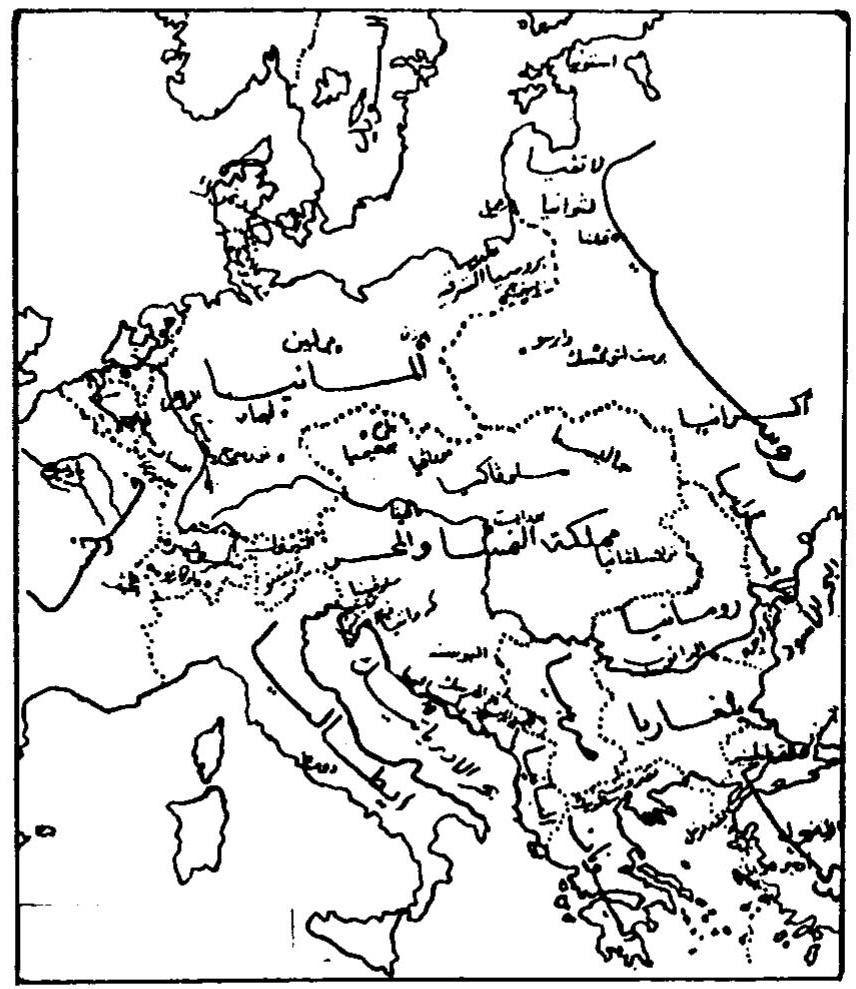
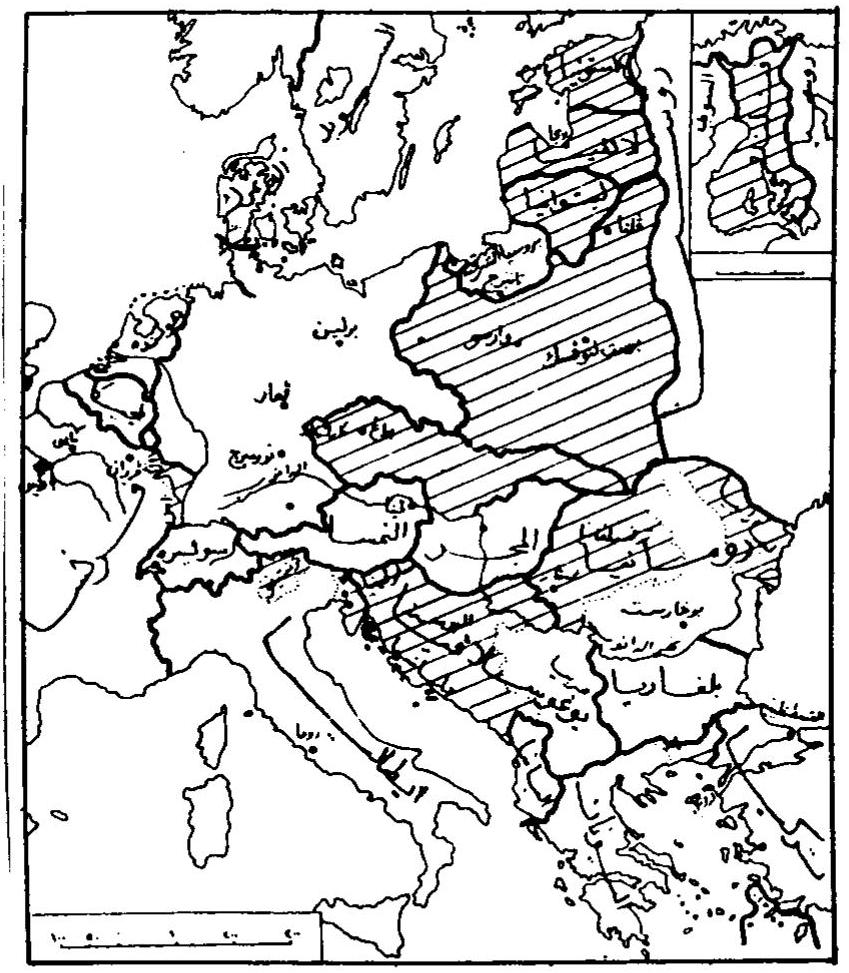

In [85]:
# Import required libraries
from pathlib import Path
from mistralai import DocumentURLChunk, ImageURLChunk, TextChunk
import json

# Verify PDF file exists
pdf_file = Path("8.pdf")
assert pdf_file.is_file()

# Upload PDF file to Mistral's OCR service
uploaded_file = client.files.upload(
    file={
        "file_name": pdf_file.stem,
        "content": pdf_file.read_bytes(),
    },
    purpose="ocr",
)

# Get URL for the uploaded file
signed_url = client.files.get_signed_url(file_id=uploaded_file.id, expiry=1)

# Process PDF with OCR, including embedded images
pdf_response = client.ocr.process(
    document=DocumentURLChunk(document_url=signed_url.url),
    model="mistral-ocr-latest",
    include_image_base64=True
)

# Convert response to JSON format
response_dict = json.loads(pdf_response.model_dump_json())

print(json.dumps(response_dict, indent=4)) # Print the full JSON output

View the result with the following:

# المبحث الأول 

## في الطريق إلى الحرب العالمية الأولى:

## نحو نظام دولي أوروبي حديث بلا منازع

## (1) بدايات القرن العشرين: ملامح من الاستمرارية

ورث القرن العشرون الكثير من ملامح الاستمرارية من فترات سبقته. فمن ناحية أولى، بدأ القرن العشرون وقد خضعت معظم دول العالم في آسيا وأفريقيا والأمريكتين للسيطرة الأوروبية. كانت الحركة الاستعمارية الأوروبية التي بدأت مع القرنين الخامس عشر والسادس عشر قد نجحت في الوصول إلى مشارق الأرض ومغاربها وبسطت سيطرتها على الموارد والعمالة والأراضي والأسواق بما تُتيحه من مصارف للاستثمارات والبضائع في شتّى البقاع التي وصلَ إليها الاستعمار(1). وسيكون التحرُّر من الاستعمار ملمحًا مهمًّا من ملامح تطور السياسة الدولية في القرن العشرين. ومن ناحية أخرى، ورث النظام الدولي في بدايات القرن العشرين أفكارًا وأيديولوجيات ازدهرتْ على أراضٍ أوروبية منذ القرن الثامن عشر. فلقد أزاحت كلٌّ من الليبرالية والاشتراكية والقومية والعنصرية العلمية Scientific racism أفكارًا سادت قبلهم. وقادت هذه الأفكار والأيديولوجيات الأربع إلى تغيُّرات مُهمَّة في ملامح النظام الدولي الأوروبي فيما قبل وعلى مدار القرن العشرين. فمن جانبها، دعت الليبرالية إلى إعلاء قيمة حقوق الفرد على حساب حقوق المجتمع وإلى إعلاء قيمة الاستحقاق، وتعاملت مع العالَم بوصفه وحدة اقتصادية واحدة تتحقَّق فيها المنفعة بالتعاون وتحرير التجارة. ومن ثم قدَّمت الليبرالية بديلًا

[^0]
[^0]:    (1) William R. Keylor, Twentieth Century World: An International History, (New York: Oxford University Press, 4th edition, 2001), p. 3.

للمركنثيلية الاقتصادية(1)؛ التي تؤمن بأهمية تحكُّم الدولة في الاقتصاد من أجل تعظيم منفعة الدولة حتى ولو على حساب غيرها من الدول، والتي دعمت التنافس الاستعماري وبِرْرت مبدأ إخضاع اقتصاد المستعمرات بالكلية واستغلال مواردها وثرواتها من ناحية، وأسواقها من ناحية أخرى(1). ستفتح الليبرالية طريقًا أمام الدول المستعمِرة للتفكير في نظامٍ تتحقّق لها فيه مصالحها حتى وإن تخلّت عن مستعمراتها. لهذا سنرى في النصف الثاني من القرن العشرين نظامًا دوليًّا يكاد يخلو من ظاهرة الاستعمار المادِّي، ولكنه لا زال -بمؤسّساته وقوانينه وأعرافه- متَّهمًا بأنه مكرّس لخدمة الدول الرأسمالية الأكبر في النظام، كما سيرد التفصيل.

في المقابل دعت الاشتراكية إلى تحكُّم الدولة في الاقتصاد بدلًا عن الحرية الكاملة للأسواق، ودعت إلى إعلاء قيمة المساواة في مقابل قيمة الاستحقاق، ودعت إلى إعلاء حقوق المجتمع بالمقارنة بحقوق الفرد. سيميّز التنافسُ بين الليبرالية والاشتراكية معظم سنوات القرن العشرين.

أما الفكر القوميُّ فقد كانت الثورة الفرنسية صاحبةَ الفضل الأول في ظهوره. قاد ظهور القومية تدريجيًّا إلى التحوُّل في علاقة الحكَّام بالمحكومين من منطق الرعية إلى منطق المواطنة، ومن سيادة الحاكم Dynastic sovereignty إلى سيادة الشعب Popular sovereignty. غيَّرت القومية -مصحوبةً بالثورة الصناعية- من شكل الحروب، أضْحت الحروبُ واسعةُ النطاق ممكنةً في ظل القدرة على تعبئة جيوش ضخمة الأعداد(٢). كانت للقومية آثارٌ متناقضة؛ ففي وقتٍ قادت فيه القومية إلى توحيد شعوب مثل الألمان والطليان بدعوى أنها شعوب صاحبةُ أصول مشتركة على نحوٍ أوجدَ
(1) Amitav Acharya and Barry Buzan, The Making of Global International Relations: Origins and Evolution of IR at its Centenary, (Cambridge: Cambridge University Press, 2019), p. 9.
(2) Definition of Mercantilism, Encyclopaedia Britannica, available at: britannica.com/topic/mercantilism
(3) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, (London and New York: Routledge, 2008), p. 102.

على الساحة الدولية قوى كبرى كاّمانيا وإيطاليا، قادت القومية إلى كثير من المشكلات؛ فقد كانت على سبيل المثال سببًا في تفكيك العديد من الإمبراطوريات ذات القوميات المتعدّدة، وطرحت إشكالياتٍ كبيرة كما في حالة الولايات المتحدة الأمريكية التي وجدت صعوبة في تمييز هويتها القومية عن بريطانيا بشكل أساسي، ولا تزال إشكالية الهوية القومية وتعريف "الأمريكي" إشكالية حاضرة في السياسة الأمريكية(1).

وكان للـ "عنصرية العلمية Scientific racism" تأثير كبير على التفاعلات الدولية من منتصف القرن التاسع عشر حتى منتصف القرن العشرين، على أقل تقدير. يطلِق البعض على النظريات التي تعرف بالعنصرية العلمية وصف النظريات العلمية المزيفة Pseudoscience حيث روّجت للعنصرية بالاستعانة بنظريات مُحمّلة بالمغالطات العلمية(1). وكان للداروِية الاجتماعية -على سبيل المثال- دورٌ كبير في الترويج لمنطق "البقاء للأصلح"، والذي كان مبرّرًا للرأسمالية غير المُقيّدة، وكذلك للجروب بوصفها عاملَ حسمٍ أساسيًّا لصراع القوة؛ ومن ثم وسيلة لضمان بقاء الأصلح والأقوى( ${ }^{(1)}$. وقد وفّرت العنصرية العلمية غطاءً مهمًّا للإمبريالية كرّس ذلك التمييز بين شعوبٍ متحضِرةٍ تَستعمِر وأخرى همجية ومتخلِّفة تستحق الاستعمار. كما نجحت العنصرية العلمية في خلق هيراركية داخل أوروبا ذاتها ما بين الشعوب الأُربة واللاتينية السلافية. وأفرز التفاعل بين القومية والعنصرية العلمية بعضًا من أكثر النظم السياسية التي عرفتها البِشرية وحشية؛ ألا وهي النظم الفاشية؛ "وهي نظم استبدادية تتمحور حول قائد قومي يدعمه حزبٌ حاكم يلجأ إلى العنف لإجبار الشعب على طاعته" (2).
(1) Amitav Acharya and Barry Buzan, The Making of Global International Relations, Op. cit., p. 10-11. وانظر: صمويل هنتنجتون، من نحن؟ المناظرة الكبرى في الولايات المتحدة، ترجمة: أحمد مختار الجمال، (القاهرة: المركز القومي للترجمة، ٢٠٠٩).
(2) Walton Brown-Foster, Race in the Study of International Relations and World Politics: Implications for Research in the 21st Century, PhD, Central Connecticut State University, Connecticut, p. 5.
(3) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., p. 102
(4) Ibid., p. 123.

كانت هذه الأيديولوجيات والأفكار بمثابة مفسّرات كبرى للحربين العالمية الأولى والثانية، ولا زالت هذه الأيديولوجيات مؤثّرة في واقعنا الدولي المعاصر ولو بدرجات متفاوتة. لم يختفِ تأثير العنصرية العلمية والاشتراكية حتى وإن بدا ظاهريًّا أن تأثيرهما قد تراجع، وكذلك لا زالت لكلٍ من الليبرالية والقومية أدوارٌ مؤثرةٌ ممتدّةٌ كما سنرى عبر جزئيّات هذا الفصل(1).

لم تكن هذه الأفكار والأيديولوجيات منتَجًا أوروبيًّا بالمعنى الجغرافي فحسب، وإنما جمعها -رغم تنوعها- كونُها منتجًا أوروبيًّا بالمعنى المعرفي بالأساس، فقد كانت منتجًا

للروْبة المعرفية الوضعية المادية التي تبنَّنها أوروبا الحديثة منذ عصر النهضة والتنوير. وهي رؤية تتميَّز بإعلاء قيمة الإنسان الفرد وقيمة العقل البشري بوصفه مصدرًا للقيم والأخلاق والمعرفة وبديلًا عن الإله والعقيدة، وحيث الاعتقاد في التقدُّم المضطرد للبشرية بفضل العلم الذي يسمح للإنسان بأن يُخضع الطبيعة مِن حولِه لسلطته(٢). كان التطور التكنولوجي والعلمي ضمن أسباب أخرى عديدة محفِزًا للبشر على الاعتقاد المتزايد في قدرتهم على السيطرة على هذا الكون والتحكُّم في الطبيعة، وعلى تبلور تلك الرؤية الوضعية للعالم(٣).
(1) Amitav Acharya and Barry Buzan, The Making of Global International Relations, Op. cit., p. 11-12.
(2) Roger B. Beck et al. (senior eds.), World History: Patterns of Interaction, (Evanston: McDougall Littell, 2009), p. 634.
(3) David Campbell, Poststructuralism, in: Tim Dunne, Milia Kurki and Steve Smith (eds.), International Relations Theory: Discipline and Diversity, (Oxford: Oxford University Press, 3rd edition, 2013), p. 227.

من ناحية ثالثة، بدأ القرن العشرون وقد تنامى
الاتصال والتفاعل المتبادل بين جميع بقاع الأرض(1)، وعلى نحو اتَّسم بسَمتين أساسيْتين: أولاهما- أن هذا الاتصال والتفاعل المتبادل بات متمحورًا حول أوروبا ومكرَّسًا لخدمتها؛ وهو ما يُسمِّيه البعض بأوربة
العالم The Europeanization of the world؛
حيث كانت أوروبا قد أضحت هي مركز النظام الدولي مع بدايات القرن العشرين بالفعل. ثانيتهما- أن هذا الاتصال والتفاعل المتبادل كان يحدث على مستوى "عالمي Global"، على اعتبار أن "العالم" لم يكن متَّصِلًا ببعضه البعض قبل اكتشاف قارات العالم الجديد مع الحركة الاستعمارية الأوروبية، وأن أيًّا من النظم الدولية السابقة في الوجود على النظام الأوروبي لم يكن يتَّسع ليَشْمل العالمَ كلَّه. ومن ثم كان هذا الاتصال العالمي هو البداية الحقيقية لفكرة "انكماش الأرض The shrinkage of earth" التي ستتطور تدريجيًّا لتأخذ شكل العولمة مع نهايات القرن العشرين(7).

كان هذا الانكماش منتِجًا لعدَّة تطورات تكنولوجية؛ أولها- هو تحوُّل السفن التجارية والحربية للعمل بالبخار بديلًا عن السفن الشراعية، وذلك منذ النصف الثاني من القرن التاسع عشر بشكل أساسي. أما التطور التكنولوجي الثاني فتمثِّل في تطور وسائل النقل البري التي تعمل بالبخار على نحو سمح للقوى الكبرى بالوصول إلى مناطق داخل القارات لم تكن تصل إليها من قبل؛ وهو ما تولَّد عنه نقلة نوعية في القدرة على نقل الأفراد والبضائع والموارد والجنود والعتاد. صاحبَ ذلك كلُه تطورٌ آخر تمثِّل في شبكة عالمية للتلغراف تَغطِّي العالمَ كلُّه(9). وبِحلول عام ١٩١٤ كان العالم مُتَّصِلًا على نحو غير مسبوق(1). كان العالم يشهد تطورًا تكنولوجيًا في مجال السلاح جلب معه
(1) William R. Keylor, Twentieth Century World: An International History, Op. cit., pp. 5-15.
(2) Ibid., pp. 5-15.
(3) Ibid., pp. 29-30.
(4) Amitav Acharya and Barry Buzan, The Making of Global International Relations, Op. cit., p. 12.

سباقات تسلُح مهّدت للحرب العالمية الأولى؛ حيث قادَ الدولَ إلى أن تتسابق فيما بينها سباقًا كمِّيًّا ونوعيًّا حول أيِّها يمتلك أسلحة أكثر عددًا أو أشد فتكًا وأبعد مدى. أسْفر هذا الاتصال غير المسبوق عن ظهور حقل الجغرافيا السياسية المعنيّ بالعلاقة بين الجغرافيا وبين السياسة الدولية وما تُتيحه المقومات الجغرافية من فرصٍ أمام القوى الكبرى لبِسْط سيطرتها على مناطق أخرى من العالم. برزثَ في هذا السياق نظرية ماكندر الشهيرة المعروفة بقلب الأرض؛ وهي النظرية القائلة بأن "من يحكم شرق أوروبا يحكم قلب الأرض، وأن من يحكم قلب الأرض يحكم جزيرة العالم، وأن من يحكم جزيرة العالم يحكم العالم". هكذا بات هناك إدراك متزايد بأن العالم هو وحدة متّصلة ببعضها البعض. وهي النظرية التي حرّكت المخاوف البريطانية والأمريكية من السيطرة الألمانية أو الروسية على شرق أوروبا على مدار عقود من الزمان تََلَتْ(1). بالمثل كان لكتابات Alfred Thayer Mahan في عام ١٨٩٠ عن التطور التكنولوجي الذي سيلحق بالقوة البحرية وأثره على قدرة الدول على بسط سيطرتها على العالم والتنافس على السيطرة، كان لهذه الكتابات الفضل في تحريك رغبة الولايات المتحدة في الصعود بوصفها قوة عظمى؛ حماية لمصالحها في المستقبل؛ وهو ما دفعها إلى أن تفكّر في سلاحها البحري باعتباره أداة لبسط السيطرة والنفوذ على العالم(1). هنا تتّضح العلاقة التفاعلية بين الواقع والنظرية، فدائمًا ما يجلب تغير الواقع تطورًا أو تحولًا في النظرية والفكر، ودائمًا ما يجلب تحول الفكر والنظرية تغييرًا في الواقع. وهي علاقة تميِّز حقل العلاقات الدولية عبر مراحل تطؤُره المختلفة كما سنلاحظ.

أسْفر هذا الاتصال غير المسبوق عن النشأة التدريجية لأسواق عالمية للمال والتجارة، لم يعرف العالم مثلَها من قبل لا في حجم حركة تنقُلات الأفراد ولا حجم ونوعية حركة تنقُلات البضاعة. وفي الفترة من ١٨٥٠ حتى ١٩١٣ تضاعفت التجارة الدولية بمقدار عشرة أضعاف. كانت أعداد الشركات عابرة القوميات
(1) William R. Keylor, Twentieth Century World: An International History, Op. cit., pp. 29-30.
(2) Ibid., pp. 30-35.

Transnational corporations (TNCs) آخذةً في التزايد منذ صدور قانون الشركات البريطانية في عام 1٨٦٢ والذي سمح للشركات بالعمل عبر حدود الدول، ستُعرف هذه الشركات -متى تعدُدت جنسيات المساهمين فيها- بالشركات متعبّدة الجنسيات Multinational corporations (MNCs) وستصبح فاعلًا دوليًّا مهمًّا، خاصة منذ سبعينيات القرن العشرين. شركات كمايكروسوفت وجنرال إلكتريك وغيرها هي شركات متعبّدة الجنسيات. وبِحلول عام 1917 كانت هناك 20 منظمة دولية حكومية Intergovernmental Organizations (IGOs) في مجالات مختلفة. شاركت بعض الدول المستعمَرة في عددٍ من هذه المنظمات. لم تكن السيادة شرطًا من شروط المشاركة في المنظمات الدولية، ولكنّ وجود إدارة فعالة -حتى لو مُحْتَلَّة- كان كافيًا للسماح لهذه الدول بالانضمام إلى عضوية هذه المنظمات، وبُعَذُ هذا اختلافًا جوهريًّا عن عالم ما بعد الحرب العالمية الأولى؛ حيث أصبحت السيادة شرطًا أساسيًّا لعضوية المنظمات الدولية. كان من بين المنظمات الدولية التي عرفها العالم قبيل الحرب العالمية الأولى -على سبيل المثال- اتحاد البريد العالمي والمحكمة الدائمة للتحكيم التي تأسَّست في عام 1999 بوصفها أول آلية دولية لتسوية المنازعات الدولية(1). وتوجد في العالم اليوم قرابة ٢٠٠ منظمة دولية أكبرها من حيث عدد الدول الأعضاء هي الأمم المتحدة والتي تمَّ توقيع ميثاق تأسيسها عام 1920 في أعقاب الحرب العالمية الثانية(٢).
(1) الموقع الرسمي للمحكمة الدائمة للتحكيم: https://pca-cpa.org/ar/about/introduction/history
(2) Definition of International Organization, National Geographic| resource library, available at: https://bit.ly/3BrAmMz

لم يكن العالم مع بداية القرن العشرين يعرف المنظمات الحكومية وحدها. كانت هناك أيضا أعدادٌ من المنظمات الدولية غير الحكومية International non-governmental organizations (INGOs)، كان من بينها -على سبيل المثال- منظمات مناهضة للحروب ومنظمات داعمة للثورات ومنظمات مناهضة للعبودية... إلخ. تختلف المنظمات الدولية غير الحكومية عن المنظمات الدولية الحكومية؛ من حيث طبيعة عضوبتها؛ حيث تقتصر عضوية المنظمات الدولية الحكومية على الحكومات الوطنية، بينما تُعتبر الأولى منظماتٍ خاصةً يتنوَّع أعضاؤها حسب طبيعة نشاطها وتتنوّع نشاطاتها ما بين الأهداف السياسية والإنسانية والعلمية... إلخ(1). وكان عدد هذه المنظمات قد بلغ في فترة ما قبل الحرب العالمية الأولى قرابة الأربعمائة، وظلّ الكثير منها مؤثّرًا إلى يومنا هذا كما هو الحال مع الصليب الأحمر على سبيل المثال. وقد شهدت

أعداد المنظمات الدولية غير الحكومية طفرة منذ الستينيات(1).

كانت هذه المنظمات هي جذور ما سيُعرف في القرن العشرين بالمجتمع المدني العالمي؛ وقوامه مجموعة المنظمات غير الحكومية؛ كمنظمة العفو الدولية، ومنظمة العمل الدولية، ومنظمة السلام الأخضر، والمنتدى الاجتماعي العالمي، بالإضافة إلى الحركات الاجتماعية وشبكات النشطاء والمدنيّين عبر القومية. يجمع معظم هذه المنظمات والحركات محاولةً مقاومة نفوذ الدول ونفوذ الشركات الكبرى، وكثيرٌ منها يُعتبر مناهِضًا للعوِمة وللأثار السلبية للنظام الرأسمالي كالآثار الاجتماعية والبيئية وغيرها، وكثيرٌ منها يوازن القصور أو التحيُز لصالح مصالح القوى الكبرى الذي يميِّز مؤسسات النظام الدولي القائمة على عضوية الدول، والتي تُعْرَف أيضًا بمؤسسات الجوكمة العالمية. تشترك كثيرٌ من هذه الكيانات في الالتفات إلى مصالح المهمَّشين وحق الفقراء في الحرية
(1) Joshua S. Goldstein, International Relations, (New York: HarperCollins, 2nd edition, 1996), p. 15.
(2) Edward A. L. Turner, Why Has the Number of International NonGovernmental Organizations Exploded since 1960?, Cliodynamics, Vol. 1, 2010, pp. 81-91.

والتمكين، واحترام التعدُدية الثقافية والحضارية، والاستدامة البيئية (الحفاظ على حق الأجيال القادمة في الماء والهواء والتربة والغابات)... إلخ(1). بين هذه النواحي تدور قصة القرن العشرين، فما بين علاقات الأقوى بالأضعف والأغنى بالأفقر، وما بين تفاعل الأفكار والأيديولوجيات، وما بين تنامي الاتصال الدولي والتطوُّر التكنولوجي، ترتسم معالم هذا القرن.

# (Y) سيادة النظام الدولي الأوروبي: 

ألِفت أدبياتُ العلاقات الدولية الحديثَ عن عام ١٩١٤ بوصفه نقطة البداية للقرن العشرين؛ ذلك العام الذي انتهى فيه ما يُعرف بـ"السلام الأوروبي الطويل" حين اندلعت الحرب الكبرى(1) -التي عُرفت فيما بعد بالحرب العالمية الأولى- لتشهد أوروبا مرة أخرى حربًا ضارية بين قواها الكبرى، وعلى نحوٍ أعادَ للأذهان الأوروبية ذكرى الحروب النابوليونية التي انتهت قبلها بأكثر من مائة عام بهزيمة نابليون بونابرت وبعقد مؤتمر فيينا عام 1٨1٥ (راجع الفصل الثالث). كان الألمان هم أول من استخدم تعبير الحرب العالمية Weltkrieg في ١٩١٤ لوصف هذا الحدثِ الجَلَل. كانوا يرمزون بذلك إلى تكالُب العالم ضدَّهم ممثَّلًا في الإمبراطوريتين العظميين بريطانيا وفرنسا، أما

La grande guerre / The great بريطانيا وفرنسا فكانتا تصفان الحرب بالحرب الكبرى war ثم في مراحل لاحقة بالحرب العالمية( ${ }^{(P)}$.

لم تكن الحرب العالمية الأولى في واقع الأمر هي أُولى حروب القرن بين القوى الكبرى. كانت الحرب الروسية-اليابانية (٤-١٩٠٥) هي أولى هذه الحروب. وكان فوز اليابان
(1) See:

- Amitav Acharya and Barry Buzan, The Making of Global International Relations, Op. cit., pp. 12-15.
- Mark Bevir, governance, Encyclopedia Britannica, 22 December 2021, available at: https://www.britannica.com/topic/governance
- Andrew Heywood, Global Politics, (New York: Palgrave Macmillan, 2011), p. 358.
(2) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., p. 100.
(3) Ibid., p. 100.

في هذه الحرب محفِزًا لشعوب العالم غير الغربي غير الأبيض للسعي للتخلُّص من السيطرة الأوروبية. رأى البعض أن التجربة اليابانية (على عكس التجربة الصينية المتزامنة) حملت درسًا لشعوب أنهكتها عقودٌ من الاستعمار بأن التغلُّب على الاستعمار والوصول إلى مصافِ القوى الكبرى يحتاج إلى محاكاة النموذج الأوروبي ذاته، من هنا فسَّر البعض اندلاع العديد من الثورات القومية في روسيا (١٩٠٥) وتركيا (١٩٠٨) والصين (١٩١١)، كما كان الانتصار الياباني في الحرب الروسية-اليابانية عام ١٩٠٥ سببًا في سخط الروس على حكومتهم على نحوٍ قاد إلى الإطاحة بالنظام الإمبراطوري وتحوُّل روسيا إلى الشيوعية(1). إذن.. كان العالم يتشكَّل بفضْل أحداثٍ لا تقع بالضرورة على أراضٍ أوروبية، ولا تحركها فواعل أوروبية فحسَب، حتى وإن لم تَحْظَ بالاهتمام ذاته الذي حظِيتَ به أحداثٌ كانت أطرافها الفاعلة الأساسية أطرافًا أوروبية. كما لم تكن الحرب العالمية الأولى هي أطول الحروب عمرًا، فقد شهدت أوروبا حروبًا طاحنة تجاوزت أعداد سنواتها سنوات الحرب العالمية الأولى بكثير. شهدت حرب الثلاثين عاما ١٦١٨-١٦٤٨، وحرب السنوات السبع ١٧٥٦-١٧٦٣ بين القوى الأوروبية الكبرى آنذاك: فرنسا والنمسا وروسيا من جانب وبريطانيا وبروسيا وهانوفر من جانب، كما شهدت الحروب النابوليونية التي كانت امتدادًا لحروب الثورة الفرنسية واستغرقت قرابة ثلاثة وعشرين عامًا. لم تكن الحرب العالمية الأولى أكثر من حرب طويلة نسبيًّا، كانت أشبه بحرب استنزاف منها بحرب محدودة تنتهي بسيطرة طرف على قطعة أرض متنازع عليها. ولم تكن الحرب العالمية الأولى هي الوحيدة التي طالتْ أماكن متفرِّقة من العالم خارج أوروبا. طالتْ حرب السنوات السبع بين فرنسا وإنجلترا: أمريكا الشماليةَ والهند والفلبين والكاريبي وغيرها، كما طالت الحروب النابوليونية مناطق أخرى في العالم كأمريكا الشمالية ومصر وسوريا. أما في الحرب العالمية الأولى فكانت الإمبراطورِيتان

البريطانية والفرنسية تسيطران على معظم أفريقيا ومعظم آسيا وأستراليا، بينما كانت الإمبراطورية الروسية تسيطر على مساحات شاسعة من سيبيريا إلى القوقاز. شاركت اليابان في الحرب وسيطرت على المستعمرات الألمانية في الصين، كما شاركت الإمبراطورية العثمانية في الحرب بممتلكاتها من العراق إلى فلسطين. حتى الولايات المتحدة والبرازيل شاركتا في الحرب لاحقًا، بينما كانت كندا بالفعل تشارك فيها بوصفها جزءًا من الإمبراطورية البريطانية(1). ولم تكن الحرب العالمية الأولى هي الأكثر ضحايا. كانت الحرب العالمية الأولى حدثًا وحشيًّا بكل المقاييس الإنسانية، كانت الحرب الشاملة الصناعية الأولى industrialized total war. يرمز مفهوم الحرب الشاملة إلى حرب لا تميِّز بين المدنيين والمحاربين فتعتبر الفئتين أهدافًا مقبولة لها، وتكون فيها كل موارد المجتمع مسخَّرة لخدمة آلة الحرب غالبًا، ويكون هدفها هو بسَط السيطرة الكاملة على أرض العدو. اتُسمت الحرب العالمية الأولى بهذه الصفات، وزاد عليها أن القدرة التدميرية للسلاح بحكم التطور التكنولوجي كانت غير مسبوقة. لم تكن الأسلحةُ قادرةً على القضاء على العشرات من البشر في ثوانٍ معدودةٍ فحسَب، ولكن الجديد كان أنها أضحت قادرة على فعل ذلك عن بُعد. عرفت البشرية في هذه الحرب المدافعَ الرشاشة والألغامَ الأرضية للمرة الأولى، كما استُخدمت فيها الدبابات والأسلحة الكيميائية للمرة الأولى كذلك. واستخدمت القوات الألمانية الغاز السامَّ عام 1910 ضدَّ البلجيك، وتمَّ تحريم استخدام هذا الغاز في الحروب منذ عام 19٢٥، ومع ذلك لم يتوقَّف استخدامه، فقد استخدمتُ إيطاليا في غزوها لإثيوبيا عام 1970 فقتلت البشر وسمَّمت المحاصيل ولوَّثت المياه(٢). على أية حال تسبَّبت الأسلحة المحمولة بحرًا وجوًّا في أعداد غير مسبوقة من الوفيات والإصابات(٣).
(1) Heather Jones, WW1: Was it really the first world war?, 29 June 2014, available at: https://www.bbc.com/news/magazine-28057198
(2) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., p. 136.
(3) Military Technology in World War, Library of Congress, available at: https://bit.ly/3DhFTYr

لكن أعداد الضحايا لم تكن أبدًا مقياسًا لأهمية الحدث، وإلا لاعتبرت الإنفلوانزا الإسبانية المتفشّية في العالم في عام ١٩١٨، والتي راح ضحيتها أعدادٌ تفوق أعداد ضحايا الحرب نفسها، حدثًا من أهم أحداث القرن العشرين. ولم تكن حتى الحرب العالمية الأولى هي الحرب الشاملة الوحيدة التي عرفها العالم. كانت الحرب العالمية الثانية حربًا شاملةً كذلك، وكانت آخر الحروب الشاملة بين القوى الكبرى، ولكن الحرب الأمريكية على فيتنام والحرب السوفييتية على أفغانستان

هل التفاعلات والآثار التي وقعــــت بســــبب الحــــرب العالمية تفيـ كونها حربـًا عالميـة أم حربـًا غربيـة جـرَّ إليها الغربُ العالمَ جرًّا؟

أيضا كانت حروبًا شاملة(1).

إن اختيار حدثٍ بعينه لتسليط الضوء عليه واعتباره حدثًا أولى بالاهتمام في العلاقات الدولية هو مسألة تنبع في الأغلب من تفضيلات القويّ أو المنتصر، وهو ما يفسِّر -على الأغلب- هذا الاهتمام الكبير الذي تحْظى به الحرب العالمية الأولى. ليس المقصود بالتأكيد هو التقليل من أهمية الحدث ولكن القصْد هو التأكيد على أن تسليط الضوء على حدثٍ ما دون الأحداث الأخرى ليس بالمسألة الاعتباطية وإنما تكُمن خلفه الكثير من توازنات القوة وتفضيلات الطرف الأقوى.

فما هو مصدر كل هذه الخصوصية التي تحْظى بها الحرب العالمية الأولى؟
حملت نهايةُ الحرب العالمية الأولى نقلةً نوعيةً في فهم السياسة الدولية والترويج لمعنى جديد لها. تمثَّلت النقلة النوعية في السياسة الدولية التي صاحبت نهاية الحرب العالمية الأولى فيما حملتْه معها من تحوُّل في مكوِّنات النظام الدولي من فواعل وعمليات ومؤسسات وقواعد أو مبادئ وأعراف حاكمة للنظام على نحوٍ لم يَعُدْ معه وجودٌ لنظم دولية أخرى غير النظام الدولي الأوروبي، فأصبح التصوُّر الأساسي للنظام الدولي هو التصوُّر الأوروبي لهذا النظام ولشكْل العلاقة بين وحداته وطبيعة هذه الوحدات(1).
(1) Joshua S. Goldstein, International Relations, Op. cit., p. 211-212.
(2) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., pp. 50-99

في واقع الأمر كانت نهاية الحرب العالمية الأولى كاشفة عن هذه النقلة النوعية وليست منَشئة لها، فلقد كانت هذه النقلة منتَجًا لقرون من التحديث والتنوير والإمبريالية والاستعمار الأوروبيين خلّفت وراءَها هذا التحوُّل الذي جرى في العلاقات الدولية والتحوُّل الذي لَحِقَ بشكل

النظام الدولي(1). (راجع الفصل الثالث).

كانت النظم الدولية كما يعرفها المسلمون والصينيون والهنود والمغول والأفارقة وغيرهم تُدار بتنظيمات وقواعد وأعراف ومبادئ مختلفة عن النظام الدولي الأوروبي. تراجعَ تأثيرُ هذه النظم الدولية في السياسة الدولية منذ صعود القوة الأوروبية الذي وُصِفَ بأنه "معجزة" منذ منتصف الألفية الثانية، ومع نهاية الحرب العالمية الأولى لم يَعُدْ هناك وجودٌ فعليٌّ إلّا للتصوُّر الأوروبي عن النظام الدولي(1). تبلّورت وتشكّلت ملامحُ النظام الدولي الأوروبي عبر عملية امتدّت لقرون عديدة. اكتسب النظام الدولي الأوروبي على مدار هذه القرون عدّة ملامح أساسية: أولها- الدولة القومية وأنها هي الوحدة الأساسية للتعامل وفق هذا التصوُّر للعلاقات الدولية، وهي الكيان الأوحد صاحب الحق الشرعي في استخدام القوة وفرض الضرائب، وخوض الحروب وتجييش الجيوش وإبرام الاتفاقيات الدولية، ومن ثم تتمتّع كل الوحدات التي تحْظى بلقب الدولة بالحق في السيادة، فتُخْضِع إقليمها لسلطتها من ناحية ولا تتدخّل الدول الأخرى في شئونها من ناحية أخرى (أي إن الدولة صاحبة السيادة تتمتّع بسيادة في مواجهة الداخل وسيادة في مواجهة الخارج)(1).
(1) Barry Buzan and George Lawson, Rethinking Benchmark Dates in International Relations, Op. cit., pp. 437-462.
(2) Erik Ringmar, History of International Relations: A Non-European Perspective, (Cambridge: Open Book Publishers, 2019), pp. 2-3.
(3) Ibid., pp. 4-5.

ثانهـا- منطق الفوضوبِة Anarchy حيث تغيب وفق هذا التصوُّر السلطةُ العليا عن النظام الدولي، فترتبط الدول-القومية فيما بينها بعلاقات أفقية لا علاقات رأسية؛ بمعنى أنها تقف -ولو نظريًّا على الأقل-على قدم المساواة(1).

ثالثها- عالمية هذا النظام؛ فهذا التصوُّر عن النظام الدولي لم يكن قائمًا على تنظيم العلاقات بين الدول الأوروبية وحدها، وإنما هو تصوُّر طُرحَ بديلًا عن كلِ التصوُّرات الأخرى للنظام الدولي، وأخذ في الترويج لذاته بوسائل عدَّة -بالطواعية والإكراه- حتى أصبح هو التصوُّر الوحيد القائم للنظام الدولي.

رابعها- الفصل بين قواعد التعامل في الداخل وقواعد التعامل في الخارج؛ فالنظام السياسي في تعاملاته الخارجية لا يلتزم بالضرورة بالقواعد الأخلاقية والمبادئ ذاتها التي يلتزم بها في تعاملاته الداخلية( ${ }^{(1)}$. تُروج بعض النظريات الكبرى في العلاقات الدولية كالواقعية لهذه الخصائص -خاصة الفوضى الدولية- على اعتبارها خصائص أصيلة في النظم الدولية.

لكن واقع الأمر أن هذا لم يكن هو حال كلِ النظم الدولية التي عرفها التاريخ فيما قبل اندلاع الحرب العالمية الأولى. فمن ناحيةٍ، عرفت النظم الدولية السابقة على هذا النظام وحداتٍ دولية أساسية غير الدول كالإمبراطوريات والخلافات الإسلامية والإمارات على سبيل المثال، ولم تكن وحداتها الأساسية بالضرورة مقيَّدة بالحدود الجغرافية الإقليمية في حركتها الدولية كما هو حال الدولة-القومية صاحبة الحدود الجغرافية المحدَّدة، بل كانت حركتها -سواء العسكرية أو الاقتصادية أو الاجتماعيةغالبًا متجاوزة للحدود. ومن ناحية أخرى، لم تكن هذه النظم الدولية غير الأوروبية بالضرورة فوضوية، فكثيرٌ منها عرف أشكالًا من التنظيمات الهيراركية، وجمَعَتْه روابطُ ثقافية أو قيمية متجاوزة للحدود كحال النظام الدولي الذي كانت الإمبراطوريات
(1) Silviya Lechner, Anarchy in International Relations, International Studies, Oxford Research Encyclopaedias, November 2017, available at: https://bit.ly/3RE9Feg
(2) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., pp. 51-99.

الصينية المتعاقبة مركزه، أو كحال النظام الدولي الذي جسّدته الخلافة الإسلامية برابطتها العقيدية متجاوزة الحدود، والتي أوجدت نظامًا داخليًّا تعايش مع التنوُّعات الدينية والطائفية على اعتبارها حقائقَ أساسيةً وتعامَلَ معها من خلال نظام المِلل والنِّحَل، وغير ذلك. ومن ناحية ثالثة، كانت لكثير من هذه النظم الدولية معاييرُ أخلاقيةٌ خاصّة، وكثيرٌ منها حكمت هذه المعاييرُ حركتَه في الداخل والخارج على حدٍّ سواءٍ، دون أن ينفي هذا شيوع الحروب واستخدام الأدوات العسكرية في داخل هذه النظم الدولية. ومن ناحية رابعة، اتُسمت بعض هذه النظم بالعزلة التامّة عن العالم كما كان الحال في النظام الدولي الرابط بين دول الأمريكتين، بينما اتَّسم بعضُها الآخر بالانفتاح وبالحركة الدؤوبة نحو الخارج في صورة تبادل تجاري أو ثقافي كما في حالة الهند، أو في صورة حركة عسكرية كما في حالة دولة المغول(1). ثم جاء النظام الدولي الأوروبي ليتغيَّر كلُ هذا. كانت ملامح النظام الدولي الأوروبي تنطبع تدريجيًّا على كل القوى الدولية وتغيِّر من ملامح حركتها الدولية طوعًا وكَرْهًا. وكان تنامي الحسَ القومي بين الرعايا من أصول سلافية مصدر قلق أساسي للدولة العثمانية، ورغم كل محاولاتها مقاومة هذه النزعات

القومية، إلا أن الأمر انتهى باستقلال صربيا ورومانيا وبلغاريا والجبل الأسود منذ نهايات القرن التاسع عشر(٢). وبالمثل كانت الصين تتحوَّل من إمبراطورية ذات خصوصية حضارية إلى دولةٍ بِسِمَاتٍ قومية. كذلك كانت اليابان قد مرَّت بمرحلة تحديث وفق النموذج الأوروبي مع نهايات القرن التاسع عشر وحاولت تقليد النموذج الأوروبي حتى في تجربته التوسُّعية الاستعمارية ووجدت في منطقة شرق آسيا
(1) Erik Ringmar, History of International Relations: A Non - European Perspective, Op. cit., pp. 4-5.
(2) William R. Keylor, Twentieth Century World: An International History, Op. cit., p.12.

# مسـاحة جيدة لهذه الحركة التوسُّعية(1). 

ولم يتوقَّف النظام الدولي الأوروبي منذ أصبح هو التصوُّرَ الوحيد السائد للنظم الدولية عن التطوُّر والتحوُّل. لم يعد اليوم النظام الدوليُّ -على سبيل المثال- نظامًا قاصرًا على الدول-القومية بوصفها فواعل دولية أساسية؛ حيث تنافسُ الدولَ القوميةَ في صلاحياتها وسيادتها وشرعيتها كياناتٌ فوق الدولة وكياناتٌ فيما دون الدولة. ولم يَعُدْ من السهل ادِّعاءُ تساوي الدول-القومية في السيادة: تتدخَّل الدول الكبرى في شئون الدول الصغرى بكافَّة الأدوات السياسية والعسكرية والاقتصادية والثقافية والسيبرانية، على نحوٍ يدفع بعض المتخصِّصين إلى الحديث عن هيراركية مستترة في هذا النظام - لصالح القوى الرأسمالية الكبرى- تتغلَّب على أي تصوُّرات عن فوضويَّته(٢). لقد تبدَّلت قواعد ومبادئ ومؤسِّسات النظام الدولي منذ حينها تدريجيًّا، وشاركت دوائرُ حضارية وثقافية غير غربية في تطوير قواعد وأعراف هذا النظام؛ وهو ما تسْعى الجزئيَّات القادمة من هذا الفصل

كانــت الحــرب العالميــة الأولى متشابهة في كثيـر مــن سـماتها مـع حـروب سـابقة عليهـا ومـع ذلـك ظــل لهــا مــا يميزهــا بوصفها حدثًا ذا دلالة في مســار تطــور السياســة الدوليــــة فـــي القــــرن العشرين.

خلاّصة القول في هذه الجزئية: إننا قد نختلف في تفسير الأهمية الاستثنائية التي تحْظى بها الحرب العالمية الأولى أو تقدير هذه الأهمية، ولكن لا يمكن أن نختلف على أن النظام الدولي بعدها اختلف اختلافًا نوعيًّا عن النظام الدولي قبلها.

## ٢) تفسيرات نشوب الحرب العالمية الأولى:

لماذا انهار السلام الأوروبي الطويل؟ هذا سؤال انشغل به منظِّرو العلاقات الدولية.
(1) Ibid., pp.10-13.
(2) Erik Ringmar, History of International Relations: A Non- European Perspective, Op. cit., p. 5.

وجد البعض في التوازنات بين القوى الكبرى مفسِّرًا. كانت بريطانيا -التي كانت تُعَدُّ الدولةَ الأقْوى في أوروبا خلال القرن التاسع عشر- تجتهد للحفاظ على التوازن داخل أوروبا وعدم المساس به من خلال دبلوماسية موازنة القوة ووضْع قواعد منظِمة لحركة السياسة والتجارة الدولية وللمحافظة على حالة السلام بين دول القارة بعد فترة من الحروب النابوليونية. لكن بعد توحيد ألمانيا عام ١٨٧١ أضحت بريطانيا تواجه منافسًا قويًّا للهيمنة البريطانية. كان توحيد ألمانيا ذاته مصحوبًا بثلاثة حروب ضدّ الدنمارك والإمبراطورية النمساوية المجربة وفرنسا، اعتبرها البعض محفِزًا لعودة الحرب بوصفها آلية لتحريك موقع الدول في ميزان القوى الدولية، خاصة مع اتِّباع المستشار الألماني بسمارك Otto von Bismark سياسته الواقعية المشهورة بالـ Realpolitik؛ حيث القوة والمصالح هي المجدّد الأساسي لحركة السياسة الخارجية بعيدًا عن أيَّة اعتبارات أخلاقية؛ وهي سياسة أفرزت شبكةً معقّدةً من التحالفات والعلاقات الدبلوماسية القوية لم ينجح الإمبراطور فيلهلم الثاني Wilhelm II في إدارتها بهذه الاحترافية بعد عزله لبسمارك ممّا صعّد الخوف الأوروبي من ألمانيا سريعًا، ناهيك عن ممارسة Wilhelm II لسياسة استعمارية ألمانية أَوْحَتْ للقوى الكبرى البريطانية والفرنسية بأن ألمانيا قد أضحت مصدرًا لتهديد المصالح الاستعمارية للبلدين().

في المقابل وجد البعضُ تفسيرًا لانهيار السلام الطويل في ذلك التنافس الاستعماري بين القوى الأوروبية الكبرى خارج حدود أوروبا. كانت الرأسمالية بطبيعتها المحفِّزة للسيطرة على المزيد من الموارد والأسواق مفسِّرةً في تصوُّر البعض لهذا الانهيار. إذ تحْمل الرأسماليةُ ذاتُها نزعةً استغلالية وتوسُّعية كفيلة بالقضاء على السلم والأمن الدوليين.

حمَّلت بعض التفسيرات -خاصة اللينينية منها- الإمبريالية مسئولية نهاية السلام الأوروبي الطويل. ووجدت في الحرب نهاية منطقية للتنافس الاستعماري بين الدول الرأسمالية؛ حيث لم يدَع التنافس الاستعماري بين الدول المستعمرة القديمة -مثل:
(1) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., p. 117.

فرنسا وبريطانيا- مكانًا للدول المستعمِرة الجديدة مثل: ألمانيا واليابان والولايات المتحدة، فكان من الطبيعي أن يحدث صدامً بين هذه الأطماع المتعارضة(1). وجد البعض الآخر في التطوُّر الكبير الذي لحِق بالأسلحة؛ ومن ثم انخراط الدول في سباقات تسلُّح، سببًا أساسيًّا وراء انهيار السلام الطويل؛ حيث تلعب سباقات التسلُّح دورًا أساسيًّا في تحفيز الصراع(٢). ولقد أثار تحوُّل ألمانيا إلى بناء أسطول بحريّ قويّ على الأخصَ حفيظة بريطانيا التي استَشعرت تهديدًا حقيقيًّا لأمنها وأمن مصادرها الذي يعتمد بشكل أساسي على البحر. في الوقت ذاته، كان سِباقُ التَسلُّح دائرًا في داخل القارة الأوروبية بين ألمانيا والإمبراطورية النمساوية المجربة من ناحية، وبين فرنسا من ناحية أخرى. وقد حمَّلَ البعضُ شركاتِ السلاح الدولية الكبرى في ألمانيا وفرنسا وبريطانيا وغيرهم مسئولية تأجيج الحروب ووصفهم بـ"تجار الموت" (r).

كذلك فعلت القوميةُ الأفاعيلَ في التمهيد للحرب. كانت القومية في ألمانيا محرِّكًا لحركة توسُّعية "تليق بمكانة الإمبراطورية (الموحّدة) وقوّتها العسكرية والاقتصادية المتنامية". وفي فرنسا كانت القومية محرِّكًا للرغبة في استعادة منطقة الإلزاس واللورين التي خسرتها فرنسا على إثر الحرب الفرنسية الألمانية عام ١٨٧٠-١٨٧١، وفي روسيا حرّكت القوميةُ الرغبةَ في حماية الشعوب أصحاب القومية السلافية ورد الاعتبار لروسيا بعد خسارتها ضدَّ اليابان عام ١٩٠٤، وزادت الثورات القومية من ضعف الدولة العثمانية تمهيدًا لتفكُّكها، بينما حرّكت القومية في الإمبراطورية النمساوية المجرية النزعات الانفصالية من قبل القوميات السلافية؛ فكان اغتيال ولي عهد الإمبراطورية على يد طالب سلافي في أثناء زيارته للبوسنة هو الشرارة الأخيرة التي أشْعلت الحرب(4).
(1) Ibid., p. 117.
(2) M. Cox with R. Campanaro, Introduction to International Relations, (London: University of London, 2016), pp. 48, 49.
(3) Richard W. Mansbach and Kirsten L. Rafferty, Introduction to Global Politics, Op. cit., pp. 106-117.
(4) Ibid.

إن تعدُّد التفسيرات للظاهرة الواحدة هو جزء أساسي من بنية فهمنا للعلاقات الدولية، وما نظرية توازن القوة ونظرية استقرار الهيمنة والنظرية اللينينية ونظرية سباق التسلُّح والتفسيرات القومية للحروب اللاتي أشارت إليها كلها الفقرات السابقة باختصار شديد إلّا بعضَ النظريات التي سَعَتْ لتفسير انهيار السلام الطويل ونشوب

الحرب العالمية الأولى. وهي كلّها نظرياتٌ تتعلّق بما سبق أن أشرنا إليه من خصائص النظام الدولي؛ سواء ما يخصُّ هيكلُه والفواعل الأساسية في داخله، أو ما يخصُّ المنطقَ الحاكمَ لعملياته، أو ما يخصُّ عمليَّاته ذاتها وموقع الحرب بوصِّفها آلية من آلياته، إلخ. ومن ثم فما تُجْمِعُ عليه هذه النظريات جميعُها فعليًّا هو أن ثمّة تحوُّلًا كبيرًا قد طرأ على النظام الدولي أدّى إلى نشوب الحرب الكبرى. 

لكن يُضاف إلى هذا: أن النظريات التي سَعَتْ لتفسير نشوب الحرب العالمية الأولى لم تكن كلُّها معنيّةٌ بتحوُلات طرأتْ على النظام الدولي والعلاقة بين وحداته؛ إذ تتعدّد مستويات التحليل ما بين مستوى الفرد والدولة والنظام الدولي أو حتى النظام العالمي. فبالإضافة إلى مستوى النظام الدولي في التحليل، هناك مستوى للتحليل يلْتفت إلى الدول ذاتها، فيبحث في طبيعة نظامها السياسي وأوضاعها الداخلية الاقتصادية والاجتماعية وغيرها وآثر ذلك على سلوكها الدولي. وهناك كذلك مستوى للتحليل يخصُّ الأفراد ويركِز على طبيعة القيادة السياسية وخصائصها النفسية والشخصية وغيرها. وتلْتفت النظريات المعاصرة في العلاقات الدولية إلى مستوياتٍ أخرى للتحليل: كمستوى النظام العالمي (فالنظام الدولي يركِّز على العلاقة بين الدول والتفاعلات فيما

[^0]
[^0]:    - محمد السيد سليم، تطور السياسة الدولية في القرنين التاسع عشر والعشرين، (القاهرة: دار الفجر للنشر والتوزيع، ط ٤، ٢٠١٤)، ص ص ٢٥٣-٢٦٤.

بينها، أما النظام العالمي فيلتفت إلى فواعل من غير الدول وإلى تفاعلات عبر قومية ودون قومية تؤثر في العلاقة بين وحدات النظام وهيكله)، أو كمستوى النظم الفرعية والإقليمية داخل النظام... إلخ. المؤكّد هو أن تفسير الظواهر الكبرى في العلاقات الدولية -سواء الحروب أو غيرها- هو مسألة مركبة تجمع بين أسباب غير مباشرة طويلة المدى وبين أسباب مباشرة قصيرة المدى، بين أسباب مادية عسكرية و اقتصادية وبين أسباب غير مادية أيديولوجية وهُوبُاتية وثقافية، بين أسباب تتعلّق بالقادة السياسيّين والعسكريّين وبين أسباب تتعلّق بالدول والحكومات وأخرى تتعلّق بالنظام الدولي أو حتى العالمي ككل. تفيد نظريات العلاقات الدولية في تنظيم تفكيرنا في هذه الظواهر، فتُعيننا النظرياتُ المختلفةُ على التركيز على أبعادٍ بعينها للظواهر المراد تحليلها. تحَمل كلُ نظرية تحيُّزاتٍ لأبعادٍ وعواملَ بعينها، فيجب على الباحث أن يستوعب طبيعة النظريِة التي يستعين بها في تحليله؛ أيُّ العوامل تُستبعد وأيهُ تُستبقي، أيُّها تُبْزَزُ وأيُّها تُهَمْش حتى يدرك مزايا وعيوب أطره التحليلية.

ما هي التفسيرات التي قُدِّمت لتفسير نشوب الحرب العالمية الأولى على مستوى الدولـة والفـرد؟ هـل يمكـن أن تتصـوَّر تفسيرات لنشـوب الحـرب العالميـة الأولـى علـى المسـتوى العـالمي ومسـتوى الـنظم الإقليمية الفرعية؟

# المبحث الأول 

## تفسير نشوب الحرب العالمية الأولى

تفاوتت التفسيرات المتعلقة بنشوب الحرب العالمية الأولى . وفى هذا الصدد يمكــن رصد التفسيرات التالية :

## أولاً : الصراع حول المستعمرات (النظرية اللينينية)

فى دراسة بعنوان الإستعمار أعلى مراحل الرأسمالية، والتى كتبها سنة ١٩١٧، قــدم لينين تفسيراً لنشوب الحرب العالمية الأولى أساسه أن تلك الحرب كانت نتيجة للصـــــراع بين الدول الأوروبية الرأسمالية للسيطرة على المستعمرات. فالحرب العالمية الأولى كـانت "حرباً إستعمارية لتقسيم وإعادة تقسيم المستعمرات، ومناطق نفـــوذ الرأســمالية الماليــة." ولتدعيم وجهة نظره ركز لينين على تحليل التطور المعاصر للرأسمالية. فــــأكد أن تلــك الرأسمالية تتجه نحو تركز الإنتاج، وتحول المنافسة إلى الاحتكار، وسيطرة رأس المــــال عموماً إلى سيطرة رأس المال المالى (Financial Capitalism). وأهم ما يميز الأخــير هو التحكم الاحتكارى للبنوك فى عمليات التمويل الرأسمالى، وتركز الأرباح فى يد أقليــة احتكارية. ويرتبط بذلك إتجاه الرأسمالية إلى تصدير فائض رأس المال إلى الخارج. ذلــك أنه مع نمو الرأسمالية المالية وزيادة الإنتاج تكل القدرة الاستيعابية للسوق الداخلية وتنشــــأ الحاجة إلى أسواق خارجية للإستثمار وللحصول على المواد الخام أيضاً. مما يمهد الطريق لنشوء الظاهرة الإستعمارية حيث توفر السيطرة العسكرية الحماية لرؤوس الأمــوال فــى الخارج، وبالذات فى المستعمرات مع تكوين كارتلات احتكارية دولية. ومن ثم فقد قسـمت الدول المصدرة لرأس المال العالم فيما بينها إلى مناطق هيمنة إســــتعمارية. وهــذا هــو المقصود بالإستعمار كأعلى مراحل الرأسمالية. ويضيف لينين أن العالم قد تم تقسيمه ببــن ستة دول رأسمالية محورية. ولما كانت هناك دول رأسمالية جديدة (ألمانيا) تحاول الدخول إلى الميدان الإستعمارى من خلال انتزاع جزء من العالم الذى تم تقســيمه، فقــد أصبــح التناقض الرأسمالى الدولى هو سمة العلاقات الدولية فى أوائل القرن العشرين ممــا مــهد الطريق لنشوب الحرب العالمية(1).

والواقع أن هذا التفسير تعوزه الدقة. فقد رأينــا مــن اســتعرض عمليــة التوســع الإستعمـارى أنه ابتداء من سنة ١٨٩٠ توصلت الدول الأوروبية الرأسمالية إلــى إتفاقــات لتوزيع المستعمرات. فقد عقدت بريطانيا واليابان إتفاقية تحالف ســــنة ١٩٠٤، وعقــدت بريطانيا وفرنسا إتفاقية الوفاق الودى سنة ١٩٠٤، وعقدت بريطانيا وروسيا إتفاقية ســــنة ١٩٠٧. أكثر من ذلك، فقد رأينا أن بريطانيا وألمانيا دخلتا مجموعة من الإتفاقــات التــى سـوت المنازعات الإستعمارية بينهما وذلك ابتداءً من إتفاقية هاجولاند سنة ١٨٩٠ وحتىـى إتفاقية سنة ١٩١٢. كما أن ألمانيا وافقت على التوسع الفرنسى فى المغرب مقابل نصيــب من المستعمرات الفرنسية فى أفريقيا. ضـف إلى ذلك أن التنــافس بيــن رؤوس الأمــوال البريطانية والفرنسية من ناحية ورؤوس الأموال الألمانية من ناحية أخرى علــى أســواق المستعمرات كان محدوداً(). وتوضح إحصائية أن المستعمرات كــانت تســتأثر بحوالــى ٨,٩\% فقط من جملة الإستثمارات الفرنسية فى الخارج سنة ١٩١٤، إذ كان ٦١,١\% مــن تلك الإستثمارات موجهــاً إلى أوروبا. كما أن المستعمرات كــــانت تستــــأثر بحوالــى ١٢,٨\% من جملة الإستثمارات الألمانية فى الخارج فى السنة ذاتها (وكان ٥٢,٢٪ مـــن تلك الإستثمارات موجهاً إلى أوروبا)(). كذلك، فإنه خلال الفترة من سنة ١٩٠٤ حتى سنة ١٩١٢ كان نصيب المستعمرات فى التجارة الخارجية للدول الإســتعمارية ضثيــلاً. فقــد استأثرت المستعمرات البريطانيــة علــى حوالــى ٢٥,٧٪، ٣٤,٨٢٪ مــن الــواردات والصادرات البريطانية على التوالى، واستأثرت المســتعمرات الفرنســية علــى حوالــى ١٠,٩\%, ١٢,٦٪ من الواردات والصادرات الفرنسية علــــى التوالــى، والمســتعمرات الألمانية على حوالى ٠,١\%, ٣٥٪ من الواردات والصادرات الألمانية علــــى التوالــى، والمستعمرات الإيطالية على حوالى ٠,٢١\%, ١,٦٪ من الواردات والصادرات الإيطاليـة على التوالى().

كذلك ، ففى الصين أنشأت الدول الأوروبية "مجموعة مصرفية" مشتركة سنة ١٩١٢ لتنظيم الاستغلال الأوروبى للسوق الصينية . وقد وقع يوان شى كيه فى أبريل سنة ١٩١٢ على عقد قرض مع تلك المجموعة مقداره ٦٣٠٠ مليون فرنــــك ذهبــى مقــابل تســليم المجموعة حصيلة الضرائب والاعتراف لهذه المجموعة بحق الأولوية فى عقد القــروض المقبلة(). وفى ٢٠ أكتوبر سنة ١٩١٢ وقعت بريطانيا وألمانيا على إتفاقية سرية لاقتســام المستعمرات البرتغالية فى جنوب أفريقيا بموجبها يصبح الجزء الجنوبى مـــن موزمبيــق حتى مصب الزامبيزى والجزء الجنوبى من أنجولا منطقة نفوذ بريطانية والجزء الثــمالى

من موزمبيق والشمالى من أنجولا منطقة نفوذ ألمانية. ولكن بريطانيا لــم تصــدق علــى الإتفاقية نظراً لاحتجاج فرنسا عليها( ${ }^{(1)}$. كذلك، فقد إتفقت ألمانيا مــــع كــل مــن فرنســا وبريطانيا على قضية خط سكة حديد بغداد سنة ١٩١٤. فوقع إتفاق فرنسى ألماني فى ١٥ فبراير سنة ١٩١٤ صرحت الحكومة الفرنسية بموجبه بقبول سندات "فرض بغداد" فـــى بورصة باريس مقابل احتفاظ المجموعات المالية الفرنسية بحق إنشاء سكة حديد ســـوريا (من طرابلس إلى حمص) ، وبالاشتراك مع روسيا فى إنشاء سكة حديد البحــر الأســود. وفى ١٥ يونيو سنة ١٩١٤ وقعت إتفاقية بريطانية ألمانية تعهدت بموجبها بريطانيا بتمويل سكة حديد بغداد مقابل ألا يمتد الخط إلى ما بعد البصرة ، وأن تمنح الملاحة علــى شــط العرب لشركة يكون لرؤوس الأموال البريطانية فيها قصب السبق، مع إعطــاء الســلطان العثمانى حق استغلال بترول ما بين النهرين إلى شركة بريطانية ألمانية هولندية( ${ }^{(2)}$.

ومن ثم يصعب قبول الحجة القائلة أن التنافس الإستعمارى بين الــــدول الرأســمالية الأوروبية كان هو السبب الرئيسى لنشوب الحرب العالمية الأولى.

بيد أن رفض هذه الحجة لا ينفى أن الدول الرأسمالية الأوروبية كانت فى حالة تنافس إقصـادى مع بعضها البعض. فالواقع أن العقدين السابقين لنشوب الحرب العالمية الأولــــى شهدا تنافساً بين بريطانيا وألمانيا على الأسواق الأوروبية، واستطاعت ألمانيــا أن تنــهى التفوق الذى كانت بريطانيا تتمتع به فى تلك الأسواق حتى نهاية القرن التاسع عشــر بــل وتفوقت عليها فى بعض الحالات. فقد زادت الصـادرات الألمانية إلــــى بلجيكــا وهولنــدا وأسبانيا والبرتغال وإيطاليا وروسيا ومعظم دول البلقان على الصـادرات البريطانية بعـد أن كانت الأخيرة تتمتع بمركز متفوق فى تلك الدول فى نهاية القرن التاســــع عشــر. لكــن التنافس البريطانى-الألمانى فى ميدان الصـادرات وما أدى إليه من فقدان بريطانيا لمركزها المتفوق لم ينعكس بالضرورة على قرار الدولتين بالدخول فــى الحــرب. فرغــم فقــدان بريطانيا لمركزها التصديرى فى أوروبا إلا أن الصـادرات البريطانية استمرت فى النمــو، كما أن رجال الأعمال البريطانيين كانوا يعارضون دخول حرب مع ألمانيا، وذلك كما أكده السفير الألمانى فى بريطانيا سنة ١٩١١(3). كذلك فالإقصـاد الألمانى كان قد وصل قبيــل نشوب الحرب العالمية الأولى إلى حالة من الإزدهار تمثلت فى زيادة قيمــــة الصـــادرات وانخفاض نسبة البطالة، ومن ثم لم تكن ألمانيا مهددة بفقدان وضعها المتميز فــى المــوق الأوروبية. كما كانت قد فتحت أمام ألمانيا إمكانيات توسيع نطاق صادراتهم إلــى الدولــة العثمانية وفى أفريقيا، وذلك من خلال الإتفاقات التى عقدت مع بريطانيا. ولاشك أن هــذه

المنافسات الإقتصادية والمالية قد لعبت دوراً فى إذكاء التوتر بين الدول الكبرى، ولكنـــها لا تفسر وحدها نشوب الحرب العالمية الأولى .

ثانياً : نظرية اختلال توازن القوى
طبقاً لهذا النظرية ، فإن شعور النمسا والمجر بقوتها إزاء صربيا وروسيا دفعها إلــى انتهاز الفرصة لتحقيق التسوية الحاسمة للمشكلة الصربية . والواقع أن لهذه النظرية جذوراً فى علم العلاقات الدولية إذ يرى بعض الباحثين أن اختلال توازن القــوى مــن شــأنه أن يغرى الطرف القوى بتوظيف قوته لتحقيق مصالحه فى مواجهة الطــرف الأضعــف(1)، وهو ما فعلته النمسا والمجر فى مواجهة صربيا .

كان توازن القوى بين النمسا والمجر من ناحية وصربيا وروسيا من ناحية أخــــرى لصالح الأولى . ولكن النمسا والمجر كانت تعلم أن التوازن لابــــد أن يشــمل بريطانيــا، وفرنسا، وألمانيا . ومن الثابت أن توازن القوى بين النمسا والمجر وألمانيــا مــن ناحيــة ودول الوفاق الثلاثى من ناحية أخرى كان فى صالح الأخيرة . ففى دراسة قام بها بعــض الباحثين لتوزيع الموارد فى النسق الدولى منذ سنة ١٨١٥ وحتى سنة ١٩٦٥ على نســـبة امتلاك القوى الكبرى للموارد المتاحة، ركزوا فيها على امتلاك الدول للمــوارد الســكانية (عدد السكان، نسبة سكان الحضر) ، والموارد الصناعية (استهلاك الطاقة، وإنتاج الحديــد والصلب) والموارد العسكرية (حجم القوات المسلحة، وحجم الإنفاق العســكرى) تبيــن أن وضع العالم سنة ١٩١٢ كان كما يلى : روسيا، وبريطانيا، وفرنسا كانت تمتلك ١٦,٧%، ١٤%, ١٠,٢% من الموارد المتاحة على الثوالى (إجمالى ٤١%)، بينما ألمانيا، والنمســا والمجر تمتلك ١٨%, ٦,٣% من الموارد المتاحة على الثوالى بإجمالى (٢٤,٣%). هــــذا إذا استبعدنا الولايات المتحدة (٢٤,٨%)، واليابان (٤,٥%) من ناحية، وإيطاليا (٥%) مــن ناحية أخرى(11). أضف إلى ذلك أن إمبراطورية النمسا والمجــر، بعكــس دول الوفــاق الثلاثى ، كانت تتكون من خليط غير متجانس من القوميات التى تضمــر العــداء للدولــة وتتطلع إلى الفرصة المناسبة للاستقلال. فكان السالف يشكلون ٤٩% من ســكان النمســا والمجر، ولا شك أن ذلك كان يشكل قيداً على قدرة الدولة على خوض حرب شاملة. مــن ناحية ثالثة فإن توازن القوى الإقتصادى كان فى صالح دول الوفاق الثلاثــى، فالصناعــة الألمانية كانت تعتمد على استيراد المواد الأولية من الخارج، كما كانت ألمانيــا تســتورد نسبة كبيرة من المواد التموينية اللازمة لها وقد استغلت بريطانيا نقطــــة الضعــف هــذه

ففرضت حصاراً بحرياً على ألمانيا، وبالعكس فإن فرنسا وبريطانيا كانتا تتمتعان بــــالمواد الأولية نتيجة سيطرتهما على المستعمرات واعتمادهما علــــى الاســــتيراد مـــن الولايــــات المتحدة.

ومن ثم، فإن الدول التى كانت التوازن الشامل مختلا ضدهــــا هــــى التـــى بـــادرت بالحرب، وليس كما تتوقع نظرية اختلال توازن القوى التى لا تنهض كعامل مفسر لنشوب الحرب العالمية الأولى.

ثالثاً : نظرية التحول فى ميزان القوى
يرى تايلور أن السبب الحقيقى لنشوب الحرب العالمية الأولى أن ميزان القوى كــــان يتحول ضد ألمانيا، ومن ثم، فقد فضلت الأخيرة خوض حرب شاملة فى ذلك الوقت بــــدلاً من الانتظار لفترة أطول قد يتحول ميزان القوى ضدها نهائياً. ويفسر ذلك فى رأى تــايلور تحريض ألمانيا للنمسا والمجر على شن الحرب على صربيا(17). ويوافق على هذا التفسير رونوفان الذى يرى أنه لم يكن فى نية النمسا والمجر حين وجهت الإنذار إلى صربيا فـــى ٢٢ يوليو خوض حرب عالمية. ولكنها رأت فى حادثة سراييفو فرصة لمواجهــــة خطــــر الحركة السلاّفية الجنوبية، وللقضاء على صربيا زعيمة الحركــــة، وأن النمســــا والمجــــر رفضت عرض بريطانيا باحتلال بلجراد ثم الدخول فى مفاوضات مع صربيا، وذلك لأنــها كانت تعلم أن توازن القوى يسير لغير صالحها خاصة أن برنامج تسليح روســــيا، حليفــة صربيا، كان يسير بخطى ثابتة(17).

وهذا التفسير ينهض كمفسر لقرار النمسا والمجر بدخول الحرب مع صربيا، ولكنــــه لا يفسر قرارات الدول الأخرى بدخول الحرب.

# رابعاً : نظريات تعارض المصالح بين الدول الكبرى 

هناك عدة نظريات لتفسير نشوب الحرب العالمية الأولى تدور حول وجود تعــارض جذرى فى المصالح بين الدول الكبرى أدى إلى نشوب الحرب. بيد أن هذا التعارض يــأخذ أشكال متعددة طبقا لرؤية الباحثين المختلفة لهذا.

فهناك إتجاه يرى أن جذور الحرب العالمية الأولى تكمن فى التحدى الـــذى واجهتـــه بريطانيا مع مطلع القرن العشرين من المنافسين التقليديين ، (فرنسا، وروسيا، وألمانيــــا)، ومن القوى الدولية الجديدة، (اليابان ، والولايات المتحدة) . فقد واجهت بريطانيا التحــــدى

الروسي فى آسيا ، والتحدى الفرنسى فى أفريقيا، والتحدى الألمانى فى أوروبا . وقد كــان التحدى الألمانى هو الأخطر لأنه كان يعنى هيمنة ألمانيا على أوروبا ، وزاد من خطــورة ذلك أن ألمانيا تحدثها أيضاً فى مجال التسلح البحرى . وقد كانت تلك التحديات تعنــى أن بريطانيا تواجه خطر العزلة الدولية. وقد سعت بريطانيا إلى حل تلك المعضــــلات عــن طريق الإقلال من الأعداء المحتملين. وهكذا دخلت فى وفاق مع فرنسا وآخر مع روســيا وذلك لمنع احتمال التحالف بين ألمانيا وهاتين الدولتين. ولا يعنى ذلك أن التنــــافس بيــن القوى الدولية كان هو الدافع نحو نشوب الحرب لأن هذا التنافس كان يتجه نحو التســوية، ولكنه يعنى أن البنية التعددية للنظام العالمى قبل الحرب العالمية الأولى (فى تقدير أنصــار هذه النظرية)، وما اتسمت به من احتمالات التحالف بين القوى المناوئة لبريطانياــا، ممــا يهدد مركزها العالمى، دفع بريطانيا إلى بناء تحالفات مع روسيا وفرنسا مما أدى بــــدوره إلى تخوف ألمانيا بدورها من احتمالات عزلتها، مما مهد الطريق لنشوب الحرب العالميــة الأولى(1).

يستند هذا التفسير إلى رؤية واقعية لطبيعة العلاقات بين القوى الكبرى مـــع مطلــع القرن العشرين، ولكنه فى رأينا لا يفسر لماذا تحول هذا التعارض إلــى حــرب كــبرى. فالتعارض كان قائماً منذ تسعينيات القرن التاسع عشر، ولابد أن يكون هناك من الأســباب ما أدت إلى تحول هذا التعارض من حالة التنافس السياسى إلــى حالــة اســتعمال القــوة المسلحة ليس على مستوى أوروبا فقط بل والعالم بأسره.

أما الرؤية الثانية للتعارض فى المصالح فإنها تركز على أن مصالح الدول الكــبرى كانت تقتضى أن تقوم الدول الأعضاء لكل حلف بسحق الــدول الأعضــاء فــى الحلــف المضاد. فألمانيا كانت تسعى نحو التوسع الخارجى للحصول على المواد الأولية اللازمــة للصناعة وفتح أسواق جديدة بعد انتشار الثــورة الصناعيــة فيــها. وحيــث أن التوســع الإستعمارى المباشر كان متعذرا بسبب تقسيم العالم بين الدول الإستعمارية الأخرى، فقــد سعت ألمانيا إلى الحصول على مناطق نفوذ إقتصادى لمسايرة تقدمها الصناعى، وهو مــا يعنى بالضرورة منافسة بريطانيا فى ميدان الإقتصاد العالمى، وهو ما يتطلب الهيمنة على أوروبا وأمام فشل إستراتيجية العصبة القارية أصبحت الحرب هى الأداء الوحيدة لتحقيــق هدف الهيمنة على أوروبا. وقد أدى ذلك إلى سعى بريطانيا إلى القضاء على ألمانيا كقــوة كبرى لأن الهيمنة الألمانية على أوروبا تتعارض مع مصالحها. من ناحية أخــرى، فــإن النمسا والمجر صممت على سحق صربيا لأن استمرار الدعاية الصربية يهدد مصالحــها.

وكان سحق صربيا يعنى بالنسبة لروسيا أن النمسا والمجر ، وبالتالى ألمانيـــا، ستســـيطر على البلقان والمضاتق العثمانية ، وهو ما يهددها تهديدا جوهريا . وهكذا ، فإن الحــــرب العالمية الأولى تكاد تكون نتيجة لتضارب المصالح الحيوية للدول الكــــبرى ، ولـــم تكـــن الأزمات العتيدة والمتلاحقة التى ثارت بعنف منذ أوائل القرن العشرين سوى تعبيرا عــــن تضارب هذه المصالح .(19)

أن الثلق الأول من تفسير التعارض بين مصالح الدول الكبرى ، والمتعلق بالتنـــافس الألمانى - البريطانى يقترب إلى حد كبير من التحليل اللينينى لنشوب الحرب ، وتنطبــــق عليه الملاحظات التى أبديناها على هذا التحليل. أما الثلق الثانى ، والمتعلق بالتعارض بين مصالح النمسا والمجر وصربيا وبالتالى بين ألمانيا وروسيا ، فإنه يفسر جزئيــــا نشــوب الحرب العالمية الأولى .

# خامساً : الجذور الداخلية للحرب العالمية الأولى 

تشترك النظريات السابقة فى أنها تفسر الحرب العالمية الأولى فى ضوء الخصــائص البنيوية أو التفاعلية للنظام العالمى. بيد أن هناك عدداً من الدارسين يرجع الحرب العالميــة الأولى إلى أسباب داخلية تكمن فى إدراكات القيادات، وبنيية المجتمعات التى اتخذت زمــام المبادرة بإطلاق الرصاصات الأولى فى الحرب العالمية الأولى، وهى النمســـــا والمجــر وألمانيا. $\square$

يعود الجذر الداخلى الأول للحرب إلى ادراكات القيادات السياسية فى النمسا والمجــر وألمانيا. فقد أعلن الإمبراطور فرانسوا جوزيف الحرب على صربيا رغم أنه كان يعلـم أن توازن القوى الثامل ليس فى مصلحة دول الحلف الثلاثى. ويفسر الفريق البحثى بجامعــة ستانفورد المكون من هولستى، ونورث، وبرودى هذا القرار بأنه كان راجعاً إلــــى إدراك إمبراطور النمسا والمجر للإهانة التى لحقت بالنمسا والمجر نتيجة إغتيال ولى العهد علــى يد دولة صغيرة، وأن هذا الإدراك للإهانة قد تغلب على إدراك إمبراطور النمسا والمجــر بأن توازن القوى ليس فى صالحه. ومن ثم فإن حالة الحرب العالمية الأولى تلقى الكثــــير من الثكك حول صدق نظرية توازن القوى التى تقول أن الدولة الأضعف لن تجرؤ علــــى اتخاذ قرار بثن الحرب ضد الدولة الأقوى. فالدولة الأضعف يمكن أن تتخذ هذا القرار إذا لحقت بها إهانة قومية تطغى على إدراكها لتوازن القوى. ويخلص الفريق البحثى من ذلــك إلى أنه "إذا كان إدراك القلق، الخوف، التهديد، الإهانة كبير إلى درجة كافية، فـــإن إدراك

صانع القرار لتواضع قدرات دولته لن يشكل رادعاُ له من اتخاذ قرار الحرب. ويضيـف هؤلاء أن الملاحظة ذاتها تنطبق على ألمانيا. فقيادات الحلف الثنــاتى لألمانيــا، والنمســا والمجر كانت أكثر شِعوراُ من قيادات الوفاق الثلاثى بأن هناك تهديداُ جوهرياُ موجهاً إلــى أمنها القومى، وأن عليها التعامل مع هذا التهديد حتى فى ظل اختلال التوازن ضدها(1).

أما الجذر الداخلى الثانى فيقدمه فريتز فيشر. وهو يرى أن القرار الألمانى بدخــول الحرب كان ناشئاً عن تطلع ألمانيا إلى تحقيق الهيمنة على أوروبا القارية، وضمان الوضع الدولى لألمانيا كقوة عظمى. ولتحقيق هذين الهدفين سعت ألمانيا إلى إشعال حرب أوروبية تضمن سحق القوى المنافسة. بالإضافة إلى ذلك، فإن النخب الحاكمة فى ألمانيا سعت إلــى تعزيز مكانتها فى المجتمع الألمانى عن طريق شن حرب خارجية. فمن ناحية أولى، بدأت ألمانيا منذ أوائل تسعينات القرن التاسع عشر فى إتباع سياسة توسعية فى وســط أوروبــا Mitteleurope فى إتجاه المحور الاستراتيجى برلين- بغداد، ومحــور وســط أفريقيــا Mittelafrika . وكانت النخبة الألمانية متفقة حول مفهوم جوهرى هو أن على ألمانيا أن تصعد كقوة عظمى فى النظام الدولى، وإلا فإنها ستواجه خطر التراجع الاستراتيجى. وقـد اتبعت ألمانيا استراتيجيات عديدة لتحقيق هذا المفهوم ابتداءً من العصبة القارية (الإتفاق مع روسيا) والتهديد بالحرب (ضد فرنسا وروسيا)، ومحاولة تحييد بريطانـا. ولكـن تلــك الاستراتيجيات جميعاُ فشلت فى تحقيق هدف الصعود العالمى كقوة عظمى، بــــل انتــهت بحصار ألمانيا عن طريق محالفات الوفاق الثلاثى. وقد أدى ذلك إلى توسع ألمانيــا فــى التسلح مما أدى بدوره إلى أزمات داخلية، أسفرت عن توطيد مكانة التيارات الإشــــتراكية والليبرالية فى ألمانيا. وهكذا بدأت قبضة تحالف كبار المــلاك الزراعيــن والصنــاعيين الحاكم على السلطة تهتز بشدة، وبدأت ألمانيا تثـهد صراعــات داخليــة بيــن التيــارات المحافظة والإشتراكية والليبرالية. ولتحقيق أهدافها التوسعية الخارجية، وتوطيــد مكانتــها الداخلية، خططت النخب الحاكمة الألمانية بزعامة غليوم الثانى ومستشاره بيتمان هولويـج Bethman Hollweg لشن حرب على الدول المعادية. فقد كــان المستشــار الألمــانى هولويج مقتنعاً تماماً بأن نشوب حرب قارية هو أمر حتمى، كما أنــه مرغــوب. وكــان يشاركه الاعتقاد ذاته القيصر غليوم الثانى والنخبة الحكومية بأسرها. وقد اســتغلت تلــك النخبة أزمة اغتيال ولى عهد النمسا والمجر لشن تلك الحرب انطلاقاً من شــــعار غليــوم الثانى الذى صاغه أثناء الأزمة وهو "الآن وإلا فلا" Now or Never(1). ويقصد بذلــك أنه إذا لم تستثمر ألمانيا الفرصة السانحة لشن الحرب وتحقيق أهدافها، فإن مكانتها الدولية

ستتراجع بشكل لا يمكن تصحيحه. كذلك، فالحرب خدمت مصالح القطاعــــات المحافظـــة البروسية - الألمانية من الصناعيين والزراعيين. فقد قوت تماسكها، كما أن تلك القطاعات وجدت فى الحرب فرصة مناسبة لحماية النظام الأرستقراطى القائم. ومن ثم، فإنه خلافاً لمقولة هولستى وزميليه التى تؤكد على إدراك التهديد والإهانـــــة فإن فيشر يؤكد على أن ألمانيا خططت لشن تلك الحرب لتحقق أهداف عالميـــــة وأخــرى داخلية، أى أنها كانت حرباً مقصودة مخططة من جانب ألمانيا. وقد قدم فيشر هذا التفسير ليس فقط لفهم نشوب الحرب العالمية الأولى ولكن أيضاً كتفسير عام للدور الألمانى فـــــى العلاقات الدولية فى النصف الأول من القرن العشرين وبالذات كتفسير لنشــــوب الحــرب العالمية الثانية أيضاً.

سادساً : نظرية المسئولية الأنجلو - فرنسية
بعد هزيمة ألمانيا فى الحرب العالمية الأولى هرب الإمبراطور غليوم الثــــانى إلـــى هولندا حيث عاش هناك حتى وفاته عام ١٩٤١. وفى عام ١٩٢٢ نشر مذكراته وفى تلــك المذكرات ألقى غليوم الثانى بمسئولية نشوب الحرب على دول الوفاق الثلاثى، وقدم علــــى ذلك عدة شواهد أهمها أن المصارف البريطانية بدأت منذ أبريل ١٩١٤ فى جمع الذهبـــب بينما استمرت ألمانيا فى تصديره، كما أن رئيس الوزراء الروسى قد قـــال فـــى اجتمـــاع لمجلس العرش فى فبراير ١٩١٤ أن الحرب مع ألمانيا والنمسا ســــــتقع حتمـــا، كمـــا أن بريطانيا كانت قد أنشأت تحصينات فى شمال فرنسا وفى بلجيكا استعداداً للحرب، كما ألقى بالمسئولية أيضا على "المحفل الماسونى" الواقع تحت السيطرة اليهودية. ويســـتمر غليــوم الثانى قائلاً أن سر العداء بين ألمانيا وكل من بريطانيا وفرنسا هو سياســـة الخنـــق التــى اتبعتها الدولتان تجاه ألمانيا، والتى بدأت بالتحالف الفرنسى- الروســـــى وزادت بالوفـــاق الودى بين بريطانيا وفرنسا عام ١٩٠٤ بهدف تحطيم الفكرة الجرمانية. ويضيف أنه قـــــد حاول عام ١٩٠٧ عقد شكل من التحالف مع بريطانيا ولكن الملــــك ادورد المـــابع ملــك بريطانيا رد بالرفض. ويؤكد غليوم الثانى فى مذكراته أن ما فعله بشأن تقويـــــة الجبــش الألمانى وتعظيم شأن الأسطول الإمبراطورى لم يكن هدفه إلا السعى لمقاومة عملية الخنق التى كانت تديرها حكومتا لندن وباريس، خاصة إن ألمانيا محشورة بين فرنسا وروســــيا، وأن الهدف من تقوية الأسطول الألمانى لم يكن تحدى الأسطول البريطانى ولكـــــن رفـــع تكاليف الهجوم البريطانى - الفرنسى المحتمل على ألمانيا(1).

# سابعاً : التفسيرات المركبة 

يعكس التفسيرات السابقة التى تركز على متغير وحيد لتفسير نشوب الحرب العالميهـة الأولى ، فإن كاهلر يميل إلى تفسير نشوب الحرب العالمية الأولى فى ضوء ثلاثة عوامـل مترابطة . أولها هو طبيعة التحالفات الدولية التى تدفع الدول إلى الدخول فــــى حــروب. والثانى هو الدور الذى تلعبه الدول الصغيرة فى جر الدول الكبرى إلى حروب، وأخــــيراً سعى النخبة الحاكمة إلى الحفاظ على سلطاتها السياسية بتوجيه الصــــراع الداخلىــى إلــى صراع خارجى من خلال شن الحرب. فمن ناحية يرى كاهلر أن نظام الأحـلاف الدوليــــة الذى سبق نشوب الحرب العالمية الأولى أنشأ إلتزامات دولية على أعضــــاء كــل حلــف بمساعدة حلفائهم فى أزمــــة يوليو سنة ١٩١٤. فقد تخوفت الدول الأعضاء فى الأحــــلاف أنه إذا لم تساعد حلفائها فإن الحلف قد يسقط مما يهدد أمنها القومى. كذلك، فــــإن الــــدول الصغرى لعبت دوراً فى جر الدول الكبرى إلى الدخول فى الحرب. فقد دخلــــت روســيا الحرب دفاعاً عن حليفتها الصغرى صربيا دون أن يكون لروسيا مصلحة مباشــــرة فــى الحرب. وأخيراً، يضيف كاهلر التفسير الذى قدمه فيشر فيما يتعلق بأزمة سعى الطبقــــات الحاكمة فى ألمانيا للحفاظ على مكانتها الداخلية من خلال شن الحرب(1).
وعلى المنوال ذاته، يرى المؤرخ صامويل ويليامسون أن جذور الحــــرب العالميــــة الأولى كانت تكمن فى طبيعة الولاءات التى أسفرت عنها الأحـلاف الدوليــــة، وضغــوط المؤسسات العسكرية. "فالأحـلاف القوية والجامدة قد تكون أكثر خطورة على السلام مــــن الأحـلاف الغامضة والمرنة التى تعطى للأطراف فرصة التفاوض مع بعضهم قبل اتخــــاذ قرار معين."(1) ويضيف وليامسون أن الحرب العالمية الأولى نشأت كذلك نتيجة مجموعة الأفعال وردود الأفعال المتوالية خلال فترة قصيرة وتحت ظروف الأزمة الدولية، مما أدى إلى أن القرارات التى اتخذت لم تكن بالضرورة أكثر القرارات عقلانية. هــــذا بالإضافــة لتأثير إدراكات القادة السياسيين وخبراتهم السابقة وما أنتجه ذلك من تأثير علــى حســابهم للموقف الدولى فى يوليو سنة ١٩١٤. وقد كان ذلك واضحاً فى حساب قادة الإمبراطوريـة النمساوية من آل هابسبورج للبدائل المتاحة. فخبرة الحروب البلقانية والتخوف من التوســع الصربى دفع هؤلاء القادة إلى إتخاذ قرار الحرب(1).

# ثامنا : نحو محاولة لتفسير نشوب الحرب العالمية الأولى 

لكى نتفهم العوامل التى مهدت لاندلاع الحرب العالمية الأولى، فإننا ينبغى أن نتثكــر أن العقد السابق على نشوب الحرب قد اتسم بظاهرة الاستقطاب الدولى الثــــائى، وتزايــد التهديد للكيان السياسى للإمبراطورية النمساوية المجرية، وتفاقم الأزمات البلقانيــة. فمنــذ سقوط بسمارك سنة ١٨٩٠ بدأت السياسة الأوربية تتمحور حول قطبين كبيرين هما قطب الحلف الثلاثى الألمانى-النمساوى المجرى-الإيطالى فى مواجهة قطب الوفــــاق الثلاثــى البريطانى-الفرنسى-الروسى. وقد تبلور هذا القطب الأخير إبتداء من سنة ١٨٩٤ بعقــــد الحلف الفرنسى-الروسى، وتدعمت أسسه بعقد إتفاقية الوفاق الفرنسى-البريطــــانى ســنة ١٩٠٤، ثم إتفاقية الوفاق الروسى-البريطانى سنة ١٩٠٧. وقد أدى عقد الوفاقين الأخيرين إلى توتر شديد فى العلاقات الألمانية-البريطانية. فقد تخوفت ألمانيا من فقدان هيمنتها على أوروبا، ومحاصرتها عن طريق هذا التكتل الجديد. ومن ثم، سعت إلى تحطيــــم الوفــاق الثلاثى بإجبار روسيا وفرنسا على الخروج منه، وعن طريق الدخول فى سباق للتسلح مع بريطانيا. أى أن تكوين الوفاق الثلاثى، وما مثله هذا الوفاق من تهديد لأمن ألمانيا، شــــكل نقطة التحول الرئيسة فى السياسة الدولية نحو الصدام الكبير بين القطبين الكبــيرين. وقــد لعب استيلاء ألمانيا على الألزاس واللورين سنة ١٨٧١ دوراً كبيراً فــــى الصــدام بيــن القطبين. ففرنسا كانت مصممة على استعادة الألزاس واللورين إن عاجلاً أو آجــلاً، ولــم يكن بوانكاريه (وكان من أبناء اللورين) مستعداً لقبول حلول وسط فى تلك القضية. كذلك، فإن ألمانيا، كانت تتخوف من النزعات الانتقامية الفرنسية، وسعت منذ ســنة ١٩١٢ إلــى إجهاض القوة الفرنسية قبل أن تستكمل. فإذا أضفنا إلى ذلك التوتر الناشئ عــن إضعــاف المركز السياسى والعسكرى للإمبراطورية النمساوية المجرية نتيجة الحرب البلقانية الثانية لأدركنا طبيعة المناخ السائد الذى ساد أوروبا فى سنة ١٩١٣. فقد أدى هذا التوتــر إلــى إسراع الدول الأوروبية بالدخول فى سباق للتسلح. وقد بادرت ألمانيا فى يناير سنة ١٩١٣ بزيادة عدد قواتها المسلحة من ٦٢١ ألف رجل إلى ٧٦١ ألف رجــل. وجــاء رد الفعــل الفرنسى سريعاً بزيادة مدة الخدمة العسكرية الإلزامية. وقامت روسيا بزيادة عدد قواتــــها المسلحة من ١,٢ مليون رجل إلى ١,٤٢ مليون رجل. لقد أدى التوتر إلى سباق التســــلح، كما أن سباق التسلح ذاته كان دافعاً لدخول الحرب. فلكى تبرر الحكومات هذا السباق ومــا رتبه من تكاليف كان عليها أن تعبئ الرأى العام وتخلق إحساساً لديـــه بوجــود تــهديدات خارجية تبرر هذا الإنفاق(٢٢). وفى هذا الصدد فقد لعب ســباق التســلح الأوروبــى فــى

السنوات السابقة على الحرب العالمية الأولى دوراً كبيراً فى إذكاء التوتر الدولى، وتشـجيع الدول الأوروبية على الاحتكام إلى السلاح. والواقع أن نشوب الحرب العالمية الأولى يقـدم برهاناً على صحة البِظرية القائلة أن الصراعات الدولية المسبوقة بسباق التسلح بين الـدول المتصارعة تنتهى عادة بتصاعد الصراع إلى درجة الحرب (17).

كذلك ينبغى أن نتذكر أن الإمبراطورية النمساوية المجرية كانت تواجه تهديداً مباشراً لكيانها الإقليمى السياسى. فنجاح الحركات القومية فى البلقان أعطى قوة دفــــع للأقليــات القومية داخل الإمبراطورية. فقد تشكلت جبهة موحدة من العناصر الســـــلافية الجنوبيــة، السلوفيين، والكروات، والصرب المقيمين فى البوســـنة والهرســك. كمــا أن الإيطــاليين المقيمين فى تريستا وترنتين كانوا يطالبون بضم أقاليمهم إلى إيطاليا. وكــــانت العنــاصر التثيكية الممثلة فى البرلمان النمساوى فى حالة معارضة دائمة لسياســـة الإمبراطوريــة. كذلك ، فــإن مملكة صربيا كانت تشكل نقطة اســـتقطاب خارجيــة للعنــاصر الســـلافية

الجنوبية .

ومن ثم ، فإن ألمانيا والنمسا والمجر كانتا تشعران بالتهديد الموجــــه إلــى أمنــهما السياسى والعسكرى . فألمانيا مهددة من الحصار السياســــى البريطــانى - الفرنســى - الروسى ، ومن النزعات الانتقامية الفرنسية، والنمسا والمجر مهددة من الأقليات القوميــة، ومن صربيا .

وقد خلقت الأزمات البلقانية المناخ الدولى الموائى لإشعال قنبلــة الحــرب العالميــة الأولى . فهذه الأزمات زادت من إحساس النمسا والمجر بالتهديد الموجــــه إلــى كيانــها السياسى . وجاءت واقعة اغتيال ولى عهد النمسا والمجر لتفجر من كل التوترات القائمة.

ومن ثم، فإن تفسير نشوب الحرب العالمية الأولى يكمن فى البنيان الدولــى الثــائى القطبية، وما صحبه من توترات سياسية بعضها تاريخى وبعضها سياسى ممــا أدى إلــى سباق للتسلح خلق إدراكات متبادلة بالتهديد الموجه إلى أمن كل دولة، مما أدى بالتالى إلــى سلسلة من القرارات المتتالية التى أدت إلى الحرب العالمية الأولى.

# المبحث الثانى 

## دخول الدول المحـايدة الحرب العالمية الأولى

حينما اندلعت شرارة الحرب كانت الدول المتحاربة تتصور أن تلك الحرب ســــوف تكون حرباً خاطفة. بيد أنه سرعان ما اتضح أن تلك التصورات كانت من قبيل الأوهــــام. فقد فشل الهجوم الألمانى فى معركة المارن مع فرنسا فى سبتمبر عام ١٩١٤، كما فشــــل الهجوم الفرنسى على اللورين، وتحولت الجبهة الفرنسية -الألمانية إلى الجمود فى شــــكل حرب خنادق. وعلى الجبهة الشرقية فشل الهجوم الروسى على ألمانيا بعد معركة تـــانبرج فى أغسطس عام ١٩١٤، وفشل الهجوم النمساوى الألمانى على جاليسيا. كما فشل الهجوم النمساوى على صربيا فى ديسمبر سنة ١٩١٤. وهكذا مع نهاية عام ١٩١٤ تحولت الحرب الخاطفة المتصورة إلى حرب اســتنزاف طويلة الأمد يتحقق النصر فيها للطرف الذى يستطيع الصمود إقتصـادياً وعسكرياً أطــــول فترة ممكنة. ومن ثم أصبح موقف الدول المحايدة فى الحرب ذى أهمية بالغة فى ترجيــــح كفة طرف على آخر. ولهذا حاول الطرفان المتحاربان استمالة الدول المحايدة. وقد نجحت دول الثلاثى فى إستقطاب الدولة العثمانية، وبلغاريا بينما نجحت دول الوفاق الثلاثى فــــى الحصول على مشاركة إيطاليا، ورومانيا واليونان. وفى مرحلة لاحقة شــــاركتها اليابــان والولايات المتحدة. وفى المطلبين التاليين سنشرح كيف دخلت هذه الدول الحرب.

## المطلب الأول

## الدول التى انضمت إلى العلف الثلاثى

كان دخول الدولة العثمانية فى الحرب العالمية الأولى أمراً مرجحاً ، وذلــــك بحكــم سيطرتها على المضائق، وعلاقتها بألمانيا. فالسيطرة على المضائق تؤثر على قدرة روسيا على الحركة العسكرية. كما رأينا أن الدولة العثمانية بدأت تتقرب لألمانيا بعد مؤتمر برلين عام ١٨٧٨، وأن النفوذ الألمانى فى القسطنطينية قد ازداد فى عهد حكومة الإتحاد والترفى

حتى أنه تم تعيين الجنرال الألمانى سندرز رئيساً لأركان حرب الجيش العثمانى. وبتـأثير من هذا النفوذ أبرمت الحكومة العثمانية معاهدة تحالف مع ألمانيا فى ٢ أغســـطس ســنة ١٩١٤. فى ٢٦ سبتمِبر أغلقت الحكومة العثمانية المضائق مما أدى إلــى منــع وصــول المعدات الحربية إلى روسيا. ولكن الدولة العثمانية لم تقرر إعلان الحرب ضد دول الوفاق إلا فى أول نوفمبر عام ١٩١٤.

لماذا تأخرت الدولة العثمانية فى دخول الحرب؟ يرجع هذا الثــأخر إلــى عــاملين، أولهما أن ألمانيا لم تكن متحمسة فى البداية لدخول الدولة العثمانية الحرب إلى جانبها لأنها كانت تأمل فى خوض حرب خاطفة تجنى ثمارها وحدها. إلا أنه حينما اتضح خطأ هــــذا التقدير ضغطت على الدولة العثمانية للدخول فى الحرب. أما العامل الثــانى فكــان هــو العرض الذى قدمته روسيا للدولة العثمانية مقابل البقاء على الحياد. فقد عرضت روســـيا على الدولة العثمانية الحياد مقابل ضمان سلامتها الإقليمية وإستمادة بعض الأقـــاليم التــى فقدتها فى الحرب البلقانية الأولى، وإلغاء نظام الإِمتيازات. ذلك أن روسيا كانت تخشى أن تقوم الدولة بإغلاق المضائق أو الهجوم على القوقاز مستغلة تواجد القوات الروسية علــى الجبهة الألمانية. ولكن الدولة العثمانية لم تقبل العرض الروسى. فقد خشـــيت الدولــة أن يؤدى انتصار روسيا إلى ظهور الأخيرة كقوة رئيسة تهدد أمن الدولة العثمانية. كما أنــها كانت تثق فى انتصار ألمانيا فى تلك الحرب.

كان من المنطقى أن تدخل بلغاريا الحرب إلى جانب دول الوفاق بحكــم اعتبــارات التضامن السلافى مع روسيا التى يرجع لها الفضل فى استقلال بلغاريا. ولكنــــها دخلــت الحرب إلى جانب النمسا والمجر، وألمانيا. وقد كان قرار بلغاريـــا بالانحيــاز إلــى دول الحلف (والتى يطلق عليها أحيانا الدول المركزية)، نتيجة مباشرة لهزيمتها فـــى الحــرب البلقانية الثانية وسعيها إلى إستعادة بعض الأقاليم التى فقدتها فى تلك الحرب. فقد عرضـت الدول المركزية على بلغاريا الحصول على مقدونيا الصربية دون قيد أو شرط، والحصول على بعض أقاليم رومانيا واليونان إذا قررتا الدخول فى الحرب إلى جانب دول الحلــف . وقد ترددت بلغاريا فى قبول هذا العرض خوفاً من انتقام روسيا فى حالــــة انتصارهــا . نتيجة لهزيمة القوات الروسية فى صيف سنة ١٩١٥، لم تعد بلغاريا تتخوف من احتمـــال انتقام روسيا. وفى ٦ سبتمبر وقعت معاهدة تحالف مع الدول المركزية وقامت بالاشــتراك فى غزو صربيا فى الشهر ذاته.

# المطلب الثانى 

## الدول التى انضمت إلى الوفاق الثلاثى

كانت إيطاليا مرتبطة بألمانيا والنمسا والمجر فى حلف ثلاثى عقد بين ألمانيا والنمسـا والمجر عام ١٨٧٩ وانضمت إليه إيطاليا عام ١٨٨٢. وقد رأينا أن إيطاليا قد بدأت منــــذ أوائل القرن العشرين تتخلص تدريجياً من إلتزاماتها إزاء حليفتيها. فقد كان توســعها فــى شمال أفريقيا يقتضى تقربها من فرنسا وبريطانيا. ولذلك فإنه حينما اندلعت الحرب العالمية الأولى أعلنت إيطاليا الحياد مدعية بأن معاهدة الحلف الثلاثى تنص على إلتزامها بمسـاعدة النمسا والمجر إذا تعرضت للعدوان، وحيث أن النمسا والمجر هى التى بادرت بــــالعدوان، فإن إيطاليا ليست ملتزمة بالتدخل. لم يكن الحياد الإيطالى فى الواقع ناشئاً عــــن طبيعـــة الحلف الثلاثى، وإنما عن تخوف إيطاليا من دخول الحرب فى صف الدول المركزية، لأنه فى هذه الحالة ستكون مراكزها الصناعية، وخطوط مواصلاتها البحرية معرضة لضــــرب الأسطولين الفرنسى والبريطانى. أضف إلى ذلك أن لإيطاليا مطالب فى البحر الأندريــــاتى تتعارض مع الأهداف النمساوية المجرية. إذ أنها كانت تطالب بضم جميع الأقــــاليم التــى تضم عناصر إيطالية فى المنطقة حتى ولو ضمت عناصر قومية أخرى. دخلت إيطاليا فى مساومات طويلة مع المعسكرين المتصارعين للتفاوض حول ثمــــن انحيازها لأى منهما. وفى مفاوضاتها مع الدول المركزية قدمت مطالب لم يكن من الممكن للنمسا والمجر أن تقبلها دون أن يهدد ذلك كبالها السياسى بل ويعرضها لخسارة الحــــرب، ومن أهمها التنازل عن منطقة الترنتين Trentino. وعندما رفضت النمسا والمجر مطالب إيطاليا تحولت إلى دول الوفاق، حيث حصلت على ثمن مرتفع لتتخولها فى الحرب إلــــى جانب تلك الدول، وتم عقد معاهدة لندن فى ٢٦ أبريل عام ١٩١٥ بين إيطاليا ودول الوفاق الثلاثى وكانت معاهدة سرية. وقد حصلت إيطاليا بمقتضاها على حقوق محددة فى منطقـــة الترنتين، والتيرول الجنوبى، وتريستا، وشمال دلماسيا والجزر المواجهــــة لـــها، وجــزر الدوديكانيز Dodecanese Islands فى بحر أيجة، وميناء فالونا فى ألبانيا. كما حصلــت على اعتراف دول الوفاق بسيادتها على ليبيا، ووعد بحصولها على نصيب مناســب مـــن ممتلكات الدولة العثمانية فى حالة تقسيمها بين الحلفاء، ومن المستعمرات الألمانيـــــة فــى أفريقيا فى حالة تقسيمها بين الحلفاء، وبتوسيع أملاكها فى ارتريا والصومال. وفى ٢ مايو قامت إيطاليا بإلغاء إتفاقية الحلف الثلاثى . وهكذا دخلت إيطاليا الحرب فى ٢٣ مايو عـــام ١٩١٥ ضد الدول المركزية رغم تحالفها السابق معها .

وعلى غرار إيطاليا فقد ضربت رومانيا بمعاهدة التحالف المبرمة مع ألمانيا والنمسـا والمجر عام ١٨٨٢ عرض الحائط، ودخلت الحرب إلى جانب دول الوفاق الثكائى معتقدة أن النصر سيكون حليف تلك الدول مما سيمكنها من تحقيق مطالبها الإقليمية، وهى ضـــــم أقاليم ترانسلفانيا وبكوفين وبانات الخاضعة للنمسـا والمجــر، والتــى تقطنــها عنــاصر رومانية . وقد وعدت دول الوفاق الثلاثى رومانيا بإعطائها هذه الأقاليم فى حالة دخــــول الحرب إلى جانبها. ورغم ذلك، ترددت رومانيا فى دخول الحرب وفضلت إتخاذ موقـــف المر اقب حتى يتبين لها اتجاه سير العمليات الحربية. ولكنها قامت فى ١٧ أغسطس ســــنة ١٩١٦ بتوقيع معاهدة بوخارست مع روسيا وفرنسا. وقد نصت هذه المعاهدة علــى حــق رومانيا فى الحصول على الأقاليم المشار إليها. إلا أن الدول المركزية بــــادرت بـــاحتلال رومانيا قبل نهاية عام ١٩١٦ واستغلت البترول والقمح الرومانى لدعم مجهودها الحربى.

أما اليونان فقد حافظت على حيادها فى الحرب حتى عام ١٩١٧. وكان ذلك راجعـــاً إلى الدور الثخصىى للملك قسطنطين الأول ملك اليونان والذى كان يمت بصلة النسب إلــى إمبراطور ألمانيا غليوم الثانى. إلا أن رئيس وزراء اليونان فينيزيلزس Venizelos كــان يعارض تلك السياسة، لأنه كان يرمى إلى الحصول على بعض أملاك الدولة العثمانية فــى البلقان. ونجح فى حمل البرلمان اليونانى على اتخاذ قرار بإعلان الحرب ضــــد بلغاريــا، وسمح للقوات الفرنسية والبريطانية بالنزول فى منطقة سالونيك. وحين اعـــترض الملــك على ذلك فرضت بريطانيا وفرنسا حصـاراً على اليونان، وأجبرت الملك على التنازل لإبنه إسكندر الأول عن العرش فى يونيو عام ١٩١٧. وقد بادر الملك الجديد بإعلان الحــــرب على الدول المركزية.

إذا كان دخول إيطاليا ورومانيا واليونان الحرب قد جاء بناء علــــى رغبــــة الوفــاق الثكائى، فإن دخول اليابان والولايات المتحدة الحرب قد تم بقرار ذاتى منهما. لــــم تنخـــل اليابان الحرب بناء على قرار ذاتى فقط ولكن ضد رغبة بريطانيا أيضاً. فقد رأت اليابـــان فى الحرب الأوروبية فرصة ذهبية لتحقيق أطماعها التوسعية فى الشرق الأقصى. ومن ثم أعلنت فى أغسطس عام ١٩١٤، أى فور دخول بريطانيا الحرب أنها ستتصرف بناء على معاهدة التحالف البريطانية اليابانية الموقعة عام ١٩٠٢، أى أنها ستتدخل ضــــــد ألمانيــا. ولكن بريطانيا طلبت منها أن يقتصر دورها على تدمير السفن الألمانية الموجودة فى المياه الصينية. ذلك أن بريطانيا كانت تخشى أن تستغل اليابان انشغال دول الوفاق فى الحــــرب الأوروبية لتوطيد نفوذها فى الشرق الأقصى. وفى ٢٣ أغسطس أعلنت اليابـــان الحــرب

ضد ألمانيا وشرعت فى تنفيذ مخططها فى الشرق الأقصى. واضطرت بريطانيا إلى قبول انضمام اليابان إليها، ووافقت على أن تقوم البحرية اليابانية بأعمال الدورية فـــى منطقــة غرب المحيط الهادى شمال خط الاستواء.

وسرعان ما قامت اليابان باحتلال العديد من الجزر وتوسعت فى الأقـــاليم الصينيــة التى تسيطر عليها ألمانيا (إقليم شانتونج، وإقليم كياوشو)، بل وتقدمت بمطالب شاملة إلــى الصين تعنى إخضاع الصين لحماية اليابان، وطرد النفوذ الغربى منــها. ورغــم تحذيــر الولايات المتحدة لليابان من فرض مطالبها على الصين، فإن اليابــــان، وتحــت التــهديد العسكرى السافر، عقدت إتفاقيات مع حكومة يوان شى كيه فى ٢٤ مــــايو عــام ١٩١٥، نصت على موافقة الصين على معظم المطالب اليابانية. كما استغلت اليابان حــــرص دول الوفاق على دخول الصين الحرب ضد ألمانيا وانشغال تلك الدول فى الجبهــة الأوروبيــة وأرغمت دول الوفاق الثلاثى على قبول الإتفاقيات اليابانيــــة الصينيــة. إلا أن الولايــات المتحدة تحفظت على تلك الإتفاقات بدعوى أنها قد وقعت تحت التهديد باســتخدام القــوة. ولكن السبب الحقيقى كان هو أن السياسة اليابانية كانت تهدد التجارة الأمريكية فى الشــوق الأقصى. ولكن الولايات المتحدة اضطرت، ونظراً لانشغالها بالميدان الأوروبى، إلى توقيع إتفاقية لانسينج-إيشى Lansing-Ishii فى ٢ نوفمبر سنة ١٩١٧ مع اليابان، وبموجبــــها اعترفت الولايات المتحدة بالمصالح اليابانية فى الصين، مقابل وعد يابانى باحترام استقلال الصين وسلامة أراضيها والإمتيازات التجارية للدول الأخرى. وقد كانت هــــذه الإتفاقيــة مجرد تأجيل للنزاع اليابانى-الأمريكى بشأن المسألة الصينية. كذلك استغلت اليابان قيــــام الثورة البلشفية فى روسيا عام ١٩١٧، وحرص الدول الغربية على قمــــع تلــك الثــورة، وبسطت سيطرتها على باقى الأقاليم الصينية.

هكذا أدى التدخل اليابانى إلى تغيير توازن القوى فى الشرق الأقصى. فقد اســــتولت اليابان على الإمتيازات الألمانية فى الصين، وفى المحيط الهادى شمال خــــط الاســتواء، وفرضت حمايتها الفعلية على الصين. وقد تقلص الدور الأوروبى فى الشــــرق الأقصــــى نتيجة لهذه السياسة، وأصبح التنافس فى تلك المنطقة محصوراً بيـــن اليابــان والولايــات المتحدة.

لكى تتغلب الولايات المتحدة على الدور اليابانى المتزايد فى الصين، بدأت تمــــارس ضغوطاً على الحكومة الصينية لكى تدخل الحرب ضد ألمانيا. وكـــان منطــق الولايــات المتحدة هو أن مشاركة الصين فى الحرب سيعطيها حق حضور مؤتمر الصلح، وعــرض

خلافها مع اليابان على المؤتمر. ولما كان لى يوان هونج، رئيس الجمهوريــــة الصينــى آنذاك، يحبذ سياسة الحياد، فقد تم تدبير انقلاب أجبره على إعلان الحرب على ألمانيا فــى أغسطس سنة 1919 .

بالنسبة للولايات المتحدة فقد تدخلت فى الحرب إلى جانب دول الوفاق فى ٢ أبريــل عام 1919 ولم يكن ذلك نتيجة مساومة مع الأطراف المتحاربة. وإنما بناء علــــى قــرار منفرد. فقد اتخذت الولايات المتحدة فى البداية موقف الحياد من الحرب، وكان هذا الموقف يكفل لها التعامل إقصـادياً مع كل الأطراف المتحاربة. فقد أصبحت بعد نشــوب الحــرب أكبر الدول المصدرة إلى الدول المتحاربة. فكانت تصدر لها المواد الأولية والسلع الغذائيـة والمعدات الحربية. إلا أن التجارة الأمريكية مع أوروبا بدأت تواجه عقبات شديدة نتيجــــة للحصار البحرى الذى فرضته بريطانيا وفرنسا على ألمانيا، ونتيجة لحــــرب الغواصــات الألمانية التى كانت تهدف إلى فك الحصــار البريطــانى الفرنســى، وإنــهاك الإقصــاد البريطانى. بناء عليه حاولت أمريكا أن تتوسط بين الطرفين المتحاربين. وفى هذا الصــدد بذلت أربع محاولات للوساطة بين سبتمبر سنة 1919، وديسمبر سنة 1919. ولكن هــذه المحاولات باعت بالفشل لاعتقاد القيادة الألمانية أن حرب الغواصات ستجبر بريطانيا على الركوع، واعتقاد دول الوفاق أن استسلام ألمانيا أصبح وشــيكاً، وأن الولايــات المتحــدة ستتدخل حتماً إلى جانبها بسبب حرب الغواصات. والواقــع أن الســبب الرئيسى لفشــل محاولات الوساطة الأمريكية كان هو أن الحياد الأمريكى فى الحرب كان يميل إلى جــانب دول الوفاق. فكانت المقترحات الأمريكية للوساطة تحــــابى دول الوفــاق. فقــد نصــت اقتراحات السلام التى قدمها الرئيس ويلسون فى مارس سنة 1919 على إعادة اســـتقلال بلجيكا، وإعادة الألزاس واللورين إلى فرنسا، وحصول روسيا على مخرج على البحــار. ولم تعط هذه المقترحات لألمانيا إلا بعض الإمتيازات الإقليمية المحدودة خارج أوروبــــا. كما كانت تصريحات الرئيس الأمريكى ويلسون تؤكد أن بريطانيا "تحارب حربنا". أضــف إلى ذلك أن الولايات المتحدة كانت تمد دول الوفاق بالأسلحة. فقد ارتفعت قيمة الأســــلحة الموردة إلى دول الوفاق من ٦ مليون دولار سنة ١٩١٤ إلى ٤٦٧ مليـــون دولار ســنة ١٩١٦، مما دعى ألمانيا إلى الاحتجاج رسمياً فى أبريل عام ١٩١٥ على شحنات الأسلحة الأمريكية إلى دول الوفاق. كذلك، فبينما قدمت المصارف الأمريكية إتتمانــات وقــروض لدول الوفاق منذ نوفمبر سنة ١٩١٤ حتى نوفمبر سنة ١٩١٦ تصل إلــى ١٩٢٩ مليــون دولار، فإنها لم تقدم لألمانيا إلا حوالى ٥ مليون دولار.

ويعتبر الإعلان الألمانى فى يناير عام 1919، بأن ألمانيا ستلجأ إلى استخدام ســـلاح الغواصات دون قيد، هو نقطة التحول فى الموقف الأمريكى. فقد كان هذا الإعلان يعنـــى أن ألمانيا قد قررت تطبيق حرب الغواصات على سفن الدول المحايدة بما فى ذلك الســـفن الأمريكية. وعلى الفور أعلن الرئيس الأمريكى ويلسون، قطع العلاقات الدبلوماســـية مــع ألمانيا فى 17 مارس، وقرر الترخيص للسفن التجارية الأمريكية بالتســـلح. وعلـــى أثـــر إغراق الغواصات الألمانية لباخرة تجارية أمريكية فى المحيط الأطلنطى، قـــــام الرئيــس ويلسون بإعلان الحرب فى ٦ أبريل عام 1919. ومن ثم يتضح أن الدافع الرئيس للتدخــل الأمريكى كان هو تهديد حرب الغواصات الألمانية للتجارة الأمريكية مع دول الوفاق. فقــد أدت حرب الغواصات إلى تكدس السلع الأمريكية فى الموانئ وهدد ذلك بكساد كبير فـــى الحياة الإقتصادية الأمريكية مما دعى أمريكا إلى الدخول فى الحرب دفاعاً عن إقتصادهــلـ أضف إلى ذلك أن المؤسسات المالية الأمريكية كانت قد أقرضت دول الوفاق حوالــــى ٢ بليون دولار من أجل تمويل الصادرات الأمريكية إلى تلــــك الـــدول. وقـــد قـــامت تلـــك المؤسسات بالضغط على الحكومة الأمريكية للتدخل فى الحرب لإنقاذ دول الوفاق الثلاثــى وإلا اضطرت المصارف الأمريكية إلى إشهار إفلاسها. ومن ثم، أصبح للولايات المتحــدة مصلحة إقتصادية مباشرة فى انتصار بريطانيا وفرنسا فى الحرب. بيد أن الرأى العام الأمريكى كان منقسماً على نفسه إزاء فكرة الاشتراك فى الحرب، خاصة أنه كان هناك حوالى ٤ مليون أمريكى من أصل ألمانى يقطنــــون فـــى الولايـــات المتحدة، وكانوا يتعاطفون مع ألمانيا. وقد تغير هذا الوضع بعد حادثة برقية زيمرمان. فقد أرسل وزير خارجية ألمانيا زيمرمان برقية سرية إلى السفير الألمانى فى المكسيك يطلــب منه حث المكسيك على التحالف مع ألمانيا فى حالة دخول الولايات المتحدة الحــرب إلــى جانب دول الوفاق مقابل إستعادة الأقاليم التى فقدتها لصالح الولايات المتحدة ســنة ١٨٤٨. وقد التقطت المخابرات البريطانية هذه البرقية وأبلغتها إلى الرئيس ويلسون، الذى قام فـــى أول مارس سنة ١٩١٧ بنشرها فى الصحف، مما أدى إلى هياج شديد لدى الرأى العــــام الأمريكى أدى إلى تحوله لأول مرة نحو تأييد فكرة الاشتراك فى الحرب. أضف إلى ذلــك أن أمريكا كانت تدرك حتمية المواجهة مع اليابان بعد الحرب، وأن ذلك لن يكون ممكناً إلا إذا تم ضمان أمن بريطانيا، أى هزيمة ألمانيا. ومن ثم فقرار أمريكا بالدخول فى الحــــرب كان مرتبطاً بالأهداف السياسية الأمريكية فى الشرق الأقصى كتلك.

كان التدخل الأمريكى عاملاً حاسماً فى هزيمة الدول المركزية. فقد أسهم فى إحكــام الحصار البحرى حول ألمانيا. كما أنه نتيجة لذلك أعلنت بعــض دول أمريكــا الجنوبيــة الحرب على ألمانيا واستولت على السفن الألمانية التى هربت من الأســطول البريكــانى. كذلك أسهم فى تقوية دول الوفاق إقتصـادياً من خلال المعونات المقدمة إليها. مــن ناحيــة أخرى فإن التدخل الأمريكى أدى إلى تغيير أسس السياسة الدولية لأنــه أثبــت أن الــدول الأوروبية عاجزة عن حسم قضـاياها دون تدخل من جانب الولايات المتحدة. أضـف إلــــى ذلك، فقد أدى التدخل الأمريكى إلى إدخال مفاهيم جديدة فى السياسة الدولية. أهمها مبــادئ الدبلوماسية المـلنية، وحرية التجارة، وتقرير المصير، وإنشاء تنظيم دولى عــالمى. وقــد تبلور ذلك فى البرنامج السياسى للرئيس ويلسون الذى عــــرف بإســم "لنقــاط الأربعــة عشرة Fourteen Point Program الذى أعلن فى ٨ يناير سنة ١٩١٨، والـــذى تضمــن العناصر التالية(٢٠) : 

١. إبرام معاهدات علنية، وعدم استخدام الدبلوماسية السرية فى المستقبل. ٢. إحترام حرية الملاحة خارج المياه الإقليمية فى السلم وفى الحرب، إلا فى حالة إقفــال البحار طبقا لترتيب دولى. ٣. إزالة الحواجز الإقتصـادية، وإقامة المساواة وحرية التجارة الدولية. ٤. خفض التسلح إلى القدر الكافى للمحافظة على الأمن الداخلى. ٥. تسوية المطالب الإستعمارية تسوية عادلة مع أخذ مصالح الثعوب عنــد النظــر فــى اختيار الحكومات التى يعهد لها بالأشراف على المستعمرات. ٦. جلاء ألمانيا عن جميع الأراضى الروسية ومنح روسيا فرصة كاملــــة فــى تطويــر شئونها، وعلى الدول أن تتعهد بمساعدتها. ٧. المحافظة على سيادة بلجيكا والجلاء عن أراضيها. ٨. الجلاء عن فرنسا والمحافظة على سيادتها، وعلى ألمانيا أن تصلح ما أفســـدته ســنة 1^V1. 9. تعديل حدود إيطاليا والنمسا بما يتفق وتوزيع القوميات. ١٠. منح شعوب النمسا والمجر، الحكم الذاتى وإتاحة الفرصة لها للعمل لترقية ذاتها.

11. الجلاء عن أراضى رومانيا، وصربيا، والجبل الأسود، وإعطاء صربيا منفــذ علــى البحر، وتسوية علاقات الدول البلقانية ببعضها بمقتضى قاعدتى القومية والولاء. 1٢. الإستقلال الذاتى للشعوب غير الثركية الخاضعة لحكم الدولــــة العثمانيــة، وحريــة الملاحة فى مضيق الدردنيل طبقاً لضمانات دولية. 1٣. استقلال بولندا ومنحها منفذاً على البحر. 14. تكوين جمعية عامة من الأمم يرتبط أعضاؤها معا طبقا لعهود معينة ، بقصد توفــير الضمانات المتبادلة لاستقلالها الذاتى ، وسلامة أراضــــى الــدول العظمــى والــدول الصغرى على المواء . وقد كان هذا البرنامج من العوامل التى غثت حركات التحرر الوطنى بعــد انتــهاء

# المبحث الثالث 

## خروج روسيا من الحرب العالمية الأولى

فى ٨ مارس عام ١٩١٧ اجتاحت الاضطرابات مدينة بتروجراد (ليننجراد فيما بعـد، وبطرسبرج حالياً) نتيجة لتوالى هزائم الجيش الروسى فــــى الحــرب، ونقــص المــواد التموينية، وانتشار الفساد فى الدولة. وإنتهى الأمر بتكويــــن "حكومــة مؤقتــة" برئاســة ميليوكوف، وتنازل القيصر عن العرش كما تحولت روسيا إلى النظام الجمهورى، وإنتهى بذلك حكم أسرة رومانوف الذى بدأ سنة ١٦١٢. كانت الحكومة المؤقتة تتكون أساساً مــن العناصر البرجوازية والليبرالية، وبعض العناصر الأرستقراطية التى كانت تــــهدف إلــى إصلاح النظام الدستورى على أسس ديمقراطية. وقد أعلنت الحكومة المؤقتة أنها ستسـتمر فى الحرب وتفى بالتزاماتها أمام الحلفاء، مما دعى الدول الغربية إلى الإعتراف بالنظــــام الروسى الجديد. غير أن الإتجاه الشعبى العام، والذى كانت تمثله لجان العمــــال والجنــود التى سميت "بالسوفييتات" (المجالس) كان ضد الاستمرار فى الحرب. وقد أدت معارضــــة السوفييتات والأحزاب الإشتراكية (حزب الثورييــن الإشــتراكيين، والمنشــفيك (الأقلــة المعتدلة)، وحزب الديمقراطيين الإشتراكيين) إلى سقوط "الحكومــــة المؤقتــة"، وتكوين حكومة مؤقتة ثانية ضمت ممثلين عن بعض التيارات الإشــــتراكية برئاســة كيرنســكى. وكانت تلك التيارات معادية للحرب باعتبارها حرباً بين الدول الإستعمارية للدفــــاع عــن المصـالح الإستعمارية. وقد شجع ذلك ألمانيا على أن تعرض على الحكومة الجديدة إيــــرام صلح منفرد، خاصة أن الولايات المتحدة قد دخلت الحرب ضدها فى أبريل عـــام ١٩١٧. فكانت ألمانيا تسعى لإنهاء الحرب على الجبهة الشرقية وإحــــراز النصــــر علــــى فرنســا وبريطانيا قبل وصول القوات الأمريكية إلى أوروبا. ولكن الحكومــــة المؤقتــة رفضــت العرض الألمانى حيث أن العناصر الإشتراكية تحولت إلى تأييد اســــتمرار روســيا فــى الحرب تحت إدعاء أن الحرب هى فرصة للقضاء على النظم الإمبراطورية فى ألمانيــــا، والنمسا والمجر. إزاء ذلك لجأت ألمانيا إلى الضغط من خلال الجنــــاح المتطــــرف مــن الحزب الإشتراكى الديمقراطى الروسى (والذى كان يعرف بالجنـــاح البلشــفى) بزعامــة لينين، وكان هذا الجناح يعمل على إنهاء الحرب. وقد يسرت ألمانيا لزعيم البلاشفة لينيــن (وكان يقيم فى سويسرا) عملية دخول روسيا فى أبريل عام ١٩١٧ كوسيلة للضغط علــــى

الحكومة المؤقتة لإبرام صلح منفرد. وقد توافق ذلك مع استيلاء القوات الألمانيـة علـى ُريجا ُ وتهديدها لمدينة بتروجراد ذاتها، وانضمام الجنود الروس المهزومين إلى الثـوار. وقد إنتهى الأمر إلى استيلاء لينين على السلطة فى ٧ نوفمبر عام ١٩١٧، وإبرام إنفاقيـة للهدنة بين ألمانيا وروسيا السوفييتية فى ١٥ ديسمبر من السنة ذاتها. وقد بادرت حكومة لينين بإصدار ما يسمى "قرار السلام". ويدعو القرار إلى البدء فى مفاوضات للصلح لتحقيق السلام دون ضم أو تعويض، كما نشـرت الإنفاقيـات السـرية الموقعة مع بريطانيا وفرنسا حول تقسيم أملاك الدولة العثمانية. وفى ينـاير سـنة ١٩١٨ دخلت حكومة لينين فى مفاوضات للصلح مع ألمانيا. وقد استمرت المفاوضـات حوالـى ثلاثة أشهر. فقد طالبت روسيا السوفييتية بإجراء إستفتاء فى المناطق التى تحتلـها قـوات ألمانيا، والنمسا والمجر لتقرير مصير سكان هذه المناطق. على أن يسبق هــذا الإسـتفتاء إنسحابها من تلك المناطق، ولكن ألمانيا والنمسا والمجر أصرنا على أن يجرى الإسـتفتاء فى ظل وجود قوائهما. كذلك طلبت ألمانيا والنمسا والمجر ضم الجزء الروسى من بولندا، وليتوانيا وكورلاند. كما لجأتا إلى الضغط السياسى والعسكرى لإجبار روسيا السـوفييتية على إبرام صلح منفرد على أساس تلك الشروط. فقد عقدت الدولتان معاهدة منفـردة مـع وفد الجمعية الوطنية الأوكرانية على أساس أن شعب أوكرانيا قـد اسـتقل عـن روسـيا السوفييتية، كما استأنفت الدولتان القتال على طول الجبهة الروسية. وتوغلتا فى أوكرانيـا. إزاء هذه الضغوط إستجابت الحكومة السوفييتية للشروط الألمانية، وتم إبرام معاهدة صلـج بريست ليتوفسك Brest Litovsk. فى ٢ مارس عام ١٩١٨. وقد نصت المعاهدة علـى تنازل روسيا السوفييتية عن ليتوانيا، وكورلاند، والجزء الروسى من بولندا، وجلاء القوات السوفييتية من لاتفيا، واستونيا مع بقائها تحت السـيادة السـوفييتية، وإنسـحاب القـوات السوفييتية من شرق الأناضول وإعادة هذه الأقاليم إلى الدولة العثمانية، وإعتراف روسـيا السوفييتية بإستقلال أوكرانيا، وفنلندا. كذلك تضمنت المعاهدة تعهد روسيا السوفييتية بدفـع تعويضات لألمانيا والنمسا والمجر (٢). رغم ما يلاحظ من إجحاف بحقوق روسيا السوفييتية فى معاهدة بريست ليتوفسـك، فإن تلك المعاهدة قد أفادت روسيا السوفييتية أكثر مما أفادت الدول المركزية. ولكى نتييـن ذلك يجب أن نتذكر أن روسيا السوفييتية كانت تهدف من توقيع معاهدة الصلح إلى تثبيـت أقدام الثورة البلشفية فى مواجهة العناصر البرجوازية والحركات الإنفصالية فـى الداخـل إزاء إحتمالات التدخل العسكرى الغربى. ذلك أن الحلفاء كانوا قد بدأوا يتدخلون فى الشرق

الأقصى والبحر الأسود لضرب الثورة البلشفية. وقد تمكنت روسيا السوفييتية من تحقيــق هذا الهـف بعد توقيع صلح بريست ليتوفسك. فقــــد اســتطاعت أن تضــرب الحركــات الإنفصالية، وتصد المحاولات الغربية للقضاء على الثورة البلشفية. وبمجرد إعلان هزيمــة ألمانيا وتوقيعها إتفاقيات الهدنة فى نوفمبر عام 191٨ أعلنت الحكومة السوفييتية بطـــلان إتفاقية بريست ليتوفسك. وهكذا تم تثبيت أقدام القوة السوفييتية لتصبح إحدى القوى الجديـدة فى السياسة الدولية. ترجع أهمية ذلك التطور إلى أن الدولة السوفييتية قد أدخلــت مفــاهيم جديــدة فــى العلاقات الدولية، كمفاهيم الدبلوماسية الشعبية، والدبلوماسية المفتوحة، كما أنــها صبغــت الصراع الدولى بطابع عقائدى لأول مرة أساسه الصراع بين الإشــــتراكية والرأســمالية، والصراع على إستقطاب الشعوب الأفريقية، والآسيوية. ولكى ندلل على ذلــك يمكــن أن نشير إلى أن إعلان الرئيس ويلسون حول حق الشعوب فى تقرير مصيرها فـــى النقــاط الأربعة عشرة كان رد فعل "لقرار السلام" الذى أصدرته الحكومة السوفييتية. فقد خشــيت الولايات المتحدة أن تستقطب روسيا السوفيتية الشعوب الأفريقية والآسيوية. إلا أن صلــح بريست ليتوفسك أدى إلى إخراج روسيا السوفييتية من الحرب. ومن ثم لم تشــــارك فــى الغنائم التى نتجت عن إنتصار بريطانيا، وفرنسا، والولايات المتحدة فى الحرب العالميــــة الأولى. بالنسبة للحلفاء، فقد ردوا على عقد صلح بريست ليتوفسك بتنظيم حملة مشــــتركة، بمساعدة اليابان، نزلت إلى سيبيريا. وكان هدف هذه الحملة هو إجبار ألمانيــــا، والنمســا والمجر على عدم سحب قواتهما من الجبهة الروسية وتوجيهها نحو الجبهة الغربيــة مــن ناحية، والتدخل فى الحرب الأهلية الروسية لصالح القوات المناهضة للثورة البلشفية. ومما شجع الحلفاء على السير فى هذا الإتجاه هو أن الحكومة السوفييتية كانت قد أعلنت ســــنة 191٧ إلغاء الإتفاقات السرية التى عقدتها مع فرنسا وبريطانيا بخصوص تقســيم أمــلاك الدولة العثمانية، وفضحت نوايا الدولتين الإستعماريتين. وفى ٥ أغســــطس ســنة 191٨ بدأت الحملة المشتركة، كما نزلت بعض القوات البريطانية والفرنسية فى روسيا الشــمالية لتحقيق الهدف ذاته. وقد دفع ذلك بالحكومة السوفييتية إلى توقيع إتفاقية سرية مع ألمانيــــا فى ٢٧ أغسطس سنة ١٩١٨ نصت على تقديم ألمانيا المساعدة للحكومة السوفييتية مقــابل تخلى روسيا عن السيادة على ليتوانيا، واستونيا.

بعد إنتهاء الحرب العالمية الأولى ، صعدت الدول المنتصـــرة مــن حملتــها ضــد الحكومة البلشفية ، بسبب التناقض الجذرى بين أيديولوجيــة النظــام البلشــفى والفلســفة الرأسمالية الليبرالية لتلك الدول ، وتخوف الأخيرة من امتداد المبادئ البلشفية إليها . ومــن ثم ، فإنه إبتداءً من نوفمبر سنة 191٨ بدأت فى محاولة غزو الأراضى الروســية. فقــد نزلت القوات الفرنسية ميناء أوديسا فى نوفمبر سنة 191٨، واحتلت القــوات البريطانــة بعض أراضى القوقاز، وبدأت الدولتان فى تشجيع حركات "الروس البيض" المعارضــــة. ولكن هذه المحاولة باءت بالفشل. فقد هزم الجيش السوفييتى (الأحمــر) قــوات الــروس البيض، واضطرت بريطانيا وفرنسا إلى سحب قواتهما من الأراضى الروســية، وبــدأت مرحلة جديدة فى سياسة الدول الغربية تجاه روسيا السوفييتية وهى التحول إلــىى سياســة "الحزام الصحى"، التى سنشير إليها فيما بعد.

من ناحية أخرى، فقد أثرت إتفاقية بريست ليتوفسك على الأوضاع السياســـية فــى منطقة البلطيق. ذلك أن الإتفاقية نصت على تعهد روسيا الســــوفييتية بــإخلاء المنــاطق المشرفة على بحر البلطيق من أى قوة مسلحة، دون أن تتخلى نهائياً عن سيادتها على تلك المناطق. وكانت ألمانيا ترمى بذلك إلى أن تحل محل روسيا السوفييتية فى تلك المنــاطق. ولذلك، فإنها لم تسحب من منطقة البلطيق إلا بعد أن كونت فرقاً تطوعية تتولى مهمة منع القوات الروسية من العودة إليها. كما شجعت قيام مجالس وطنية مــــا لبثــت أن أعلنــت إستقلال تلك المناطق عن روسيا السوفييتية سنة 191٨. وقد استطاعت الفرق التطوعيــة أن تمنع القوات الروسية من إعادة احتلال المنطقة، بعد أن انتــهزت روســيا الســوفييتية فرصة إشغال ألمانيا بالحرب على الجبهة الغربية، وحاولت تأكيد سلطتها فى دول بحــر البلطيق . وقد كان ذلك مقدمة لإستقلال دول بحر البلطيق بعد إنتهاء الحرب. فقد نصــت معاهدة الصلح مع ألمانيا (فرساى) على إنسحاب القوات الألمانية من تلك المنطقة مما أدى إلى ظهور أربع دول جديدة فى المنطقة هى فنلندا، واستوانيا، وليتوانيا، ولاتفيا.

# المبحث الرابـع مسارات العرب العـالميـة الأولى 

خلال الفترة من مايو سنة 1910 حتى أكتوبر سنة 1919 حققت الدول المركزيـــــة أعظم انتصاراتها على دول الوفاق. ففى مايو ســــنة 1910 احتلــت القــوات الألمانيــة والنمساوية - المجرية جاليسيا ، وبولندا، ومعظم ليتوانيا وطردت القوات الروسية منــها. وفى أكتوبر سنة 1910 عبرت القوات الألمانية النمساوية المجرية نهر الدانوب واحتلــت معظم صربيا، واستولت القوات البلغارية، والنمساوية-المجرية على معظم ألبانيــــا، كمــا أوقعت القوات النمساوية-المجرية هزيمة ساحقة بالقوات الإيطالية فى منطقة البندقية ســنة 1919. وفى السنة ذاتها أحكمت ألمانيا الحصار البحرى على بريطانيا من خلال حــــرب الغواصات. بيد أن القوات البريطانية حققت نجاحاً كبيراً ضد القوات العثمانية فى المشــوق العربى. فاستطاعت أن تسيطر على العراق وعلى بلاد الشام. كما أن حرب الغواصات لـم تأت الثمار المرجوة منها نتيجة الإجراءات التى اتخذتها بريطانيــــا، ووحــدت بريطانيــا وفرنسا قواتهما تحت قيادة المارشال فوش، واستطاعتا إلحاق هزيمــــة كــبرى بــالقوات الألمانية فيما عرف باسم معركة المارن الثانية فى أغسطس سنة 191^ مما أجبر تلــــك

القوات على التراجع العام.

كان تراجع وهزيمة الدول المركزية فى الحرب العالمية الأولى محصلة لمجموعــــة من العوامل، أولها الطبيعة القومية التعددية للإمبراطورية النمساوية-المجريــــة، والدولــة العثمانية. فقد كانت هاتان الدولتان تتكوتان من قوميات متعددة، وكان بعض هذه القوميت يطالب بقدر من الإستقلال الذاتى. وكان من الميسور على دول الوفاق، إزاء تشدد الدولتين تجاه القوميات، أن تحاول تأليب تلك القوميات. وقد شجعت دول الوفاق القوميات التشيكية، والسلافية الجنوبية ضد النمسا والمجر، والقوميين العرب ضد الدولة العثمانية. وقد لعبــت ثورة القوميات دوراً هاماً فى هزيمة الدولتين. من ناحية ثانية، فقد لعب التدخل العســكرى الأمريكى دوراً حاسماً فى ترجيح توازن القوى لصالح دول الوفاق. فقد أدى هذا التدخــــل إلى إفشال حرب الغواصات الألمانية، كما لعب الأسطول التجارى الأمريكى دوراً كبــيراً فى تسهيل التجارة الخارجية لدول الوفاق. بينما لم يؤد خروج روسيا مـــن الحــرب إلــى تمكين الدول المركزية من سحب قواتها من الجبهة الروســية وتركيزهــا علــى الجبهــة

الغربية، نظراً لعدم ثقة الدول المركزية فى نوايا روسيا الســوفييتية، واحتفاظــها بقــوات كبيرة فى الشرق لكى تمنع انتشار الحركات الثورية إلى داخــل تلــك الــدول، وتضمــن استمرار الفلاحين فى المناطق التى استولت عليها من روسيا السوفييتية، فى تسليم المــواد الغذائية. وبعد أن سوت الدول المركزية كافة مشكلاتها مع روسيا السوفييتية، وشرعت فى التركيز على الجبهة الغربية ، كان الوقت متأخراً. ذلك أن الولايات المتحدة كانت قد دخلت الحرب بكامل ثقلها ، ووضعت حوالى مليون جندى فى جبهة المعارك. من ناحية ثالثــــة، فإن الهزيمة يمكن أن تعزى إلى الإنقسام داخل السلطة الحاكمة فى كل من ألمانيا، والنمسا والمجر، وبين ألمانيا، والنمسا والمجر، حول كيفية سير الحرب، وإمكانية التوصــل إلــى تسوية سلمية. فقد حاول الإمبراطور شارل الأول، إمبراطور النمسا والمجر منذ نوفمــــبر سنة ١٩١٦، أن يتوصل إلى تسوية سلمية مع دول الوفاق. فاقترب فى مارس سنة ١٩١٧ على الولايات المتحدة العودة إلى الوضع السابق للحرب وإعطاء صربيا مخرجـــاً علــى البحر الأدرياتى ، والسعى لكى تقبل ألمانيا عودة الألزاس واللورين إلــــى فرنســا. كمــا عرض فى مرحلة لاحقة تعديل الكيان السياسى للإمبراطورية بما يعطــى حقوقــاً أكــثر للقوميات، ولكن الحكومة النمساوية - المجرية عارضت هذه الاقتراحات. مما دعى شارل الأول إلى التراجع عن مشروعه. ومن ثم اتجه الحلفاء إلى إسقاط الإمبراطورية. وحينمــا أراد الإمبراطور تأكيد العرض الخاص بالإستقلال الذاتى للقوميات فى أكتوبر سنة ١٩١٨ رد الرئيس ويلسون بأن ذلك العرض لا يكفى لإرضاء أمانى الشعوب، وإنجه الحلفاء إلــى تحطيم الإمبراطورية. كذلك، فقد عارضت ألمانيا المشروع النمساوى المجرى، واضطــر الإمبراطور شارل الأول إلى الإعتذار لألمانيا. وقد حاولت ألمانيا، إبتداءً من أبريل ســــنة ١٩١٧، التوصل إلى تسوية مع دول الوفاق، وعرض كولمان، وزير خارجيتــــها، علــى بريطانيا إعادة إستقلال بلجيكا. وقد أبدت بريطانيا إهتماماً بالمشروع الألمـــانى، غــير أن هيئة الأركان العامة الألمانية عارضت المشروع، واضطر غليوم الثانى إلى التدخل إلــــى جانب هيئة الأركان. وحينما إنهارت الجبهة الألمانية، وجددت ألمانيا عرض الصلح، أصر الحلفاء على أن تستسلم ألمانيا دون قيد أو شرط. وأخيرا فقد أدى خروج إيطاليا من الحلف الثلاثى سنة ١٩١٥ إلى توجيه ضربة قاصمة للحلف. فقد لعب الــهجوم الإبطــالى علــى الجبهة الجنوبية دوراً مهماً فى هزيمة الإمبراطورية، وفتح الطريق أمام استسلام ألمانيا. إبتداءً من يوليو عام ١٩١٨، بدأت الدول المركزية فى التراجع على كل الجبــــهات. ففى ٢٩ يوليو وقعت بلغاريا هدنة مع قائد القوات الفرنسية فى سالونيك تنص على تسريح

الجيش البلغاري، وتسليم عتاده الحربى، واحتلال جيوش الحلفاء النقاط الاستراتيجية فــــى بلغاريا. وقد أفسح استسلام بلغاريا الطريق للجيش الفرنسى للتشد لمهاجمة الدولة العثمانية، التى اضطرت إلى طلب الهدنة. كما فتح الطريق لمهاجمة النمسا والمجر من الجنوب عبر الدانوب. كذلك فقد شرع الجيش الإيطالى فى الفتك بجيش النمســا والمجــر ممــا دعــى إمبراطورية النمسا والمجر إلى طلب الهدنة. وفى ٢ نوفمبر وقعت الهذئــة بيــن النمســا رالمجر، وبريطانيا، وفرنسا، وبمقتضاها تعهد إمبراطور النمسا والمجر بأن لا يعــــارض اجتياز جيوش الحلفاء لأراضى الإمبراطورية عندما تريد مهاجمة ألمانيا مــــن الجنــوب. وكانت الدولة العثمانية قد وقعت إتفاقية للهدنة عرفت باسم إتفاقية مودرس فى ٢٠ أكتوبــو سنة ١٩١٨، وفى ١١ نوفمبر سنة ١٩١٨ استسلمت ألمانيا .

# المبحث الخامس 

## نتائج الحرب العالمية الأولى

أسفرت الحرب العالمية الأولى عن تغيير جوهري في طبيعة السياسة الدولية علــــى كافة مستوياتها . بيد أننا سنقصر التحليل على النتائج المباشرة للحرب ، تــاركين دراســة النتائج بعيدة الأمد إلى الفصل التالي. لعل أبرز النتائج المباشرة للحرب العالمية الأولى هى معاهدات الصلح ، وإنشاء الدول الجديدة، وتأسيس عصبة الأمم .

## المطلب الأول

## مصـاهدات الصـلح

دعت الدول المنتصرة إلى عقد مؤتمر للصلح فى باريس. وقد أصر الرئيس ويلسون على إعتماد النقاط الأربعة عشر كأساس لمعاهدات الصلح. وقد حاولت فرنسا وبريطانيــا التخلص من مقترحات ويلسون لأنها كانت تهدد أطماعهما الإستعمارية. ولكن تحت تــأثير تهديد ويلسون بعقد صلح منفرد مع ألمانيا ، والانسحاب من المؤتمر قبلت الدولتان النقــاط الأربعة عشر مع تحفظين هما أن تتضمن شروط السلام تعويضات عن جميــع الخمــائر التى سببها العدوان الألمانى ، وإقرار مبدأ حرية الملاحة البحرية فى زمن الحرب . وفــى الوقت ذاته صممت الدولتان على تقريع مشروع ويلسون من مضمونه .

وقبل أن ندخل فى تفاصيل اتفاقيات الصلح يجب أن نتذكر أن الدول المنتصرة قــــد دخلت مؤتمرات الصلح بمفاهيم ومصالح مختلفة أشد الإختلاف . ففرنسا كانت تركز علــى منع ألمانيا من شن أى هجوم عليها فى المستقبل . فقد هاجمت ألمانيا فرنسا ثلاث مــرات خلال قرن واحد . ولذلك فإن فرنسا كانت تبحث عن الوسائل الكفيلة بإضعــاف ألمانيــا . ولذلك لم يكن غريباً أن يقول بوانكاريه رئيس جمهورية فرنسا فى افتتاح مؤتمر فرســاى، "أيها السادة ، منذ ثمان وأربعين سنة، يوماً بيوم ، أعلنت فى قاعة المرايا بقصر فرســاى ولادة الإمبراطورية الألمانية ، وها نحن نجتمع اليوم لنحطم ما شيد فى ذلك اليوم ، ونقيــم بناءاً جديداً على أطلاله." أما بريطانيا فكانت تركز على الميــــدان الإســتعمارى بصفــة

أساسية، أى تقسيم الممتلكات الألمانية فى أفريقيا ، والممتلكات العثمانية فى آســـيا ، مــع إعادة النشاط إلى الحياة الإقتصادية الأوروبية حتى تستطيع أن تعاود تجارتها مع الـــدول الأوروبية . كما كانت ترى عدم التشدد مع ألمانيا حتى لا تضطر إلى الإتجاه نحو روسـيا السوفييتية بما قد يؤدى إلى ظهور تحالف ألمانى سوفييتى . أما إيطاليـــا فكــانت مهتمــة بالحصول على ما وعدتها به دول الوفاق. بينما ركزت اليابان على مصالحها فى الثــرق الأقصى، والاستيلاء على الممتلكات الألمانية فى تلك المنطقة . هذا بينما ركزت الولايـات المتحدة على كفالة حرية التجارة الدولية . ولتحقيق ذلك سعت إلى إقامة تنظيم دولى قــادر على إعادة تشكيل السياسة الدولية على أساس جديد .

أدى تناقض المصالح بين الدول المنتصرة إلى تعقد مفاوضات الصلح . وزاد من تلك الصعوبة تعارض المطالب القومية فى أوروبا الوسطى كمــا حــدث فــى الــنزاع بيــن الصرب ، واليونان بخصوص مقدونيا ، وبين الصرب والرومــانيين بخصــوص بانــات تيميسفار . هذا كله بالإضافة إلى التعارض بين الإتقاقات السرية التى أبرمها الحلفاء أثنــاء الحرب لاقتسام المشرق العربى ، ووعدهم لليهود بإقامة وطن قومى لهم فـــى فلســطين، وبين وعودهم المعلنة للعرب بالإستقلال والوحدة حتى يثوروا على الدولة العثمانية .

انعقد مؤتمر الصلح فى باريس فى ١٨ يناير عام ١٩١٩. ورغم أن جميــع الــدول المنتصرة وكثير من الدول المتعاطفة مع الدول المنتصرة، والتى أطلق عليها اسم "القــوى المشاركة"، قد حضرت هذا المؤتمر . إلا أن الأعمال الأساسية للمؤتمر قد تمت من خــلال مناقشات مغلقة بين الرئيس ويلسون، وكليمنصو رئيس وزراء فرنسا، ولويد جورج رئيس وزراء بريطانيا، وأورلاندو رئيس وزراء إيطاليا. وكانت اليابان قد حضــرت المؤتمــر، ولكنها انسحبت منه لعدم أهمية المسائل الأوروبية بالنسبة لها. كمــا أن مندوبــو فرنســا وبريطانيا والولايات المتحدة هم وحدهم الذين وقعوا على معاهدات الصلح. ومن الجديــر بالذكر أن روسيا السوفييتية والدول المحايدة والدول المهزومة لم يســـمح لــها بحضــور المؤتمر. وحينما حضر الصدر الأعظم للدولة العثمانية الداماد فريد إلى مؤتمر الصلح فـى فرساى يوم ٢٦ يونيو سنة ١٩١٩ مدافعاً عن ضرورة بقاء الدولة العثمانية، قام كليمنصو، رئيس وزراء فرنسا، بطرده من المؤتمر . وقد أسفر المؤتمر عن خمس معاهدات للصلــح هى معاهدة فرساى الموقعة فى ٢٨ يونيو عام ١٩١٩ بخصوص ألمانيا، وهــو الذكــرى الخامسة لحادثة سراييفو. وبعد ذلك وقعت معاهدة سان جرمان مـــع النمســا، ومعــاهدة

تريانون مع المجر، ومعاهدة ناييى مع بلغاريا، ومعاهدة ســـيفر مــع الدولـــة العثمانيـــة. وسنتناول هذه المعاهدات على التوالى :

# (1) معاهدة فرســاى Versailles Treaty 

فى ٢٧ أكتوبر عام ١٩١٨، طلبت الحكومة الألمانية الهدنة دون قيد أو شرط. ولكـن الحلفاء أصروا على عدم التفاوض مع الحكومة الإمبراطورية (غليوم الثانى) مما أدى إلىى إستقالة الإمبراطور فى ٩ نوفمبر عام ١٩١٨، وإعلان الجمهورية فى اليوم ذاته. ووقعـت الحكومة الجمهورية الجديدة فى ١١ نوفمبر عام ١٩١٨ هدنة مع دول الوفاق. وبموجـــب تلك الهدنة أجبرت ألمانيا على الجلاء عن الألزاس واللورين، وعن جميع الأراضى التــى احتلتها أثناء الحرب، وسحبت قواتها المسلحة غربى الراين، وسلمت عتادهــــا الحربــى، وألغت معاهدتى بريست ليتوفسك وبوخارست اللتين عقدتـــهما مــع روســيا الســوفييتية ورومانيا على التوالى. وقد رأينا أن فرنسا كانت تعمل على وضع الضمانات الكفيلة بمنــع ألمانيا من شن هجوم على فرنسا فى المستقبل. ولذلك فإنها لم تكتف بالمطالبة بــــالألزاس واللورين وإنما طالبت أيضاً بالاستيلاء على إقليم السار الألمانى. ولكن الولايات المتحـــدة وبريطانيا رفضتا الطلب الفرنسى. فقد صرح لويد جورج "بأننا لا نريد أن نجعل من السار ألزاس ولورين جديدة." كما أكد ويلسون أن النقاط الأربعة عشر قد ضمنت لفرنسا حـــدود عام ١٨٧١ وليس حدود عام ١٨١٤، كما هدد بالانسحاب من مؤتمر الصلــــح. وإنتــهى المؤتمر إلى مشروع معاهدة فرساى، وطلبت الدول المنتصرة من مندوبى ألمانيـــا إيـــداء ملاحظاتهم على المشروع كتابة. وقد إعترض المندوبون على معظم أجــزاء المشــروع. ومع ذلك لم يؤخذ بأى من تلك الإعتراضات، وأجبرت ألمانيا على توقيع المشروع. نصت المعاهدة على عدة بنود أهمها : أولاً : اعترفت ألمانيا بمسئوليتها عن نشوب الحرب العالمية الأولى، وبالتالى إلتزامها بدفع تعويضات للدول المنتصرة، بما فى ذلك تعويض أهالى الجنود الذين قتلــــوا فــى الحرب. وقد ترك المؤتمر تقدير قيمة التعويضات إلى فترة لاحقة. كمـــا تعــهدت ألمانيا بتسليم أسطولها التجارى، وجزء كبير من ثروتها الطبيعية والصناعية للدول المنتصرة. فقد أعطى لفرنسا حق استغلال مناجم الفحم فى وادى السار لمدة خمسة عشر عاماً تعويضاً لها عما لحق بمناجمها من تدمير. وأنشأت إدارة خاصة تابعــة لعصبة الأمم (المنظمة الدولية العالمية الجديدة) لإدارة إقليم السار على أن يســتقنى

سكان السار فى تقرير مصير هم بعد ذلك. كذلك، فقد احتلــت الــدول المنتصــرة منطقة غرب نهر الراين وبعض المواقع شرق نهر الراين لمــدة خمســة عشــرة عاماً، وذلك لضمان تنفيذ المعاهدة. وبعد إنتهاء تلك المدة تبقــى هــذه المنطقــة وبعض المناطق شرق نهر الراين منزوعة السلاح بصفة دائمة. كذلــك تعــهدت ألمانيا بإلغاء نظام التجنيد الإجبارى، وتحديد جيشها بمائة ألف جنــــدى، وتســليم أسطولها البحرى والجوى للدول المنتصرة، وتدمير القاعدة البحرية فى هاجولاند، وعدم امتلاك أسلحة الطيران، والمدرعات، والغواصات. ثانيا : ضمت الألزاس واللورين إلى فرنسا، وكذلك مدينتى أوبن ومالميدى إلى بلجيكــا، وشمال الشلزويج إلى الدانمرك، وفقدت ألمانيا إقليم ميمل لصالح ليتوانيا . ثالثاً : على الحدود الألمانية - البولندية فصلت بروسيا الشرقية الألمانية عن ألمانيا بممـر يصل إلى الساحل ، مع تحويل مدينة داتزج الألمانية إلى مدينة دولية حرة تحــت إشراف عصبة الأمم . وتشرف بولندا على منطقة الميناء مع بقاء الإدارة المحليــة لداتزج فى يد الألمان . كذلك ، اقتطع إقليم بوزن ، وجزء مــن ســيليزيا العليــا وضمـا إلى بولندا . رابعاً : تم توزيع المستعمرات الألمانية فى أفريقيا على الدول المنتصرة فى إطار ما سمى 'بنظام الانتداب' فى ظل عصبة الأمم. فدخلت الكاميرون ونصف توجــو تحـت الانتداب الفرنسى، كما دخلت تتجانيقا وجنوب غرب أفريقيا الألمانيــة والنصــف الآخر من توجو تحت الانتداب الإنجليزى. وانتدبت بلجيكا على بعض الممتلكــات الألمانية فى أفريقيا الشرقية، وأعطيت جزر شمال المحيط الهادى لليابان، وكذلــك أقليمى شانتونج وكياوشو لليابان . وبذلك خسرت ألمانيا حوالى ٢٥ ألف ميل مربع من أراضيــــها، وحوالــى مليون ميل مربع من المستعمرات، وستة ملايين نسمة من سكانها، بالإضافة إلــى خسارة معظم مواردها الطبيعية وأسطولها التجارى البحرى، ومستعمراتها. خامساً : إلتزمت ألمانيا بمد تطبيق شرط الدولة الأولى بالرعاية إلى سائر أعدائــها لمــدة خمس سنوات وتخويلهم حق المرور فى أراضيها دون أن تعامل بالمثل، واحترام مبدأ حرية الملاحة فى أنهار الألب، والأودر، والتيمن التى وضعت تلك الأنــهار تحت إشراف لجنة دولية، مع فتح قناة كييل للملاحة الدولية.

سادساً : وعدت الولايات المتحدة وبريطانيا ، فرنسا بتقديم مساعدة أنجلــو- أمريكيــة إذا وقع عليها هجــوم من قبل ألمانيا . ولكن هذا التعهد لم ينفذ لم ينفذ كما ســـــنرى فيما بعد .

# (٢) معاهدة ســان جــرمان Saint- Germain Treaty 

رأينا أن النمسا والمجر قد شنت الحرب العالمية الأولــــى للمحافظــة علــى كيانــها السياسى إزاء التهديد الذى كانت تمثله القومية السلافية الجنوبية. ومع ذلك فقــــد أســفرت الحرب عن انهيار الإمبراطورية وتقسيمها إلى دول حتى قبل التوقيع على إتفاقية الهدنــــة فى ٢ نوفمبر عام ١٩١٨. كانت الإمبراطورية النمساوية المجرية تضم قوميات عديــــدة. وكانت القوميات التشيكية، والسلافية الجنوبية هى أخطر تلك القوميات وأكثرهــــا تــهديداً للإمبراطورية. فكانت الحركة القومية التشيكية تطالب بــــالإصلاح الدســتورى وتحويــل الإمبراطورية الثنائية إلى دولة تعاهدية. ولم تتحول الحركة التشيكية بزعامــــة مــازاريك Masaryk، وبينيش Benes، إلى المطالبة بالانفصال إلا فى عام ١٩١٨، بعــد أن تــأكد إتجاه بريطانيا، وفرنسا، والولايات المتحدة إلى تفكيك إمبراطورية النمسا والمجــر. أمــا الحركة السلافية الجنوبية (اليوجوسلافية)، بزعامة صربيا، فإنها كانت قد أصيبت بالشـــلل عام ١٩١٥ بعد هزيمة صربيا فى بداية الحرب. كما أن الحركة ذاتها كانت منقسمة داخلياً بسبب الفوارق الإقتصادية والدينية بين مختلف العناصر الســــلافية الجنوبيــة. فــالصرى يدينون بالمذهب الأرثوذكسى أما الكروات فيدينون بالمذهب الكاثوليكي يخشون من التسلط الصربى إذا تكونت دولة موحدة.

عندما ظهرت بوادر الهزيمة النمساوية بادرت الحركة التشيكية فى ٢٩ أكتوبر عــام ١٩١٨ بإعلان قيام جمهورية تشيكوسلوفاكيا بزعامة توماس مازاريك. وفى اليوم ذاته تــم إعلان قيام مملكة الصرب والكروات والسلوفين (مملكة بوجوسلافيا منـــذ ســنة ١٩٢٩). وفى ٣٠ أكتوبر أعلن انفصال المجر عن النمســــا. وهكــذا إنتــهى الوجــود السياســى للإمبراطورية النمساوية المجرية. ولم يفعل مؤتمر الصلح سوى إلــــرار تلــك التجزئــة. وأجبرت الدول المنتصرة الدولة النمساوية الجديدة على توقيع معاهدة سان جيرمان فى ١٠ سبتمبر سنة ١٩١٩. بموجب هذه المعاهدة أعطى المؤتمر لإيطاليا منطقة جنوب التــيرول وشاطئ دلماسيا، وشاطئ الأدرياتيك، ومنطقة أســتيريا. كمــا حصلــت رومانيــا علــى ترانسلفانيا، وبوكوفين، كما حصلت على بسارابيا، وتلتى منطقة بانات من روســيا. وتــم تكوين دولة بولندا مكونة من الأقسام الخاضعة للنمسا، وألمانيــــا، وروســيا الســوفييتية،

وجمهورية تشيكوسلوفاكيا مكونة من بوهيميا، ومورافيا، وجزء من سيليزيا، وجزء مــن سلوفاكيا، وجزء من أوكرانيا. كما ظهرت إلى الوجود دول بحر البلطيق فنلندا، وليتوانيا، واستونيا، ولاتفيا.

كذلك حرمت معاهدة سان جرمان (ومعاهدة فرساى) على جمهورية النمسا التصرف فى استقلالها. وكان المقصود من ذلك هو منع النمسا من الاتحاد مع ألمانيا. إذ أن فكـــرة الاتحاد مع ألمانيا كانت قد ظهرت فى النمسا منذ يناير سنة 1919 بعد أن حصل الحـزب الإشتراكى على أغلبية المقاعد فى الجمعية التأسيسية النمساوية. وكان هذا الحزب يدعــو إلى الوحدة مع ألمانيا.

# (٣) معاهدة تريانون Trianon Treaty 

تعبيراً عن التقسيم السياسى للإمبراطورية النمســاوية المجريــة ، وقعــت الــدول المنتصرة معاهدة مستقلة مع المجر هى معاهدة تريانون فى ٤ يونيو سنة ١٩٢٠ خسـرت بموجبها المجر أقاليم شاسعة لصالح رومانيا ، وتشيكوسلوفاكيا، ومملكة الصرب. كما ضم جزء من أراضيها إلى النمسا ، وحرمت من المنفذ الوحيد لها على البحر، وهـــو مينــاء فيومى الذى ترك المؤتمر مصيره إلى مفاوضات لاحقة بين مملكة الصرب وإيطاليا .

## (٤) معاهدة ناييى Neuilly Treaty

وقعت هذه المعاهدة مع بلغاريا فى ٢٧ نوفمبر سنة ١٩١٩. وبموجب تلك المعـــاهدة أعيدت بلغاريا إلى حدود سنة ١٩١٤ على اعتبار أنها خسرت كثير من الأراضــــى فــى الحرب البلقانية الثانية سنة ١٩١٣. كذلك فقد تنازلت بلغاريا عن تراقيا الغربية لليونـــان، وكانت هى منغذها الوحيد إلى بحر إيجة. كما تنازلت عن ثــلاث منــاطق صغــيرة فــى حدودها الغربية لمملكة الصرب، وفرض عليها تخفيض التسلح، وتسليم الأسطول البلغارى للدول المنتصرة ودفع تعويضات لها.

## (٥) معاهدة سيفر Sevres Treaty

بعد دخول الدولة العثمانية الحرب إلى جانب الدول المركزيــــة، رأت بريطانيــا أن الوقت قد حان لتقسيم أملاك الدولة العثمانية وشرعت فى توقيع إتفاقيات مع دول الوفـــاق الثلاثى لتحقيق هذا الهدف. وفى أبريل عام ١٩١٥، وقعت إتفاقية بين دول الوفاق الثلاثـى

نصت على حق روسيا فى الاستيلاء على المضائق العثمانية وبحرى مرمرة، والدردنيـــل وجزء من شاطئ آسيا الصغرى، ويتم ضمان حرية الملاحة والتجـــارة فـــى المضــائق، وتصبح مدينة استانبول مدينة حرة كما تعترف روسيا بحقوق فرنسا وبريطانيا فى الأقــاليم الآسيوية للدولة العثمانية وتقبل ضم المنطقة المحايدة فى فارس المنصـــوص عليـــها فـــى الإتفاق البريطانى الروسى عام ١٩٠٧، إلى دائرة النفوذ البريطانى، وتخضــــع الأمـــاكن المقدسة فى شبه الجزيرة العربية لحكم إسلامى مستقل. ولم ينفذ هذا الاتفاق نظراً لخــروج روسيا السوفييتية من الحرب. وبالتالى فقد تصرفت بريطانيا وفرنسا فى مؤتمر الصلح بما تمليه عليهما اعتبارات السياسة العملية. بموجب معاهدة الصلح مع الدولة العثمانية والتى تسمى معاهدة سيفر، الموقعة عــــام ١٩٢٠، وضعت المضائق العثمانية تحت الرقابة الدولية، كما وضعت استانبول تحت نظام الاحتلال الجماعى للحلفاء، وحصلت إيطاليا على منطقة نفوذ فــــى جنــوب الأنـــاضول، وأعطيت جزر بحر إيجة لليونان، وتم إعلان إستقلال أرمينيا. أما بالنسبة للبلاد العربية التابعة للدولة العثمانية وهى مصر، والعراق، والشام، وشبه الجزيرة العربية، فإنها ما لبثت مع نهاية الحرب أن استقلت عن الدولـــة العثمانيـــة. وقـــد خرجت مصر من التبعية العثمانية بمجرد اندلاع الحرب وقامت بريطانيا بإعلان الحمايـــة عليها عام ١٩١٤ منهية تبعيتها الاسمية للدولة العثمانية. أما فى المشرق العربـــــى، فقـــد تدهورت العلاقات بين الأتراك والعرب. فقد قامت السلطات العثمانية بفرض نظام السخرة ومصادرة المحاصيل مما أدى إلى تدهور الزراعة، وانتشار المجاعات والتضخــــم. وزاد من ذلك أن السلطات العثمانية فرضت الأحكام العرفية ونكلت بالعناصر القومية العربيـــة. وقد أدى ذلك إلى تحول الحركات القومية العربية نحو العداء الكـــامل للدولـــة العثمانيـــة. وكانت تلك الحركات قد نشطت عقب تولى الإتحاد والترفى الحكم فى الدولة العثمانية سـنة ١٩٠٨. وتكونت أحزاب وجمعيات عربية تطالب بالإستقلال الذاتى للعرب فى إطار الدولة العثمانية، أو تحويل الدولة إلى حكم ثنائى تركى-عربى. ومن أشهرها جمعية اللامركزيــة العثمانية، والجمعية القحطانية، وجمعية العهد، والعربية الفتاة، وغيرها. وقد تأثرت تلــــك الحركات بالممارسات التعسفية التركية فى المشرق العربى، وتصاعد الحركـــــة القوميـــة التركية ذاتها، وأخيراً بالفكر القومــــى العربــى الــذى نشـــرته الإرســـاليات التبشـــيرية البروتستانتية فى سوريا ولبنان منذ سنة ١٨٧٥ كجزء مــــن محاولـــة إضعـــاف الدولـــة العثمانية. وفى شبه الجزيرة العربية كان الشريف حسين يحكـــم الحجـــاز مدعومـــاً مـــن

بريطانيا، وكان يتطلع إلى دور إقليمى أكبر من مجرد حكم الحجــــاز. وقــــد التقــــت إرادة الحركات العربية فى الشام، مع تطلعات الشريف حسين فى إتجاه الثــــورة علــــى الحكــــم العثمانىى عند اندلاع الحرب. وقد ساعدت بريطانيا علــــى تدعيــــم هــــذا الإتجــــاه. وفـــى ٢١ أكتوبر سنة ١٩١٤ بعث الإنجليز برسالة إلــــى الشــــريف حســين تضمنــــت وعــداً بالإستقلال ، وتولى الخلافة الإسلاّفية إذا انحاز إليهم. وفى سنة ١٩١٥ بدأ الشريف حسين يطالب بإنشاء مملكة عربية تضم المشرق العربى وشبه الجزيرة العربية، ووافقه القوميهون العرب فى المشرق على ذلك، كما وافقوا على زعامته للحركة المناهضة للدولة العثمانيســة لأنهم كانوا يبحثون عن زعامة دينية إسلامية لحركتهم حتى لا يتهموا بالخروج على طاعة الخليفة العثمانىى. وفى مايو سنة ١٩١٥ وقع الأمير فيصل بن الشريف حسين مــــع قــادة الحركات العربية "بروتوكول دمشق." وقد نص البروتوكول على التعــــاون بيـــن العــــرب وبريطانيا ضد الدولة العثمانية بشرط أن تتعهد بريطانيا بالإعتراف بإستقلال البلاد العربية الممتدة من الحدود الإيرانية والخليج شرقاً حتى البحرين الأحمر والمتوسط غربــــاً، ومــــن الخط الفاصل بين العرب والترك شمالاً حتى المحيط الهندى جنوباً، مع إلغاء الإمتيــــازات الأجنبية. وفوض الزعماء العرب الشريف حسين للتفاوض باسمهم مع بريطانيا على أساس بروتوكول دمشق(٢٦). كذلك فقد تبادل الشريف حسين الرسائل مع مكمســاهون، المنــدوب السامى البريطانى فى مصر، وتم التوصل إلى اتفاق "حسين-مكماهون" عام ١٩١٦. نتيجة للبروتوكول والاتفاق قامت الثورة العربية الكبرى سنة ١٩١٦ ضد الدولة العثمانية. فقــــد هاجمت قوات الشريف حسين، مدعومة من بريطانيا، سائر مواقع القوات العثمانيســة فــى الحجاز واستولت عليها. وفى أول أكتوبر سنة ١٩١٨، دخلت القوات العربية والبريطانيــة دمشق، ووصل إليها الأمير فيصل بن الشريف حسين فى الشهر ذاته بعد خروج العثمانيين منها. إلا أن بريطانيا وفرنسا عقدتا صفقة إستعمارية سرية فى مايو عام ١٩١٦ (بموافقــة روسيا)، تعرف باسم إتفاقية سايكس- بيكــو Sykes Picot Treaty. وبمقتضىــى تلــك المعاهدة، والتى أوردنا نصها فى الملحق الحادى عشر من الكتاب، ثــــم تقســيم الأقــــاليم العربية الآسيوية التابعة للدولة العثمانية كالتالى : 

١. استيلاء فرنسا على غربى سوريا ولبنان، وقلقللة وولاية أطنة (ويشار إليها بالمنطقــــة الزرقاء على الخريطة المرفقة بالمعاهدة). 

٢. استيلاء بريطانيا على جنوب، ووسط العراق بما فيها مدينة بغداد، ومينائى عكا وحيفــا فى فلسطين (ويشار إليها بالمنطقة الحمراء).

٢. استيلاء روسيا على الولايات الأرمنية في الدولة العثمانية وشمال كردستان (ويشــار إليها بالمنطقة الصفراء)، مع الإعتراف بحق روسيا في الدفاع عن مصالح الأرثوذكس في الأماكن المقدسة بفلسطين.

٤. ينشأ في المنطقة المحصورة بين الأقاليم التي تحصل عليها فرنسا والتي تحصل عليــها بريطانيا دولة عربية، ولكن تلك الدولة تقسم إلى مناطق نفوذ بريطانية وفرنسية حيــث يشمل النفوذ الفرنسي شرقي سوريا وولاية الموصل (المنطقة أ) بينمــــا يمتــد النفــوذ البريطاني إلى شرق الأردن والجزء الشمالي من ولاية بغداد حتى الحــــدود الفارســية (المنطقة ب).

٥. يخضع الجزء الباقي من فلسطين (المنطقة البنية) لإدارة دولية.

٦. يصبح ميناء الإسكندرونة ميناء حراً.

وفي أبريل عام ١٩١٧ عقدت بريطانيا وفرنسا وإيطاليا معاهدة نصت على اســتيلاء إيطاليا على الجزء الجنوبي الغربي من الأناضول (المنطقة ج). كذلك أصدر اللورد بلفور، وزير خارجية بريطانيا، في ٢ نوفمبر عام ١٩١٧ وعدا تعهدت بريطانيا بموجبــــه ببــذل كافة جهودها لإقامة وطن قومي لليهود في فلسطين. كما صرح لورد سيسل، وكيل وزارة الخارجية البريطانية، أن حكومته ترغب في أن تعيــد أرض العــرب للعــرب وأرمينيــا للأرمن، "وبلاد اليهود لليهود" (٢٧).

ولا شك أن هذه الإتفاقات والوعود كانت تعد إنتهاكاً لإتفاقات بريطانيا مع العرب. بعد هزيمة الدولة العثمانية وتوقيعها إتفاقية مودرس في ٣ أكتوبر عام ١٩١٨، بدأت بريطانيا في التخلص من تعهداتها للعرب. فقد إتفقت مع فرنسا في ديســمبر عــام ١٩١٨ على تعديل معاهدة سايكس-بيكو بحيث يتم إدخال منطقة الموصــــل فـــي دائــرة النفــوذ البريطاني، مقابل حصول فرنسا على نصيب في استغلال الثروة البترولية فــى المنطقــة. وبعد الحرب تم تقسيم المشرق العربي بين بريطانيا وفرنسا على أساس الخطوط الرئيســة لإتفاق سايكس - بيكو. وتم إنهاء تبعية العرب للدولة العثمانية، والتي بدأت ســنة ١٥١٦، كما شرعت بريطانيا في فتح أبواب الهجرة اليهودية إلى فلسطين، وهي الهجرة التي كانت الدولة العثمانية قد حظرتها.

بذلك إنتهى الوجود السياسي للدولة العثمانية، وأصبحت مقصورة على الأقاليم التركية البحتة في آسيا الصغرى. وأجبرت الدول المنتصرة السلطان العثماني محمد وحيد الديــــن

على قبول شروط معاهدة سيفر فى ١٠ أغسطس سنة ١٩٢٠. بموجـب تلـك المعـاهدة تنازلت الدولة العثمانية لليونان عن كل ما لديها فى أوروبا، فيما عدا استانبول التى احتلـها الحلفاء ، ومنطقة صغيرة على طول المضائق ، وبحر مرمرة بعمق يحول دون إشــراف اليونان على المضائق. وحصلت اليونان على جزر بحر إيجة. وتولت الإشــــراف علــى منطقة أزمير وما حولها لمدة خمس سنوات، ووضعت منطقة أضاليـــا تحـت الإشـراف الإيطالى، ووضعت سوريا، ولبنان تحت الانتداب الفرنسى، والعراق، وفلسطين، وشــرق الأردن، تحت الانتداب البريطانى. كما تنازلت عن كل حقوقــــها فــى البــلاد العربيــة، وقبرص، واعترفت بإستقلال أرمينيا. كذلك تقرر إنشاء نظــام دولــى خــاص لمضيقــى السفور والدردنيل، وإجبار الدولة العثمانية على إلغــاء أســطولها الحربــى، وأن تضــع الموانئ والطرق المائية والخطوط الحديدية العثمانية تحت سيطرة الدول المنتصــرة، وأن تدفع تعويضات لتلك الدول. كذلك تعهدت بدفع تعويضــات، وأن تدفــع نفقــات جيــوش الإحتلال، وأن تلتزم بتحديد قواتها بما لا يزيد عن ١٥٠ ألف جندى وبإلغـــاء الأســطول

الغثمانى.

بذلك تغيرت الخريطة السياسية الأوروبية تغيراً جذريــاً كمــا يبــدو مــن مقارنــة الخريطتين رقم ١/٧، رقم ٢/٧. وتشير الخريطتان إلى التقسيم السياسى لأوروبا قبل وبعد الحرب العالمية الأولى .

الخريطة رقم (1/٧)
أوروبا قبل الحرب العالمية الأولى
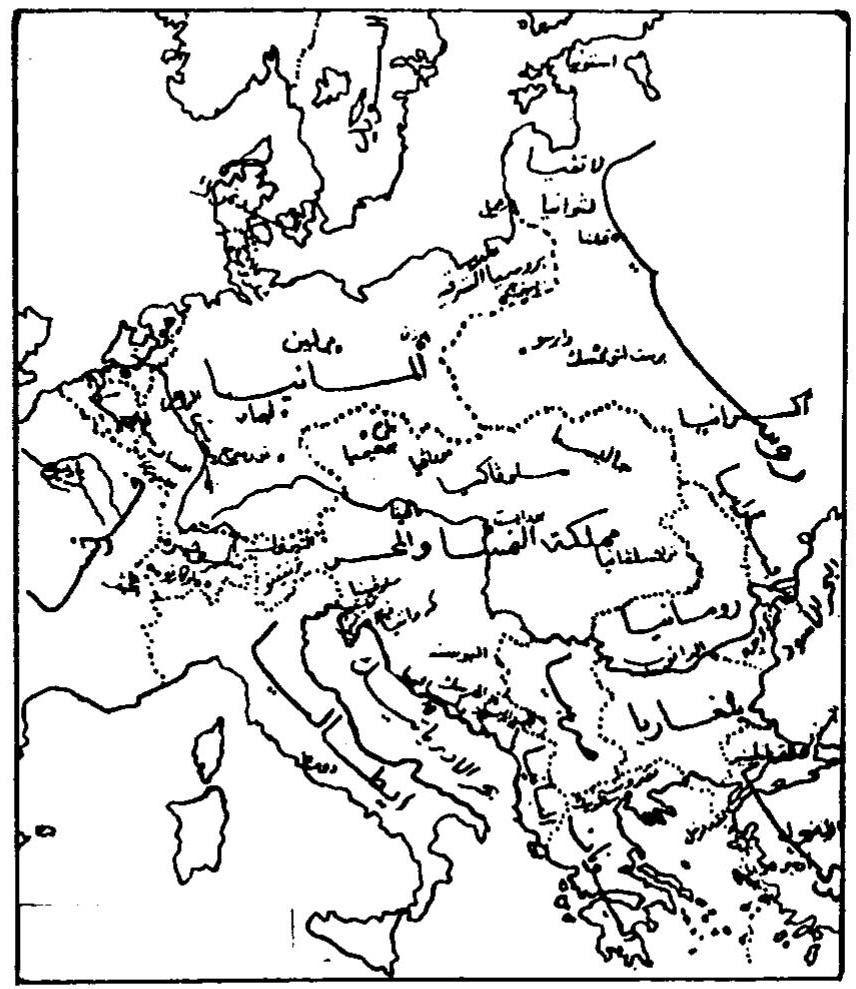

# الخريطة رقم (Y/V) 

أوروبا بعد الحرب العالمية الأولى
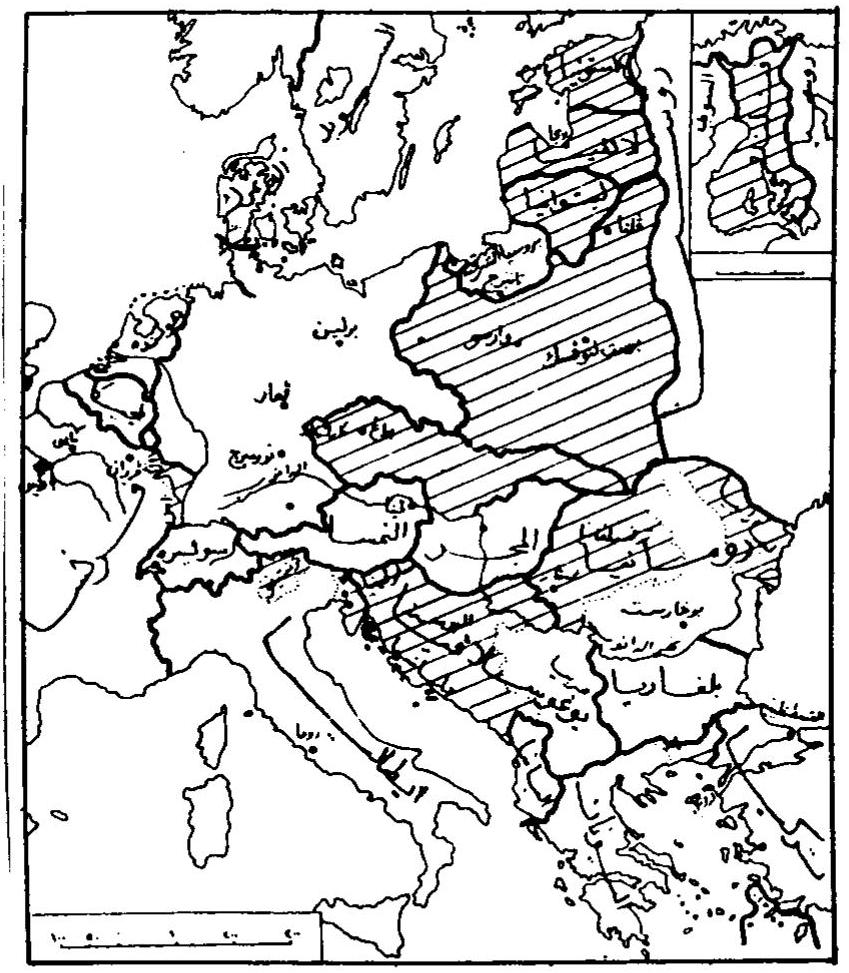

# المطلب الثانى 

## عيوب تسـويات العرب العالمية الأولى

وضعت معاهدات الصلح الموقعة بعد نهاية الحرب العالمية الأولـــى البــذور التــى أثمرت الحرب العالمية الثانية. ذلك أن الدول المنتصرة لم تتفاوض مــــع ألمانيــا، وإنمــا تدارست ما يجب أن يفرض عليها ثم طلبت منها توقيع معاهدة فرساى. كما حرصت على فرض شروط مهينة على ألمانيا فى تلك المعاهدة أهمها اعتراف ألمانيــا بجريمتــها فــى إشعال الحرب. كما أن حق تقرير المصير الذى طبقه الحلفاء على الشعوب الأوروبية لــم يطبق على الألمان، وتوزع كثير منهم بين دول متعددة. ومن ثم، فإن هتلر الـــذى تولــى السلطة فى ألمانيا سنة ١٩٣٢، اسمى معاهدة فرســـاى "إمـــلاء فرســاى" Diktat of Versailles. أكثر من ذلك فإن المعاهدة لم تنزع من ألمانيا أدوات الإنتقام لأنها أنشــــأت دولاً ضعيفة على حدود ألمانيا يسهل التغلب عليها. وهو ما حدث بالفعل. فقــد ســيطرت ألمانيا على هذه الدول فى عهد النازية. كما أن المعاهدة كفلت لألمانيا جيشاً قوامــــه ١٠٠ ألف جندى يسهل تحويلهم إلى ضباط محترفين. كذلك فإن المعاهدة لم تمس قـــوة ألمانيــا الصناعية، وذلك رغبة من المنتصرين فى تمكين ألمانيا من دفع التعويضات. وقــد مكــن ذلك ألمانيا من إستعادة قوتها فى خلال أقل من خمسة عشر عاماً، من ناحية أخرى فـــإن معاهدات الصلح لم تراع مصالح روسيا السوفييتية. فلم تحضر هذه الدولة مؤتمر الصلـح، وتجاهلت الدول المنتصرة مصالحها حتى أنها اقتطعت بعض المناطق الروسية وضمنــها إلى رومانيا (بسارابيا، وترانسلفانيا). كذلك فإن الدول المنتصرة لم تتفاوض مع النمســا أو المجــر ، أو بلغــاريا وإنما صاغت المعاهدات وطلبت من الدول المهــــزومة التوقيــع عليها .

سبق أن أشرنا إلى أن حق تقرير المصير لم يطبـــق علــى الألمــان. والواقــع أن معاهدات الصلح لم تحترم هذا المبدأ بصفة عامة، إذ أنها أسفرت عن تكويــن دول تضــم قوميات متناحرة، وفصلت قوميات عن بعضها دون مبرر، اللــــهم إلا إضعــاف ألمانيــا، ومنعها من تهديد الدول المنتصرة. فقد ضمت تشيكوسلوفاكيا ٦ مليون تشيكى، ٣ مليـــون سلوفاكى، بالإضافة إلى ٣ مليون ألمانى يعيشون فى إقليم السوديت، وحوالى ٧٠٠ ألـــف مجرى، وحوالى نصف مليون روسى. كذلك ضمت بولندا أقاليم يقطنها عنصر الروتيـــن (وهم من سكان أوكرانيا)، وأقاليم أخرى تسكنها عناصر ألمانية. كذلك ضمت رومانيا إقليم ترانسلفانيا، وتقطنه عناصر مجرية، وإقليم بسارابيا، وتقطنه عناصر سلافية روسية، كمــا

ضمت مملكة الصرب والكروات والسلوفين قوميات متعددة. كذلك، فقد ضمــــت إيطاليــــا أقاليم يقطنها ألمان، مثل منطقة جنوب التيرول، وأقاليم تسكنها عناصر سلافية. ومن ثــــم، فإن المعاهدات لم تحترم مبدأ حق الشعوب في تقرير مصيرها احتراماً كــــاملاً. وقــــد أدى ذلك إلى توترات بين الدول الأوروبية في فترة ما بين الحربين العالميتين.

فضلاً عن ذلك، فإن الدول الجديدة التي أوجدتها معاهدات التسوية كانت دولاً ضعيفة لا تتمتع بالمقدرة الإقتصادية اللازمة، مما أدى إلى أشكال عديدة مـــــن عــــدم الإســــتقرار السياسى والإجتماعى، فى الوقت الذى بدأت فيه ألمانيا تستعيد عافيتها الإقتصادية وبــــدأت تتطلع من جديد للسيطرة على تلك الدول(1).

وقد انتقد الإقتصادى الشهير كينز، معاهدة فرساى بالتحديد على أساس أنها حرمــــت ألمانيا من معظم مواردها الطبيعية وسفنها التجارية. ورغم ذلك فرضت عليها مبدأ دفــــع التعويضات دون تحديد كيفية دفع تلك التعويضات. وقد أدى ذلك إلــــى تعقيــــد العلاقــــات الألمانية الأوروبية (وبالذات الفرنسية) طوال فترة ما بين الحربين(1).

وأخيراً، فإن معاهدات التسوية لم تضع ضمانات فعالة تكفل احترام التسويات فكــــانت عصبة الأمم كما سنرى، منظمة دولية محدودة المقدرات مما أدى إلى ضعف فعالية نظــــام الأمن الجماعى العالمى.

المطلب الثالث

الدول الجـــديدة

أسفرت الحرب العالمية الأولى عن ظهور مجموعة من الدول نشأ بعضها بموجب تسويات الحرب، بينما ظهر البعض الآخر نتيجة سير العمليات الحربية ودون قرار مــــــن الدول المنتصرة، وأخيراً ظهرت أيلندا كدولة مستقلة نتيجة إتفاق مع الدولة المسيطرة.

أولا : الدول التى نشأت بموجب تسويات الحرب العالمية الأولى

1. بولنــــدا

سبق أن أشرنا إلى التقسيمات التاريخية الثلاث لبولندا في أعـــــوام ١٧٧٢، ١٧٩٣، ١٧٩٥، وإلى بعث بولندا أثناء الحروب النابوليونية باسم دوقية وارسو الكبرى ثم إلغائــــها فى مؤتمر فيينا سنة ١٨١٥ وضم معظمها إلى روسيا. وقد مثلت هزيمة ألمانيا، والنمســــا

- ٢٩٤ -

والمجر فرصة تاريخية لإعادة دولة بولندا إلى الوجود، خاصة أن البولنديين حاربوا إلــى جانب الحلفاء. فحاربوا روسيا أولاً حتى مغادرتهم بولندا سنة ١٩١٧، ثم حاربوا الألمــان بعد ذلك. وفى نوفمبر سنة ١٩١٨ أعلنــــت الجمهوريــة البولنديــة برئاســة المارشــال بيلمودسكى. وقد قرر الحلفاء إعادة دولة بولندا إلى الوجود لكى تكون حاجزاً قويــاً بيــن روسيا وألمانيا.

# ٢. مملكة الصرب والكروات والسلوفيين (يوجوسلافيا فيما بعد) 

فى سنة ١٩١٦ اجتمع قادة الحركات الوطنية فى كرواتيا، وســلوفينيا مــع زعمــاء صربيا، والجبل الأســود، وقرروا توحيد شعوبهم فى مملكة سلافية جنوبية. وقد وافقــت دول الوفــاق على هذا القرار. وتم إعلان تكوين مملكة الصرب والكــروات والســلوفين The Kingdom of the Serbs, Croates, and Slovenes مســنة ١٩١٨ وضمــت صربيا، وسلوفينيا، وكرواتيا، والبوسنة والهرسك، ومقدونيا الشمالية، وفيما بعد انضمــت إليها الجبل الأسود. ومن الواضح من الاسم الرسمى للمملكة الجديدة الحــــرص علــى أن تسمى باسم القوميات الرئيسه الثلاث مما يعكس قلق الكروات والسلوفين مــن احتمــالات الهيمنة الصربية. ولذلك، فإنه بمجرد إعلان تكوين المملكة الجديدة ثــــار الخــلاف بيــن القوميات حول شكل الدولة. فقد طالب الصرب ببناء دولة مركزية موحدة، بينمــا طــالب الآخرون ببناء دولة إتحادية. وقد انتصرت وجهة النظر الصربية. وتمثل ذلك فى صــدور الدستور الأول سنة ١٩٢١. والذى أنشأ نظاماً برلمانياً يتسم بطابع مركزى تــهيمن عليــه صربيا. وقد تذرع الصرب بأنهم هم الذين حرروا الشعوب السلافية الجنوبية ووحدوهــا، وبالتالى فهم أحق بالسلطة السياسية. وفى هذا الإطار حــاول الصــرب "صربنــة" بــاقى القوميات وأنشأوا دولة بوليسية مما أدى إلى انشقاق بين الصرب وباقى القوميات. وإيتــداء من سنة ١٩٢٨ طالبت كرواتيا بالإستقلال. وفى سنة ١٩٢٩ ألغى الملك ألكسندر الدستور، وركز كل السلطات فى يده، وأعلن تعديل اسم الدولة إلى "المملكة اليوجوسلافية" (٢).

## ٣. تشيكوسلوفاكيا

نشأت تلك الدولة نتيجة الدور الذى قام به التشيك ضد النمسا، وألمانيا أثناء الحــرب. وقد بدأ هذا الدور فى بداية الحرب بالقتال فى صفوف الجيش الروســى، ولمــا خرجــت روسيا من الحرب لم تجد القوات التشيكية سبيلاً إلا طريق سيبيريا متجهة إلــــى أوروبــا للإشتراك فى الحرب ضد النمسا، وألمانيا. وبعد الحرب أنشأت تشيكوسلوفاكيا مــن أراض مقتطعة من الإمبراطورية النمساوية المجرية بزعامة توماس مازاريك.

ثانياً : الدول التى نشأت نتيجة سبر العمليـات الحريـية
هذه الدول هى فنلندا، واستونيا، ولاتفيا، وليتوانيا. وتشترك هذه الدول فــــى صـفـــة واحدة وهى أنها كانت جزء من روسيا ثم احتلتها ألمانيا أثناء الحرب، وبعد هزيمة ألمانيــا لم تستطع روسيا أن تعيد سيطرتها عليها، مما أدى إلى إستقلالها.
1. فنلنســـدا :

عندما اندلعت الحرب العالمية الأولى كانت فنلندا جزء من الإمبراطورية الروســــية، وذلك منذ سنة ١٨٠٨ بعد أن كانت جزء من السويد. وسعت روسيا إلى "ترويس" فنلنســدا من خلال فرض اللغة الروسية. ورغم تمركز القوات الروسية فى فنلندا أثناء الحرب، فإن الأخيرة لم تنغمس فى الحرب مباشرة. وأثناء الثورة البلشفية سنة ١٩١٧، قام الفنلنديــــون بإنتخاب برلمان ما لبث أن أعلن إستقلال فنلندا واعترفت الحكومة الروسية السوفييتية بهذا الاستقلال. إلا أن فنلندا ظلت ترزح تحت شبح النفوذ الروسى حتى أن مصطلح "الفنلـــــدة" Finlandization قد تم نحته فى السياسة الدولية، وهو يشير إلى الحالة التى تخضع فيــها دولة صغيرة لشبح هيمنة دولة كبرى مجاورة، وتضطر إلى أخذ مصالح تلك الأخيرة فــى الاعتبار عند إتخاذ أى قرار سياسى.
٢. اســـتونيـــا :

حكمت السويد استونيا حتى سنة ١٧٢١ حينما تنازلت عنها لروسيا. ولكن إبان حقبــة الثورة البلشفية، أعلن الاستونيون الإستقلال فى ٢٤ فبراير سنة ١٩١٨ بتشجيع من ألمانيا. وقد أدى انسحاب القوات الألمانية إلى قيام البلاشفة بمحاولة إعادة ضم اســـــتونيا. ولكــن البلاشفة اعترفوا فى ٢ فبراير سنة ١٩٢٠ بإستقلال استونيا، وأصبحت الأخيرة عضواً فى عصبة الأمم. واستمرت استونيا تتمتع بالإستقلال حتى نشوب الحرب العالمية الثانية. وفى سنة ١٩٤٠ أعاد الاتحاد السوفييتى احتلال استونيا.
٣. لاتفـــيــــــا :

كانت لاتفيا جزء من الإمبراطورية الروسية منذ القرن الثامن عشر. وحينما قـــامت الثورة البلشفية أعلنت لاتفيا إستقلالها. ولكن القوات البلشفية حاولت إعادة ضم لاتفيا التــى

قاومت بدورها بدعم من الجيش الألمانى. وبعد هزيمة ألمانيا وقمـــت لاتفيــا، وروســيا السوفييتية معاهدة احترمت بموجبها الأخيرة إستقلال لاتفيا.

# ٤. ليتوانىـــا : 

على غرار ما حدث فى دول بحر البلطيق كانت ليتوانيا جزء مــــن الإمبراطوريــة الروسية منذ منتصف القرن السابع عشر، بإستثناء الجزء الجنوبى الغربى الذى انضم إلــى روسيا سنة ١٨١٥. وطوال القرن التاسع عشر قاوم الليتوانيون الحكم الروسى، وفرضــت روسيا لغتها على ليتوانيا. وخلال الحرب العالمية الأولى احتلت ألمانيا ليتوانيا. ولكن فــى فبراير سنة ١٩١٨ أعلن القوميون الليتوانيون الإستقلال. وبعد هزيمة ألمانيــا وانســحاب قواتها تم تكوين حكومة وطنية مؤقتة. وحينما حاول البلاشفة إعادة ضم ليتوانيا واجــــهوا مقاومة عنيفة أجبرتهم على الإنسحاب. ولكن فى سنة ١٩٢٠ احتلت بولندا مدينة فيلنيوس، عاصمة ليتوانيا، وضمتها إلى أراضيها. وفى سنة ١٩٢٢ ثم إعلان جمهوريــــة ليتوانيــا المستقلة. وبموجب معاهدة فرساى حصلت ليتوانيا علــــى منطقــة ميمــل Memel (ذات الأغلبية الليتوانية)، وكانت جزء من ألمانيا قبل الحرب. وفى سنة ١٩٢٣ قــامت ليتوانيــا بضمها نهائياً لتحصل على منفذ على البحر.

## ثالثًا : استـثـلال ايـسـلندا

كانت ايسلندا تابعة للتاج الدانمركى. ولكن حركة الاستقلال عن الدانمرك تصـــاعدت مع أوائل القرن العشرين وقامت الدانمرك بمنح ايسلندا الاستقلال الداخلــى ســنة ١٩٠٤. ولكن فى سنة ١٩١٨ قررت الدانمرك الاعتراف باستقلال مملكة ايسلندا فى إطار "معاهدة الاتحاد" التى أنشأت اتحادا شخصيا بين الدانمرك وايسلندا تحت حكــم الملــك كريســتيان العاشر. وعندما نشبت الحرب العالمية الثانية احتلت ألمانيا الدانمرك بينما احتلت بريطانيــا ايسلندا سنة ١٩٤٠. وفى سنة ١٩٤٤ ألغت ايسلندا معاهدة الاتحاد مع الدانمرك.

# المبحث السادس 

## التحول نحو المؤسسية العالمية : إنشـاء عصبة الأمم

أسفر مؤتمر فرساى عن تحول جذرى فى المؤسسية الدولية، تمثل فـــى إنشـــاء أول تنظيم دولى عالمى، وهو عصبة الأمم League of Nations. وقد كان إنشاء العصبـــــة نتيجة تفاعل أربعة تيارات. أول هذه التيارات هو خبرة المؤسسية الدولية التــى تراكمــت على مدى القرن التاسع عشر. فقد أثمرت هذه الخبرة تراثاً فكرياً وتنظيمياً فى كيفية إنشــاء وتحديد اختصاصات المؤسسات الدولية استعادت منه عصبة الأمم. ولكن العصبة دفعــــت هذه الخبرة للأمام عن طريق إنشاء آليات جديدة لم تكن معروفة من قبل. ولذلــــك يقــول كلود، كان تكوين عصبة الأمم جزئياً عملية تقليد للأشكال والأنماط التنظيمية التى ســبقتها فى القرن التاسع عشر. ولكنه لم يكن تقليداً حرفياً بقدر ما كان تكملة وتطويراً لها واقتباساً تقدمياً للنماذج الأولية الأصلية للتنظيم الدولى." (1). وثانيها، خبرة التعاون الدولــــى بيــن الدول المنتصرة فى الحرب العالمية الأولى. فقد أنشأت تلك الدول العديــد مــن الــهيئات المشتركة (مجلس الحرب الأعلى، ومجلس الحصار البحرى، وغيرها) أظهرت لتلك الدول إمكانية التعاون الدولى، كما ساعدت على إيجاد مجموعة من الموظفين الدوليين المتمرسين بالعمل الدولى، وهم الذين استفادت منهم العصبة فيما بعد. ولعبت دورا مهما فــى عمليــة التكامل الأوروبى بعد الحرب العالمية الثانية كما سنرى فى الفصل الرابع عشــر. ومــن أشهر هؤلاء كان جان مونيه Jean Monnet الفرنسى الذى خدم الجهاز الحربى للحلفــاء وتحول إلى العمل فى العصبة فيما بعد. وثالثها نشوء إدراك دولى عام لضــرورة وجــود جهاز عالمى يكفل منع نشوب حرب عالمية أخرى. ولذلك فقد كان هناك حوالــى ثلاثيــن مشروعاً مقدمة إلى مؤتمر فرساى من هيئات خاصة وحكومية حول إنشاء هذا الجــــهاز. أما الرابع فهو الدور الذى قام به الرئيس الأمريكى ويلسون لدعم فكرة إنشاء تنظيم دولــى عالمى انطلاقاً من المبادئ الأربعة عشر التى سبق أن أعلنها كإطار لتنظيم السياسة الدولية بعد الحرب. $\square$

ولعل أهم المشروعات التى قدمت إلى مؤتمر فرساى هى المشــروعات الفرنســية، والبريطانية، والأمريكية. وقد تركز المشروع الفرنسى على إنشـــاء منظمـــة دوليـــة ذات

اختصاصات ملزمة واسعة. فقد اقترح المشروع الفرنسى أن يكون للتنظيم المقــترح قــوة عسكرية دولية دائمة يمكنها استخدام القوة عند الضرورة ضد الدول التى تنتهك أحكامــها، مع الأخذ بمبدأ التحكيم الإجبارى. أما المشروع البريطانى فقد أتى على إنشـــاء مؤسســة دولية ذات اختصاصات محدودة. فقد ركز على قدسية سيادة الدول الأعضاء وعدم فــرض جزاءات على الدول فى حالة عدم تنفيذ القرارات، وعلى مبدأ التحكيم الإختيارى.

أما المشروع الأمريكى فكان مشروعاً وسطاً بين التصورين الفرنسى والبريطانى، إذ أنه كان يأخذ بمبدأ التحكيم الإجبارى ويخول التنظيم المقترح اختصاصات واسعة فى مجال خفض التسلح ولكنه يحترم سيادة الدول. ولكن لجنة "هيرست-ميللر"، المكلفــــة بصياغــة مشروع التنظيم المقترح، أخذت بوجهة النظر البريطانية، وقامت بصياغة "عهد" عصبــــة الأمم. وتم إقراره فى مؤتمر فرساى فى ٢٨ أبريل سنة ١٩١٩ وأصبح العهد جــزء مـــن معاهدة فرساى فى ٢٨ أبريل سنة ١٩١٩، ودخل حيز التنفيذ فى ١٠ يناير ســـنة ١٩٢٠. وأصبحت مدينة جنيف مقراً دائماً للعصبة. وهكذا تم إنشاء أول تنظيم دولى عالمى. ولو من الناحية الثــــكلية القانونبــة، كمــا سنرى. وهنا تأتى المعضلة الأولى التى واجهتها عصبة الأمم، وهى أن العصبة بدا كما لو أنها جزء من سعى الدول المنتصرة لتكريس انتصارها وإضفاء الشرعية على التسوية التى أتت عليها معاهدة فرساى. فلم تكن وظيفة العصبة هى "المحافظة على السلام بقـــدر مــا كانت المحافظة على "سلام معين"، وأن تخلع الشرعية وتمنح الإستقرار لتســــوية دوليــة معينة أساسها الانتصار."(٢)

وقد نصت ديباجة العهد على أهداف العصبة ومبادئها. فقد تحدد هدف العصبة بأنــــه "تنمية التعاون بين الأمم وضمان سلامها وأمنها." وأضافت الديباجة أربعة مبادئ للعصبــة هى أن تقبل الدول الالتزام بعدم اللجوء إلى الحرب، وأن تقوم العلاقات بين الدول بشــكل علنى وعلى أساس العدالة والشرف، وأن تلتزم الدول باحترام قواعد القانون الدولى العــام، وأن تحترم الإلتزامات التى تتقرر فى المعاهدات التى تبرمها. وتمارس العصبة أعمالــــها عن طريق "جمعية"، و"مجلس" يعاونهما أمانة دائمة. وتتألف الجمعية من ممثلىــى الــدول الأعضاء، وتختص بالنظر فى كل المسائل التى تدخل فى اختصاص العصبة، أو يكون من شأنها التأثير على السلام العالمى، بينما يتألف المجلس من ممثلى الدول العظمى المتحالفــة وأنصارها (وهم بريطانيا، وفرنسا، وإيطاليا، واليابان، وانضمت إليهم ألمانيا فيمــا بعــد)، ومن ممثلى أربع دول أخرى من أعضاء العصبة يتم اختيارهم عــــن طريــق الجمعيــة.

ونصت المادة الخامسة على صدور قرارات الجمعية والمجلس بإجماع الأصوات الممثلـــة فى الإجتماع فى المسائل الموضوعية. كذلك يعين الأمين العام بواسطة المجلس بعد موافقة أغلبية الجمعية. كذلك نص العهد على تكليف المجلس بوضع مشروع محكمة عدل دوليـــة دائم،ة تختص بفحص المنازعات الدوليـــة التــى يعرضــها أطــراف الــنزاع (التحكيــم الاختيارى).

وسنعرض فى الفصول التالية للخبرة التطبيقية للعصبة فى فترة ما بيــــن الحربيـــن. ولكن يمكن أن نبدى الملاحظات التاليةعلى تكوين العصبة. لعل أهم تلك الملاحظات هــــو أن عهد عصبة الأمم قد تم إدماجه فى إتفاقية فرساى، كما تم إستبعاد الدول المهزومة مــن عضوية العصبة. وبذلك فقد نظرت الدول إلى العصبة باعتبارها مؤسســـــة تــهدف إلــى تكريس نتائج الحرب العالمية الأولى أكثر منها مؤسسة تهدف إلى إقرار السلام العــــالمى. فلم تقبل ألمانيا فى العصبة إلا سنة ١٩٢٦، وانسحبت منها سنة ١٩٣٢، ولم ينضم الاتحــاد السوفييتى إلا سنة ١٩٣٤، وتم فصله من العصبة سنة ١٩٣٩. كما أن الولايات المتحدة لم تدخل عضوية العصبة بسبب رفض مجلس الشيوخ الأمريكــى التصديــق علــى إتفاقيــة فرساى. كما انسحبت اليابان منها سنة ١٩٣٢، وإيطاليا سنة ١٩٣٧. كما ظل إسهام الدول الآسيوية والأفريقية الجديدة فى أعمال العصبة محدوداً. وبذلك تحولت العصبة إلى منظمــة أوروبية فى الأغلب. من ناحية أخرى، فإن إتخاذ القرارات فى الجمعية والعصبــــة طبقــاً لقاعدة الإجماع أضعف من قدرتها على إتخاذ القرارت. هــــذا بالإضافــة إلــى تســاوى اختصاصات المجلس والجمعية مما أدى إلى تنافسهما بل وإلى صدور قرارات متعارضة. من ناحية ثالثة، فقد كانت سلطات العصبة محدودة لعدة أسباب أهمــــها قــاعدة الإجمــاع، بالإضافة إلى أن عهد العصبة لم يحرم الحرب. فقد قررت المادة الخامسة عشر من عــــهد العصبة عدة إجراءات لتسوية المنازعات بالطرق السلمية. ولكن العهد نص على أنــــه إذا فشلت تلك الإجراءات جاز للدول اللجوء إلى الحرب فى حالات ثلاث هى عدم تنفيذ حكــم قضائى أو تحكيمى، أو قرار جماعى من المجلس ضد دولة، وفى حالة عدم انعقاد إجمــاع المجلس على إصدار قرار فى النزاع بعد مرور ثلاثة شهور على عرض الــــنزاع أمــام المجلس. من ناحية أخرى، فقد اشترط العهد لتطبيق الجزاءات ضد الدول المعتدية (المــادة ١٦) وقوع العدوان بالفعل. وترك أمر تفسير معنى العدوان لتقدير كل دولة، وهو ما يعنى عدم إلتزام الدول بتطبيق الجزاءات إلا إذا قررت بذاتها اعتبار إحدى الدول معتدية، ممــــا كان يعنى اختيارية تطبيق الجزاءات العسكرية .

# خـلاصة 

غيرت الحرب العالمية الأولى كل عناصر النسق الدولى. فقد سقطت الإمبراطوريات النمساوية المجرية، والعثمانية، والروسية، وظهرت دول جديدة. وتغيرت البنيـــة الثنائيــة للنظام الدولى بهزيمة دول الحلف الثلاثى. ولفترة قصيرة أصبح البنيان الدولى بنيانا أحادياً تسيطر عليه الدول المنتصرة حتى بدأ الصراع بينها. كذلك سقطت النظم الإمبراطوريـــــة الدكتاتورية، آل هابسبورج فى النمسا، آل هوهنزلرن فى ألمانيا، آل رومانوف فى روسيا، وآل عثمان فى الدولة العثمانية. كذلك صعدت القوميات بتقسيم الإمبراطوريات على أساس قومى فى الغالب. ونشأت دول جديدة فى السياسة الدولية، أثرت فى مجريات تلك السياسـة طوال الحقبة التالية. بيد أن تسويات الحرب العالمية الأولى انطوت على عيوب جوهريـــة أدت إلى وضع أسس نشوب الحرب العالمية الثانية سنة 1979. وأخيرا، فقد شهدت تلــك الحقبة إنثاء أول تنظيم دولى عالمى وهو عصبة الأمم .

In [86]:
from mistralai.models import OCRResponse
from IPython.display import Markdown, display

def replace_images_in_markdown(markdown_str: str, images_dict: dict) -> str:
    """
    Replace image placeholders in markdown with base64-encoded images.

    Args:
        markdown_str: Markdown text containing image placeholders
        images_dict: Dictionary mapping image IDs to base64 strings

    Returns:
        Markdown text with images replaced by base64 data
    """
    for img_name, base64_str in images_dict.items():
        markdown_str = markdown_str.replace(
            f"![{img_name}]({img_name})", f"![{img_name}]({base64_str})"
        )
    return markdown_str

def get_combined_markdown(ocr_response: OCRResponse) -> str:
    """
    Combine OCR text and images into a single markdown document.

    Args:
        ocr_response: Response from OCR processing containing text and images

    Returns:
        Combined markdown string with embedded images
    """
    markdowns: list[str] = []
    # Extract images from page
    for page in ocr_response.pages:
        image_data = {}
        for img in page.images:
            image_data[img.id] = img.image_base64
        # Replace image placeholders with actual images
        markdowns.append(replace_images_in_markdown(page.markdown, image_data))

    return "\n\n".join(markdowns)

# Display combined markdowns and images
display(Markdown(get_combined_markdown(pdf_response)))

## Mistral OCR with Image

In addition to the PDF file shown above, Mistral OCR can also process image files:

In [84]:
'''
import base64

# Verify image exists
image_file = Path("receipt.png")
assert image_file.is_file()

# Encode image as base64 for API
encoded = base64.b64encode(image_file.read_bytes()).decode()
base64_data_url = f"data:image/jpeg;base64,{encoded}"

# Process image with OCR
image_response = client.ocr.process(
    document=ImageURLChunk(image_url=base64_data_url),
    model="mistral-ocr-latest"
)

# Convert response to JSON
response_dict = json.loads(image_response.model_dump_json())
json_string = json.dumps(response_dict, indent=4)
print(json_string)
'''

SyntaxError: incomplete input (ipython-input-3008271418.py, line 1)

## Extract structured data from OCR results

OCR results can be further processed using another model.

Our goal is to extract structured data from these results. To achieve this, we will utilize the `pixtral-12b-latest` model, supported by our OCR model, to deliver better and higher-quality answers:

In [80]:
# Get OCR results for processing
'''image_ocr_markdown = image_response.pages[0].markdown

# Get structured response from model
chat_response = client.chat.complete(
    model="pixtral-12b-latest",
    messages=[
        {
            "role": "user",
            "content": [
                ImageURLChunk(image_url=base64_data_url),
                TextChunk(
                    text=(
                        f"This is image's OCR in markdown:\n\n{image_ocr_markdown}\n.\n"
                        "Convert this into a sensible structured json response. "
                        "The output should be strictly be json with no extra commentary"
                    )
                ),
            ],
        }
    ],
    response_format={"type": "json_object"},
    temperature=0,
)

# Parse and return JSON response
response_dict = json.loads(chat_response.choices[0].message.content)
print(json.dumps(response_dict, indent=4))'''

{
    "parking_receipt": {
        "city": "Palo Alto",
        "expiration_time": "11:59 PM",
        "expiration_date": "AUG 19, 2024",
        "purchase_time": "01:34 PM",
        "purchase_date": "Aug 19, 2024",
        "total_due": "$15.00",
        "total_paid": "$15.00",
        "ticket_number": "00005883",
        "serial_number": "520117260957",
        "setting": "Permit Machines",
        "machine_name": "Civic Center",
        "payment_method": "Visa",
        "note": "DISPLAY FACE UP ON DASH",
        "expiry_message": "PERMIT EXPIRES AT MIDNIGHT"
    }
}


In the example above, we are leveraging a model already capable of vision tasks.

However, we could also use text-only models for the structured output. Note in this case, we do not include the image in the user message:

In [81]:
# Get OCR results for processing
'''image_ocr_markdown = image_response.pages[0].markdown

# Get structured response from model
chat_response = client.chat.complete(
    model="ministral-8b-latest",
    messages=[
        {
            "role": "user",
            "content": [
                TextChunk(
                    text=(
                        f"This is image's OCR in markdown:\n\n{image_ocr_markdown}\n.\n"
                        "Convert this into a sensible structured json response. "
                        "The output should be strictly be json with no extra commentary"
                    )
                ),
            ],
        }
    ],
    response_format={"type": "json_object"},
    temperature=0,
)

# Parse and return JSON response
response_dict = json.loads(chat_response.choices[0].message.content)
print(json.dumps(response_dict, indent=4))'''


{
    "ticket_info": {
        "ticket_number": "00005883",
        "serial_number": "520117260957",
        "setting": "Permit Machines",
        "machine_name": "Civic Center"
    },
    "expiration": {
        "date": "2024-08-19",
        "time": "11:59 PM"
    },
    "purchase": {
        "date": "2024-08-19",
        "time": "01:34 PM"
    },
    "amounts": {
        "total_due": 15.0,
        "total_paid": 15.0
    },
    "payment_method": "Visa"
}


## All Together - Mistral OCR + Custom Structured Output
Let's design a simple function that takes an `image_path` file and returns a JSON structured output in a specific format. In this case, we arbitrarily decided we wanted an output respecting the following:

```python
class StructuredOCR:
    file_name: str  # can be any string
    topics: list[str]  # must be a list of strings
    languages: str  # string
    ocr_contents: dict  # any dictionary, can be freely defined by the model
```

We will make use of [custom structured outputs](https://docs.mistral.ai/capabilities/structured-output/custom_structured_output/).

In [82]:
'''from enum import Enum
from pathlib import Path
from pydantic import BaseModel
import base64


class StructuredOCR(BaseModel):
    file_name: str
    topics: list[str]
    languages: str
    ocr_contents: dict

def structured_ocr(image_path: str) -> StructuredOCR:
    """
    Process an image using OCR and extract structured data.

    Args:
        image_path: Path to the image file to process

    Returns:
        StructuredOCR object containing the extracted data

    Raises:
        AssertionError: If the image file does not exist
    """
    # Validate input file
    image_file = Path(image_path)
    assert image_file.is_file(), "The provided image path does not exist."

    # Read and encode the image file
    encoded_image = base64.b64encode(image_file.read_bytes()).decode()
    base64_data_url = f"data:image/jpeg;base64,{encoded_image}"

    # Process the image using OCR
    image_response = client.ocr.process(
        document=ImageURLChunk(image_url=base64_data_url),
        model="mistral-ocr-latest"
    )
    image_ocr_markdown = image_response.pages[0].markdown

    # Parse the OCR result into a structured JSON response
    chat_response = client.chat.parse(
        model="pixtral-12b-latest",
        messages=[
            {
                "role": "user",
                "content": [
                    ImageURLChunk(image_url=base64_data_url),
                    TextChunk(text=(
                        f"This is the image's OCR in markdown:\n{image_ocr_markdown}\n.\n"
                        "Convert this into a structured JSON response "
                        "with the OCR contents in a sensible dictionnary."
                        )
                    )
                ]
            }
        ],
        response_format=StructuredOCR,
        temperature=0
    )

    return chat_response.choices[0].message.parsed

We can now extract structured output from any image parsed with our OCR model.

In [83]:
# Example usage
'''image_path = "receipt.png" # Path to sample receipt image
structured_response = structured_ocr(image_path) # Process image and extract data

# Parse and return JSON response
response_dict = json.loads(structured_response.model_dump_json())
print(json.dumps(response_dict, indent=4))'''

JSONDecodeError: Expecting property name enclosed in double quotes: line 63 column 10 (char 716)

The original image for comparison can be found below.

In [ ]:
'''from PIL import Image

image = Image.open(image_path)
image.resize((image.width // 5, image.height // 5))
'''